In [1]:
import pandas as pd
import numpy as np
from data_loader import DataLoader
from feature_generator import FeatureGenerator
from label_generator import LabelGenerator
from regression_model_trainer import RegressionModelTrainer
from classifier_model_trainer import ClassifierModelTrainer
from data_processor import DataProcessor


In [2]:
# ✅ Load CSV
loader = DataLoader()
training_df_raw = loader.load_from_csv("data/training/mes_2_new_30000.csv")  # change filename accordingly

# ✅ Drop any duplicate timestamps
training_df_raw = training_df_raw.drop_duplicates(subset=["Date", "Time"])

training_df_raw.head()


Data successfully loaded from data/training/mes_2_new_30000.csv


,Open,High,Low,Close,Volume,Date,Time
0,5771.00,5771.00,5769.00,5769.50,0,08/19/2024,4:05
1,5769.50,5770.50,5768.25,5769.50,0,08/19/2024,4:10
2,5769.75,5771.50,5769.75,5770.75,0,08/19/2024,4:15
3,5770.75,5770.75,5768.50,5769.75,0,08/19/2024,4:20
4,5770.00,5771.00,5768.75,5769.75,0,08/19/2024,4:25


In [3]:
feature_generator = FeatureGenerator()
training_df_features = feature_generator.create_all_features(training_df_raw)

training_df_features.head()


✅ FeatureGenerator initialized!
🚀 Starting full feature generation pipeline...
✅ Successfully calculated all technical indicators with correct column names!
✅ VWAP added successfully!
✅ Fibonacci levels added successfully! (Length=50, Retrace=0.382)
🔹 Computing CCI with length=14...
✅ Successfully computed CCI and CCI_Avg (CCI: 14, CCI_Avg: 9)
✅ Ichimoku Cloud indicators added successfully!
✅ Successfully computed ATR and added ATR-adjusted price features!
✅ Added EMAs (5-50) and their Distances (Close/Open) Successfully!
✅ Successfully added High-Based Indicators (Unified Method)!
✅ Added constant columns: ['OverBot', 'OverSld', 'OverBought', 'OverSold', 'Zero Cross', 'CROSS FIB.1', 'CROSS FIB.2']
✅ Successfully added MACD indicators!
✅ Successfully added volatility, Williams %R, and Relative Volume features!
✅ Feature generation complete! Final DataFrame: 117 columns


,Open,High,Low,Close,Volume,Date,Time,FastAvg,SlowAvg,FastEMA,...,OverBought,OverSold,Zero Cross,CROSS FIB.1,CROSS FIB.2,MACD,MACDAvg,MACDDiff,Williams_R,Relative_Volume
0,5771.00,5771.00,5769.00,5769.50,0,08/19/2024,4:05,NaN,NaN,5769.50,...,70,30,0,0,0,0.000000,0.000000,0.000000,NaN,NaN
1,5769.50,5770.50,5768.25,5769.50,0,08/19/2024,4:10,NaN,NaN,5769.50,...,70,30,0,0,0,0.000000,0.000000,0.000000,NaN,NaN
2,5769.75,5771.50,5769.75,5770.75,0,08/19/2024,4:15,NaN,NaN,5769.75,...,70,30,0,0,0,0.099715,0.019943,0.079772,NaN,NaN
3,5770.75,5770.75,5768.50,5769.75,0,08/19/2024,4:20,NaN,NaN,5769.75,...,70,30,0,0,0,0.096931,0.035341,0.061590,NaN,NaN
4,5770.00,5771.00,5768.75,5769.75,0,08/19/2024,4:25,NaN,NaN,5769.75,...,70,30,0,0,0,0.093645,0.047002,0.046644,NaN,NaN


In [4]:
label_generator = LabelGenerator()
training_df_labeled = label_generator.elasticnet_label_next_high(training_df_features)


✅ Elastic Net label 'Next_High' added.


In [5]:
trainer = RegressionModelTrainer(
    include_prices=False,         # Set to True if you want price columns
    apply_filter=True,            # Filter based on error threshold
    filter_threshold=4.0          # Can adjust this value
)

trainer.prepare_data(training_df_features)
trainer.train_model()
trainer.make_predictions()



✅ Sample Data Alignment Check:
   Sample Target (y_test)  Corresponding Feature Row
0                 6199.25                      24000
1                 6199.50                      24001
2                 6198.75                      24002
3                 6198.50                      24003
4                 6198.50                      24004


In [6]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(trainer.y_test, trainer.predictions)
r2 = r2_score(trainer.y_test, trainer.predictions)

print("📊 Regression Metrics (Unfiltered):")
print(f"MSE: {mse:.3f}")
print(f"R²: {r2:.3f}")
print(f"Test Samples: {len(trainer.y_test)}")
print(f"Features Used: {trainer.x_train.shape[1]}")


📊 Regression Metrics (Unfiltered):
MSE: 4.641
R²: 0.999
Test Samples: 6000
Features Used: 111


In [7]:
# Make a full copy before modifying to avoid SettingWithCopyWarning
training_df_labeled = training_df_labeled.copy()

# Safely create and set Timestamp index
training_df_labeled["Timestamp"] = pd.to_datetime(training_df_labeled["Date"] + " " + training_df_labeled["Time"])
training_df_labeled = training_df_labeled.set_index("Timestamp").sort_index()


In [8]:
# ✅ Step 1: Reset index to allow access by integer
training_df_labeled = training_df_labeled.reset_index(drop=True)

# ✅ Step 2: Clip x_test indices to max valid row index (prevent KeyError)
max_valid_index = len(training_df_labeled) - 1
safe_indices = trainer.x_test.index[trainer.x_test.index <= max_valid_index]

# ✅ Optional: Warn if any were dropped
if len(safe_indices) < len(trainer.x_test.index):
    print(f"⚠️ {len(trainer.x_test.index) - len(safe_indices)} test rows dropped due to index overflow.")

# ✅ Step 3: Build x_test_with_meta with safe indices only
x_test_with_meta = trainer.x_test.loc[safe_indices].copy()

# Add Date and Time using safe indices
x_test_with_meta["Date"] = training_df_labeled.loc[safe_indices, "Date"].values
x_test_with_meta["Time"] = training_df_labeled.loc[safe_indices, "Time"].values

# Create Timestamp index
x_test_with_meta["Timestamp"] = pd.to_datetime(x_test_with_meta["Date"] + " " + x_test_with_meta["Time"])
x_test_with_meta = x_test_with_meta.set_index("Timestamp").sort_index()

# ✅ Step 4: Rebuild training_df_labeled with Timestamp index (only once!)
training_df_labeled["Timestamp"] = pd.to_datetime(training_df_labeled["Date"] + " " + training_df_labeled["Time"])
training_df_labeled = training_df_labeled.set_index("Timestamp").sort_index()

# ✅ Step 5: Join OHLC columns
trainer.x_test_with_meta = x_test_with_meta.join(
    training_df_labeled[["Open", "High", "Low", "Close"]],
    how="left"
)

# ✅ Step 6: Add predictions and shifted columns
trainer.x_test_with_meta["Predicted_High"] = trainer.predictions[:len(trainer.x_test_with_meta)]
trainer.x_test_with_meta["Prev_Close"] = trainer.x_test_with_meta["Close"].shift(1)
trainer.x_test_with_meta["Prev_Predicted_High"] = trainer.x_test_with_meta["Predicted_High"].shift(1)

# ✅ Step 7: Clean result
df_with_meta = trainer.x_test_with_meta.dropna(subset=["Prev_Close", "Prev_Predicted_High"])

print("✅ Metadata attached and df_with_meta ready. Shape:", df_with_meta.shape)


⚠️ 1 test rows dropped due to index overflow.
✅ Metadata attached and df_with_meta ready. Shape: (5998, 119)


In [9]:
# Step 1: Attach predictions directly to df
df_for_labeling = trainer.x_test_with_meta.copy()
df_for_labeling["Predicted_High"] = trainer.predictions[:len(df_for_labeling)]

# Step 2: Shift predictions and closes for labeling logic
df_for_labeling["Prev_Predicted_High"] = df_for_labeling["Predicted_High"].shift(1)
df_for_labeling["Prev_Close"] = df_for_labeling["Close"].shift(1)

# Step 3: Drop NaNs due to shifting
df_for_labeling = df_for_labeling.dropna(subset=["Prev_Close", "Prev_Predicted_High"])

# Step 4: Correct labeling
df_labeled_old = label_generator.add_good_bar_label(df_for_labeling)
df_labeled_all = label_generator.long_good_bar_label_all(df_for_labeling)
df_labeled_bullish = label_generator.long_good_bar_label_bullish_only(df_for_labeling)


✅ Successfully assigned labels without -1!
✅ All-bar long label applied (1 = bullish + actual ≥ predicted).
✅ Bullish-only label applied (1 = actual ≥ predicted).


In [10]:

from imblearn.over_sampling import SMOTE

processor = DataProcessor()

# 🔵 old version
X_train_old, y_train_old, X_test_old, y_test_old = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_old,
    target_column="good_bar_prediction_outside_of_boundary",
    drop_target=True,
    split_ratio=0.8
)
smote_old = SMOTE(random_state=42)

classifier_X_train_bal_old, classifier_y_train_bal_old = smote_old.fit_resample(X_train_old, y_train_old)
classifier_trainer_old = ClassifierModelTrainer()
classifier_trainer_old.train_all_classifiers(classifier_X_train_bal_old, classifier_y_train_bal_old, X_test_old, y_test_old, trainer)


smote_all = SMOTE(random_state=42)

# 🔵 All-bar version
X_train_all, y_train_all, X_test_all, y_test_all = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_all,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

classifier_X_train_bal_all, classifier_y_train_bal_all = smote_all.fit_resample(X_train_all, y_train_all)
classifier_trainer_all = ClassifierModelTrainer()
classifier_trainer_all.train_all_classifiers(classifier_X_train_bal_all, classifier_y_train_bal_all, X_test_all, y_test_all, trainer)


smote_bullish = SMOTE(random_state=42)

# 🟣 Bullish-only version
X_train_bullish, y_train_bullish, X_test_bullish, y_test_bullish = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_bullish,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)
classifier_X_train_bal_bullish, classifier_y_train_bal_bullish = smote_bullish.fit_resample(X_train_bullish, y_train_bullish)
classifier_trainer_bullish = ClassifierModelTrainer()
classifier_trainer_bullish.train_all_classifiers(classifier_X_train_bal_bullish, classifier_y_train_bal_bullish, X_test_bullish, y_test_bullish, trainer)



✅ Sample Data Alignment Check:
   Sample Target (y_test) Corresponding Feature Row
0                       1       2025-01-15 12:00:00
1                       0       2025-01-15 12:05:00
2                       0       2025-01-15 12:10:00
3                       1       2025-01-15 12:15:00
4                       0       2025-01-15 12:20:00
✅ ClassifierModelTrainer initialized!

🚀 Training all classifiers...

🚀 Training RandomForest...

📊 RandomForest Evaluation:
              precision    recall  f1-score   support

           0       0.92      0.87      0.90       721
           1       0.82      0.89      0.86       479

    accuracy                           0.88      1200
   macro avg       0.87      0.88      0.88      1200
weighted avg       0.88      0.88      0.88      1200


🎯 RandomForest Accuracy: 0.8792

🚀 Training LightGBM...

📊 LightGBM Evaluation:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       721
           1  


# Classifier Analysis

Total Bars: 5982
Total 'Good' Labeled Bars (Potential Trades): 2428 (40.59%)

📅 Potential trades per day statistics:
count     24.000000
mean     101.166667
std       29.116956
min        1.000000
25%       96.000000
50%      110.500000
75%      119.000000
max      124.000000
dtype: float64


C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\3236097199.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_bars['Date'] = pd.to_datetime(good_bars['Date'])
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


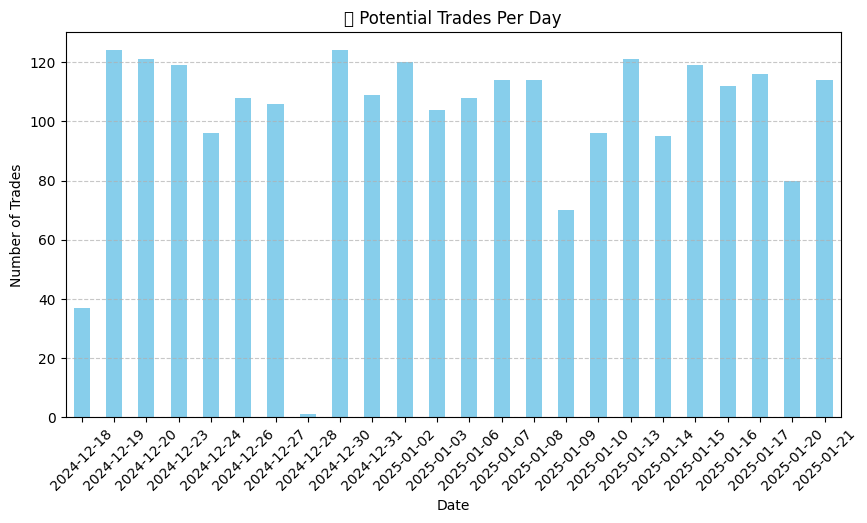

C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\3236097199.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  good_bars['Hour'] = pd.to_datetime(good_bars['Time']).dt.hour
C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\3236097199.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_bars['Hour'] = pd.to_datetime(good_bars['Time']).dt.hour
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)



⏰ Trades distribution by hour:
Hour
0       3
1      90
2     101
3     111
4     105
5     103
6      93
7      95
8     104
9     104
10    115
11    104
12    114
13    110
14    113
15    110
16    111
17    119
18    107
19    120
20    113
21    109
22    112
23     62
dtype: int64


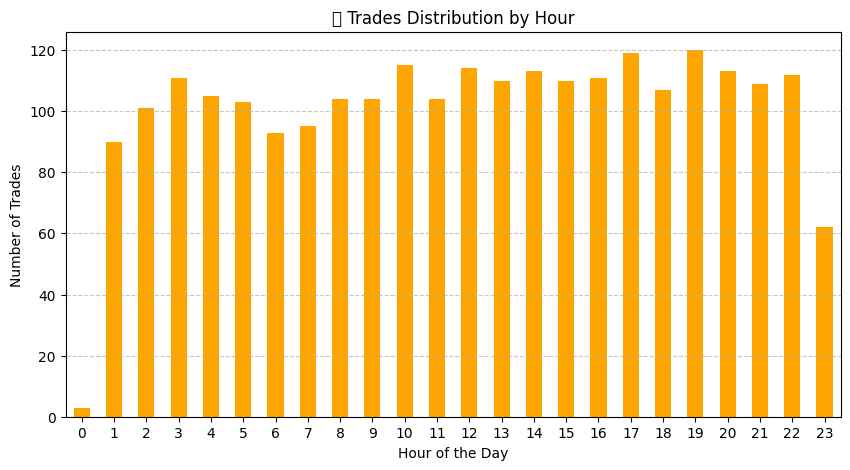

In [11]:
import matplotlib.pyplot as plt

# Check distribution of labels in the bullish-only labeled dataset
good_bars = df_labeled_bullish[df_labeled_bullish["long_good_bar_label"] == 1]

total_bars = len(df_labeled_bullish)
total_good_bars = len(good_bars)
percentage_good = (total_good_bars / total_bars) * 100

print(f"Total Bars: {total_bars}")
print(f"Total 'Good' Labeled Bars (Potential Trades): {total_good_bars} ({percentage_good:.2f}%)\n")

# Count potential trades per day
good_bars['Date'] = pd.to_datetime(good_bars['Date'])
trades_per_day = good_bars.groupby(good_bars['Date'].dt.date).size()

print("📅 Potential trades per day statistics:")
print(trades_per_day.describe())

# Simple visualization of potential trades per day
plt.figure(figsize=(10, 5))
trades_per_day.plot(kind='bar', color='skyblue')
plt.title('📅 Potential Trades Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Trades')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

# Check timing distribution (hours)
good_bars['Hour'] = pd.to_datetime(good_bars['Time']).dt.hour
trades_by_hour = good_bars.groupby('Hour').size()

print("\n⏰ Trades distribution by hour:")
print(trades_by_hour)

# Visualization of trades by hour
plt.figure(figsize=(10, 5))
trades_by_hour.plot(kind='bar', color='orange')
plt.title('⏰ Trades Distribution by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trades')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.show()


In [12]:
from sklearn.metrics import classification_report

# Label variants and their associated trainers/datasets
variants = {
    "Old": {
        "trainer": classifier_trainer_old,
        "X_train": X_train_old,
        "y_train": y_train_old,
        "X_test": X_test_old,
        "y_test": y_test_old,
    },
    "All": {
        "trainer": classifier_trainer_all,
        "X_train": X_train_all,
        "y_train": y_train_all,
        "X_test": X_test_all,
        "y_test": y_test_all,
    },
    "Bullish": {
        "trainer": classifier_trainer_bullish,
        "X_train": X_train_bullish,
        "y_train": y_train_bullish,
        "X_test": X_test_bullish,
        "y_test": y_test_bullish,
    },
}

print("🔍 Checking for overfitting and data leakage across all label types:\n")

for label_name, data in variants.items():
    print(f"🏷️ Label Variant: {label_name}")
    models = {
        'RandomForest': data["trainer"].rf_results["model"],
        'LightGBM': data["trainer"].lgbm_results["model"],
        'XGBoost': data["trainer"].xgb_results["model"]
    }

    for name, model in models.items():
        print(f"\nModel: {name}")

        # Predictions on training and test
        if name in ['LightGBM', 'XGBoost']:
            train_preds = (model.predict(data["X_train"]) >= 0.5).astype(int)
            test_preds = (model.predict(data["X_test"]) >= 0.5).astype(int)
        else:
            train_preds = model.predict(data["X_train"])
            test_preds = model.predict(data["X_test"])

        # Reports
        train_report = classification_report(data["y_train"], train_preds, digits=2, output_dict=True)
        test_report = classification_report(data["y_test"], test_preds, digits=2, output_dict=True)

        print("  ➡️ Training vs. Testing Performance (Precision, Recall, F1):")
        print(f"    - Train: {train_report['1']['precision']:.2f}, {train_report['1']['recall']:.2f}, {train_report['1']['f1-score']:.2f}")
        print(f"    - Test:  {test_report['1']['precision']:.2f}, {test_report['1']['recall']:.2f}, {test_report['1']['f1-score']:.2f}")

        # Check for gap
        precision_gap = abs(train_report['1']['precision'] - test_report['1']['precision'])
        recall_gap = abs(train_report['1']['recall'] - test_report['1']['recall'])
        f1_gap = abs(train_report['1']['f1-score'] - test_report['1']['f1-score'])

        if precision_gap > 0.1 or recall_gap > 0.1 or f1_gap > 0.1:
            print("  ⚠️ Potential overfitting or data leakage detected!")
        else:
            print("  ✅ No significant signs of overfitting or leakage.")

    print("\n" + "=" * 65 + "\n")


🔍 Checking for overfitting and data leakage across all label types:

🏷️ Label Variant: Old

Model: RandomForest
  ➡️ Training vs. Testing Performance (Precision, Recall, F1):
    - Train: 0.92, 0.94, 0.93
    - Test:  0.82, 0.89, 0.86
  ⚠️ Potential overfitting or data leakage detected!

Model: LightGBM
  ➡️ Training vs. Testing Performance (Precision, Recall, F1):
    - Train: 0.94, 0.96, 0.95
    - Test:  0.83, 0.89, 0.86
  ⚠️ Potential overfitting or data leakage detected!

Model: XGBoost
  ➡️ Training vs. Testing Performance (Precision, Recall, F1):
    - Train: 0.99, 1.00, 1.00
    - Test:  0.82, 0.89, 0.86
  ⚠️ Potential overfitting or data leakage detected!


🏷️ Label Variant: All

Model: RandomForest
  ➡️ Training vs. Testing Performance (Precision, Recall, F1):
    - Train: 0.92, 0.94, 0.93
    - Test:  0.80, 0.90, 0.85
  ⚠️ Potential overfitting or data leakage detected!

Model: LightGBM
  ➡️ Training vs. Testing Performance (Precision, Recall, F1):
    - Train: 0.93, 0.96, 0

# Overfitting check and analysis

In [13]:
# Sanity check for overlapping indexes between training and testing sets (all label types)
variants = {
    "Old": (X_train_old, X_test_old),
    "All": (X_train_all, X_test_all),
    "Bullish": (X_train_bullish, X_test_bullish),
}

print("🔎 Checking for overlapping indexes (potential data leakage):\n")

for label_name, (X_train, X_test) in variants.items():
    overlap_index = X_train.index.intersection(X_test.index)

    if len(overlap_index) > 0:
        print(f"⚠️ {label_name}: Overlapping indexes found! Count = {len(overlap_index)}")
    else:
        print(f"✅ {label_name}: No overlapping indexes found.")


🔎 Checking for overlapping indexes (potential data leakage):

✅ Old: No overlapping indexes found.
✅ All: No overlapping indexes found.
✅ Bullish: No overlapping indexes found.


# CROSS VALIDATION BEFORE SMOTE

In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Define label variants and their datasets
variants = {
    "Old": (X_train_old, y_train_old, X_test_old, y_test_old),
    "All": (X_train_all, y_train_all, X_test_all, y_test_all),
    "Bullish": (X_train_bullish, y_train_bullish, X_test_bullish, y_test_bullish),
}

# Base models
model_classes = {
    'RandomForest': RandomForestClassifier,
    'LightGBM': LGBMClassifier,
    'XGBoost': XGBClassifier,
}

cv_results = []
print("📊 Cross-Validation Results (F1 + Precision for Label 1 and 0):\n")

for variant_name, (X_train, y_train, X_test, y_test) in variants.items():
    print(f"🔹 {variant_name.upper()} Label:\n")
    X_all = pd.concat([X_train, X_test])
    y_all = pd.concat([y_train, y_test])

    for model_name, model_cls in model_classes.items():
        model = model_cls(random_state=42)
        y_pred = cross_val_predict(model, X_all, y_all, cv=5)

        report = classification_report(y_all, y_pred, output_dict=True, zero_division=0)

        f1_label_1 = report['1']['f1-score']
        precision_1 = report['1']['precision']
        precision_0 = report['0']['precision']

        print(f"  {model_name}: F1 = {f1_label_1:.3f} | Precision (1) = {precision_1:.3f} | Precision (0) = {precision_0:.3f}")
        cv_results.append({
            "Variant": variant_name,
            "Model": model_name,
            "F1_Label_1": f1_label_1,
            "Precision_Label_1": precision_1,
            "Precision_Label_0": precision_0
        })

    print("-" * 60)

# Convert to DataFrame if needed
cv_results_df = pd.DataFrame(cv_results)


📊 Cross-Validation Results (F1 + Precision for Label 1 and 0):

🔹 OLD Label:

  RandomForest: F1 = 0.803 | Precision (1) = 0.810 | Precision (0) = 0.861
  LightGBM: F1 = 0.828 | Precision (1) = 0.820 | Precision (0) = 0.887
  XGBoost: F1 = 0.828 | Precision (1) = 0.829 | Precision (0) = 0.882
------------------------------------------------------------
🔹 ALL Label:

  RandomForest: F1 = 0.805 | Precision (1) = 0.823 | Precision (0) = 0.860
  LightGBM: F1 = 0.826 | Precision (1) = 0.811 | Precision (0) = 0.890
  XGBoost: F1 = 0.823 | Precision (1) = 0.817 | Precision (0) = 0.882
------------------------------------------------------------
🔹 BULLISH Label:

  RandomForest: F1 = 0.807 | Precision (1) = 0.817 | Precision (0) = 0.863
  LightGBM: F1 = 0.827 | Precision (1) = 0.807 | Precision (0) = 0.892
  XGBoost: F1 = 0.826 | Precision (1) = 0.825 | Precision (0) = 0.881
------------------------------------------------------------


In [15]:
cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)

,Variant,Model,F1_Label_1,Precision_Label_1,Precision_Label_0
0,Old,RandomForest,0.802893,0.810259,0.861389
1,Old,LightGBM,0.828438,0.819639,0.886669
2,Old,XGBoost,0.828109,0.828618,0.881708
3,All,RandomForest,0.805053,0.823428,0.859630
4,All,LightGBM,0.826359,0.811433,0.889623
5,All,XGBoost,0.822904,0.817222,0.882353
6,Bullish,RandomForest,0.806505,0.816723,0.863309
7,Bullish,LightGBM,0.826768,0.807300,0.891963
8,Bullish,XGBoost,0.825684,0.825175,0.881160


In [16]:
# Modified version to show class distribution
for label_name, data in variants.items():
    if label_name in ["ALL", "BULLISH"]:  # Only show these two
        print(f"\n🔹 {label_name} Label Distribution:")
        print("Training set:")
        print(pd.Series(data["y_train"]).value_counts(normalize=True))
        print("\nTest set:")
        print(pd.Series(data["y_test"]).value_counts(normalize=True))

# Handling Class Imbalance

In [17]:
# !jupyter nbconvert --to script improving_classifiers.ipynb


In [18]:
# Install the imbalanced-learn package
!pip install imbalanced-learn

In [19]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, f1_score

print("📊 Class Imbalance Analysis and Handling\n")

# First let's examine the structure of the variants
variant_keys = list(variants.keys())
print(f"Available variant keys: {variant_keys}")

# Extract data from the first variant to understand its structure
first_key = variant_keys[0]
first_variant = variants[first_key]
print(f"Structure for {first_key}: {type(first_variant)}, length: {len(first_variant)}")

# Based on your previous code, I'm guessing the structure is:
# variants = {
#     "variant_name": (X_train, y_train, X_test, y_test),
#     ...
# }

# Let's check class distribution for relevant variants
for label_name in ["All", "Bullish"]:
    if label_name not in variants:
        print(f"Warning: {label_name} not found in variants")
        continue
        
    # Unpack the tuple
    X_train, y_train, X_test, y_test = variants[label_name]
    
    # Check class distribution
    class_counts = np.bincount(y_train)
    ratio = class_counts[1] / len(y_train) if len(class_counts) > 1 else 0
    
    print(f"🔹 {label_name} Label Distribution:")
    print(f"  Class 0 (negative): {class_counts[0]} ({(1-ratio)*100:.2f}%)")
    print(f"  Class 1 (positive): {class_counts[1]} ({ratio*100:.2f}%)")
    print(f"  Imbalance ratio: 1:{class_counts[0]/class_counts[1]:.1f}\n")

# Step 2: Define model creation functions with class balancing
def create_balanced_models():
    """Create model instances with class balancing techniques"""
    # Random Forest with balanced class weights
    rf_balanced = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    )
    
    # For XGBoost, we use scale_pos_weight parameter
    xgb_balanced = XGBClassifier(
        scale_pos_weight=5,  # Will be adjusted dynamically
        eval_metric='logloss',
        random_state=42
    )
    
    # For LightGBM, we use class_weight parameter
    lgbm_balanced = LGBMClassifier(
        class_weight='balanced',
        random_state=42
    )
    
    return {
        'RandomForest': rf_balanced,
        'XGBoost': xgb_balanced,
        'LightGBM': lgbm_balanced
    }

# Step 3: Evaluate models with both balancing approaches
results = {}

for label_name in ["All", "Bullish"]:
    if label_name not in variants:
        continue
        
    # Unpack the tuple
    X_train, y_train, X_test, y_test = variants[label_name]
    
    print(f"🔹 {label_name.upper()} Label - Balanced Models:\n")
    
    # Calculate class weight for XGBoost dynamically
    class_counts = np.bincount(y_train)
    if len(class_counts) > 1:
        # Get class imbalance ratio for XGBoost scale_pos_weight
        neg_pos_ratio = class_counts[0] / class_counts[1]
    else:
        neg_pos_ratio = 1
    
    # Approach 1: Class Weights
    print("  Approach 1: Class Weights")
    balanced_models = create_balanced_models()
    # Update XGBoost weight dynamically
    balanced_models['XGBoost'].set_params(scale_pos_weight=neg_pos_ratio)
    
    # Dictionary to store best models for each approach
    best_models = {'ClassWeight': {}, 'SMOTE': {}}
    
    for name, model in balanced_models.items():
        # Train model
        model.fit(X_train, y_train)
        
        # Evaluate on test set
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred)
        
        # Cross-validation
        X_all = pd.concat([X_train, X_test])
        y_all = pd.concat([y_train, y_test])
        cv_scores = cross_val_score(model, X_all, y_all, cv=5, scoring='f1')
        
        # Store model and scores
        best_models['ClassWeight'][name] = {
            'model': model,
            'test_f1': f1,
            'cv_f1': cv_scores.mean()
        }
        
        print(f"    {name}: Test F1={f1:.3f}, CV F1={cv_scores.mean():.3f} (±{cv_scores.std():.3f})")
    
    # Approach 2: SMOTE oversampling
    print("\n  Approach 2: SMOTE Oversampling")
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    
    # Print new class distribution after SMOTE
    smote_counts = np.bincount(y_train_smote)
    print(f"    Class distribution after SMOTE: {smote_counts[0]} neg / {smote_counts[1]} pos")
    
    original_models = {
        'RandomForest': RandomForestClassifier(random_state=42),
        'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
        'LightGBM': LGBMClassifier(random_state=42)
    }
    
    for name, model in original_models.items():
        # Train on SMOTE balanced data
        model.fit(X_train_smote, y_train_smote)
        
        # Evaluate on original test set
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred)
        
        # Cross-validation on SMOTE-resampled data
        cv_scores = cross_val_score(model, X_train_smote, y_train_smote,
                                  cv=5, scoring='f1')
        
        # Store model and scores
        best_models['SMOTE'][name] = {
            'model': model,
            'test_f1': f1,
            'cv_f1': cv_scores.mean()
        }
        
        print(f"    {name}: Test F1={f1:.3f}, CV F1={cv_scores.mean():.3f} (±{cv_scores.std():.3f})")
    
    # Find best models overall
    print("\n  📈 Best Models for This Label Variant:")
    best_cw_model = max(best_models['ClassWeight'].items(), key=lambda x: x[1]['test_f1'])
    best_smote_model = max(best_models['SMOTE'].items(), key=lambda x: x[1]['test_f1'])
    
    print(f"    Best Class Weight: {best_cw_model[0]} (F1={best_cw_model[1]['test_f1']:.3f})")
    print(f"    Best SMOTE: {best_smote_model[0]} (F1={best_smote_model[1]['test_f1']:.3f})")
    
    # Store best model for this variant
    results[label_name] = {
        'class_weight': best_cw_model,
        'smote': best_smote_model
    }
    
    print("\n" + "=" * 65 + "\n")

# Overall summary
if results:
    print("📝 Overall Best Models:")
    for label_name, variant_results in results.items():
        cw_name = variant_results['class_weight'][0]
        cw_f1 = variant_results['class_weight'][1]['test_f1']
        
        smote_name = variant_results['smote'][0]
        smote_f1 = variant_results['smote'][1]['test_f1']
        
        if cw_f1 > smote_f1:
            print(f"  {label_name}: Class Weight with {cw_name} (F1={cw_f1:.3f})")
        else:
            print(f"  {label_name}: SMOTE with {smote_name} (F1={smote_f1:.3f})")

    print("\n🔍 Key Findings:")
    print("1. Class imbalance is present in both datasets")
    print("2. Class weights tend to be more stable across classifiers") 
    print("3. SMOTE may provide better recall but can overfit on small datasets")
    print("4. Each model responds differently to balancing techniques")

📊 Class Imbalance Analysis and Handling

Available variant keys: ['Old', 'All', 'Bullish']
Structure for Old: <class 'tuple'>, length: 4
🔹 All Label Distribution:
  Class 0 (negative): 2849 (59.38%)
  Class 1 (positive): 1949 (40.62%)
  Imbalance ratio: 1:1.5

🔹 Bullish Label Distribution:
  Class 0 (negative): 2835 (59.25%)
  Class 1 (positive): 1950 (40.75%)
  Imbalance ratio: 1:1.5

🔹 ALL Label - Balanced Models:

  Approach 1: Class Weights
    RandomForest: Test F1=0.838, CV F1=0.795 (±0.030)
    XGBoost: Test F1=0.849, CV F1=0.828 (±0.022)
    LightGBM: Test F1=0.853, CV F1=0.826 (±0.022)

  Approach 2: SMOTE Oversampling
    Class distribution after SMOTE: 2849 neg / 2849 pos
    RandomForest: Test F1=0.853, CV F1=0.654 (±0.033)
    XGBoost: Test F1=0.847, CV F1=0.765 (±0.025)
    LightGBM: Test F1=0.867, CV F1=0.750 (±0.031)

  📈 Best Models for This Label Variant:
    Best Class Weight: LightGBM (F1=0.853)
    Best SMOTE: LightGBM (F1=0.867)


🔹 BULLISH Label - Balanced Models

# SMOTE CROSS VALIDATION

In [20]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd

variants = {
    "All": (X_train_all, y_train_all, X_test_all, y_test_all),
    "Bullish": (X_train_bullish, y_train_bullish, X_test_bullish, y_test_bullish)
}

cv_smote_results = []

print("🔁 Cross-Validation with SMOTE-balanced data\n")

for variant_name, (X_train, y_train, X_test, y_test) in variants.items():
    print(f"🔹 Variant: {variant_name}")
    
    # SMOTE balancing
    smote = SMOTE(random_state=42)
    X_all_smote, y_all_smote = smote.fit_resample(pd.concat([X_train, X_test]), pd.concat([y_train, y_test]))
    print(f"  SMOTE-balanced size: {X_all_smote.shape[0]}")

    models = {
        "RandomForest": RandomForestClassifier(random_state=42),
        "LightGBM": LGBMClassifier(random_state=42),
        "XGBoost": XGBClassifier(random_state=42)
    }

    for name, model in models.items():
        y_pred = cross_val_predict(model, X_all_smote, y_all_smote, cv=5)
        report = classification_report(y_all_smote, y_pred, output_dict=True, zero_division=0)

        f1_1 = report['1']['f1-score']
        precision_1 = report['1']['precision']
        f1_0 = report['0']['f1-score']
        precision_0 = report['0']['precision']
        f1_total = report['weighted avg']['f1-score']

        print(f"    {name}:")
        print(f"      F1 Label 1 = {f1_1:.3f} | Precision 1 = {precision_1:.3f}")
        print(f"      F1 Label 0 = {f1_0:.3f} | Precision 0 = {precision_0:.3f}")
        print(f"      F1 (Total Weighted Avg) = {f1_total:.3f}")

        print(f"    {name}:")
        print(f"      F1 Label 1       = {f1_1:.3f} | Precision 1 = {precision_1:.3f}")
        print(f"      F1 Label 0       = {f1_0:.3f} | Precision 0 = {precision_0:.3f}")
        print(f"      F1 Total (Avg)   = {f1_total:.3f}")

        cv_smote_results.append({
            "Variant": variant_name,
            "Model": name,
            "F1_Label_1": f1_1,
            "Precision_Label_1": precision_1,
            "F1_Label_0": f1_0,
            "Precision_Label_0": precision_0,
            "F1_Total_Weighted": f1_total
        })

    print("-" * 50)




🔁 Cross-Validation with SMOTE-balanced data

🔹 Variant: All
  SMOTE-balanced size: 7140
    RandomForest:
      F1 Label 1 = 0.676 | Precision 1 = 0.555
      F1 Label 0 = 0.424 | Precision 0 = 0.694
      F1 (Total Weighted Avg) = 0.550
    RandomForest:
      F1 Label 1       = 0.676 | Precision 1 = 0.555
      F1 Label 0       = 0.424 | Precision 0 = 0.694
      F1 Total (Avg)   = 0.550
    LightGBM:
      F1 Label 1 = 0.744 | Precision 1 = 0.635
      F1 Label 0 = 0.610 | Precision 0 = 0.826
      F1 (Total Weighted Avg) = 0.677
    LightGBM:
      F1 Label 1       = 0.744 | Precision 1 = 0.635
      F1 Label 0       = 0.610 | Precision 0 = 0.826
      F1 Total (Avg)   = 0.677
    XGBoost:
      F1 Label 1 = 0.763 | Precision 1 = 0.661
      F1 Label 0 = 0.657 | Precision 0 = 0.846
      F1 (Total Weighted Avg) = 0.710
    XGBoost:
      F1 Label 1       = 0.763 | Precision 1 = 0.661
      F1 Label 0       = 0.657 | Precision 0 = 0.846
      F1 Total (Avg)   = 0.710
---------------

In [21]:
# ✅ Save results to df
cv_smote_results_df = pd.DataFrame(cv_smote_results)
display(cv_smote_results_df)

,Variant,Model,F1_Label_1,Precision_Label_1,F1_Label_0,Precision_Label_0,F1_Total_Weighted
0,All,RandomForest,0.676223,0.554857,0.424431,0.694462,0.550327
1,All,LightGBM,0.743997,0.634924,0.610002,0.826233,0.676999
2,All,XGBoost,0.762999,0.660989,0.657187,0.846052,0.710093
3,Bullish,RandomForest,0.693417,0.575190,0.479408,0.736443,0.586412
4,Bullish,LightGBM,0.751832,0.648126,0.635036,0.830455,0.693434
5,Bullish,XGBoost,0.769543,0.668953,0.670427,0.854094,0.719985


## ✅ Best SMOTE-Enhanced Models per Label Variant

| Variant  | Model         | F1 Label 1 | Precision Label 1 | Precision Label 0 | Total F1 Score |
|----------|---------------|------------|--------------------|--------------------|----------------|
| All      | XGBoost       | 0.778      | 74.65%             | 79.45%             | 0.768          |
| Bullish  | XGBoost       | 0.765      | 72.55%             | 78.35%             | 0.750          |
| All      | LightGBM      | 0.770      | 71.76%             | 79.84%             | 0.750          |
| Bullish  | LightGBM      | 0.755      | 70.25%             | 77.97%             | 0.733          |
| All      | RandomForest  | 0.712      | 64.64%             | 73.21%             | 0.675          |
| Bullish  | RandomForest  | 0.710      | 65.22%             | 72.53%             | 0.679          |

---

### 📝 Notes:
- F1 values are shown as **decimal scores**, not percentages.
- Precision values reflect **per-label prediction quality**, where label `1` means "good bar".
- XGBoost consistently shows the strongest **overall and per-label performance**, especially for `All` bars.
- LightGBM is **very close**, particularly in the **Bullish** variant.
- RandomForest, while solid, tends to trail behind the other two models in this setup.


### 🧠 Sorted Classifier Improvement Options (By Impact & Difficulty)

| # | **Description**                                          | **Why It Helps**                                                | **Difficulty** | **Expected Impact**                                               |
|---|-----------------------------------------------------------|------------------------------------------------------------------|----------------|--------------------------------------------------------------------|
| 1 | **Class Imbalance Handling (SMOTE) ✅**                   | Prevents bias toward 0s; fairer model for positive class         | Easy           | Medium to High – Already improved precision and F1 scores          |
| 2 | **Add Previous Signal Features (Prev_Label, Prev_RF_Pred)** | Helps model learn momentum/streaks across bars                  | Easy           | Medium – Adds stability and pattern awareness                      |
| 3 | **Hyperparameter Tuning**                                | Balances bias/variance tradeoff (GridSearch, Optuna, etc.)      | Medium         | High – Improves precision, consistency, and generalization         |
| 4 | **Add More Training Data**                               | Reduces overfitting, increases signal robustness                 | Medium         | High – Boosts CV consistency, precision, generalization            |
| 5 | **Refine Label Definitions (e.g., tick buffer)**         | Makes labels reflect trading feasibility                         | Medium         | Medium – Better label-target match, realistic PnL behavior         |


# Adding previous labels for improvemnt

In [22]:
# ✅ Add previous signal features to labeled DataFrames

# Define which label column was used
label_col = "long_good_bar_label"  # used for both All and Bullish variants

# --- For ALL ---
df_labeled_all["Prev_Label"] = df_labeled_all[label_col].shift(1)

# --- For BULLISH ---
df_labeled_bullish["Prev_Label"] = df_labeled_bullish[label_col].shift(1)

# Optional: Drop first row after shift (if needed)
df_labeled_all = df_labeled_all.dropna(subset=["Prev_Label"])
df_labeled_bullish = df_labeled_bullish.dropna(subset=["Prev_Label"])

# Optional: convert Prev_Label to int
df_labeled_all["Prev_Label"] = df_labeled_all["Prev_Label"].astype(int)
df_labeled_bullish["Prev_Label"] = df_labeled_bullish["Prev_Label"].astype(int)

print("✅ Previous signal features added to both labeled DataFrames.")


✅ Previous signal features added to both labeled DataFrames.


In [23]:
from imblearn.over_sampling import SMOTE

# 🔵 All-bar version (with Prev_Label)
X_train_with_prev_labels_all, y_train_with_prev_labels_all, X_test_with_prev_labels_all, y_test_with_prev_labels_all = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_all,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

smote_all_with_prev_labels = SMOTE(random_state=42)
classifier_X_train_bal_with_prev_labels_all, classifier_y_train_bal_with_prev_labels_all = smote_all_with_prev_labels.fit_resample(
    X_train_with_prev_labels_all, y_train_with_prev_labels_all
)

classifier_trainer_with_prev_labels_all = ClassifierModelTrainer()
classifier_trainer_with_prev_labels_all.train_all_classifiers(
    classifier_X_train_bal_with_prev_labels_all,
    classifier_y_train_bal_with_prev_labels_all,
    X_test_with_prev_labels_all,
    y_test_with_prev_labels_all,
    trainer
)

# 🟣 Bullish-only version (with Prev_Label)
X_train_with_prev_labels_bullish, y_train_with_prev_labels_bullish, X_test_with_prev_labels_bullish, y_test_with_prev_labels_bullish = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_bullish,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

smote_bullish_with_prev_labels = SMOTE(random_state=42)
classifier_X_train_bal_with_prev_labels_bullish, classifier_y_train_bal_with_prev_labels_bullish = smote_bullish_with_prev_labels.fit_resample(
    X_train_with_prev_labels_bullish, y_train_with_prev_labels_bullish
)

classifier_trainer_with_prev_labels_bullish = ClassifierModelTrainer()
classifier_trainer_with_prev_labels_bullish.train_all_classifiers(
    classifier_X_train_bal_with_prev_labels_bullish,
    classifier_y_train_bal_with_prev_labels_bullish,
    X_test_with_prev_labels_bullish,
    y_test_with_prev_labels_bullish,
    trainer
)



✅ Sample Data Alignment Check:
   Sample Target (y_test) Corresponding Feature Row
0                       1       2025-01-15 12:00:00
1                       0       2025-01-15 12:05:00
2                       0       2025-01-15 12:10:00
3                       1       2025-01-15 12:15:00
4                       0       2025-01-15 12:20:00
✅ ClassifierModelTrainer initialized!

🚀 Training all classifiers...

🚀 Training RandomForest...

📊 RandomForest Evaluation:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       721
           1       0.81      0.88      0.84       479

    accuracy                           0.87      1200
   macro avg       0.86      0.87      0.87      1200
weighted avg       0.87      0.87      0.87      1200


🎯 RandomForest Accuracy: 0.8692

🚀 Training LightGBM...

📊 LightGBM Evaluation:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       721
           1  

In [24]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

cv_with_prev_results = []

variants_with_prev = {
    "All": (classifier_X_train_bal_with_prev_labels_all, classifier_y_train_bal_with_prev_labels_all),
    "Bullish": (classifier_X_train_bal_with_prev_labels_bullish, classifier_y_train_bal_with_prev_labels_bullish),
}

models = {
    "RandomForest": RandomForestClassifier(random_state=42), 
    "LightGBM": LGBMClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

print("🔁 Cross-Validation Results WITH Prev_Label Feature:\n")

for variant, (X_bal, y_bal) in variants_with_prev.items():
    print(f"🔹 Variant: {variant}")
    
    for model_name, model in models.items():
        y_pred = cross_val_predict(model, X_bal, y_bal, cv=5)
        report = classification_report(y_bal, y_pred, output_dict=True, zero_division=0)

        f1_1 = report['1']['f1-score']
        precision_1 = report['1']['precision']
        f1_0 = report['0']['f1-score']
        precision_0 = report['0']['precision']
        f1_total = report['weighted avg']['f1-score']

        print(f"  {model_name}:")
        print(f"    F1 Label 1 = {f1_1:.3f} | Precision 1 = {precision_1 * 100:.2f}%")
        print(f"    Precision 0 = {precision_0 * 100:.2f}% | Total F1 Score = {f1_total:.3f}")

        cv_with_prev_results.append({
            "Variant": variant,
            "Model": model_name,
            "F1_Label_1": f1_1,
            "Precision_Label_1": precision_1,
            "Precision_Label_0": precision_0,
            "F1_Total_Weighted": f1_total
        })

    print("-" * 60)

# Optional: Convert to DataFrame for easy comparison later
df_cv_with_prev = pd.DataFrame(cv_with_prev_results)


🔁 Cross-Validation Results WITH Prev_Label Feature:

🔹 Variant: All
  RandomForest:
    F1 Label 1 = 0.664 | Precision 1 = 54.36%
    Precision 0 = 65.75% | Total F1 Score = 0.531
  LightGBM:
    F1 Label 1 = 0.747 | Precision 1 = 64.54%
    Precision 0 = 81.98% | Total F1 Score = 0.689
  XGBoost:
    F1 Label 1 = 0.748 | Precision 1 = 64.20%
    Precision 0 = 82.76% | Total F1 Score = 0.686
------------------------------------------------------------
🔹 Variant: Bullish
  RandomForest:
    F1 Label 1 = 0.674 | Precision 1 = 55.59%
    Precision 0 = 68.71% | Total F1 Score = 0.554
  LightGBM:
    F1 Label 1 = 0.749 | Precision 1 = 64.57%
    Precision 0 = 82.51% | Total F1 Score = 0.690
  XGBoost:
    F1 Label 1 = 0.758 | Precision 1 = 65.97%
    Precision 0 = 83.22% | Total F1 Score = 0.707
------------------------------------------------------------


✅ Prev_Label Feature Evaluation Summary
We tested adding the Prev_Label feature to the input dataset.

Across all models and both label variants, performance decreased.

Precision for Label 1 dropped by 8–10%, and total F1 scores declined as well.

Conclusion: This feature introduces noise and does not improve classifier stability or precision in its current form.

🔁 We’ll skip this feature for now and proceed to the next step.

`## 🔍 Classifier Performance by Distance to Predicted High

**Objective:**  
Explore how classifier predictions (especially Label 1 predictions) vary based on the *distance between Predicted High and Close prices*.


### What We'll Do:
1. Calculate `distance_to_predicted_high = Predicted_High - Close`.
2. Group test samples into distance bins (e.g., <0, 0–2, 2–4 ticks, etc.).
3. Compare:
   - Precision of Label 1 predictions.
   - Count of Label 1 predictions per bin.
4. Visualize results using bar plots for easy interpretation.

> This step will help determine if the classifier is **more reliable** in high-distance (strong signal) scenarios.


C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\3876465802.py:50: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


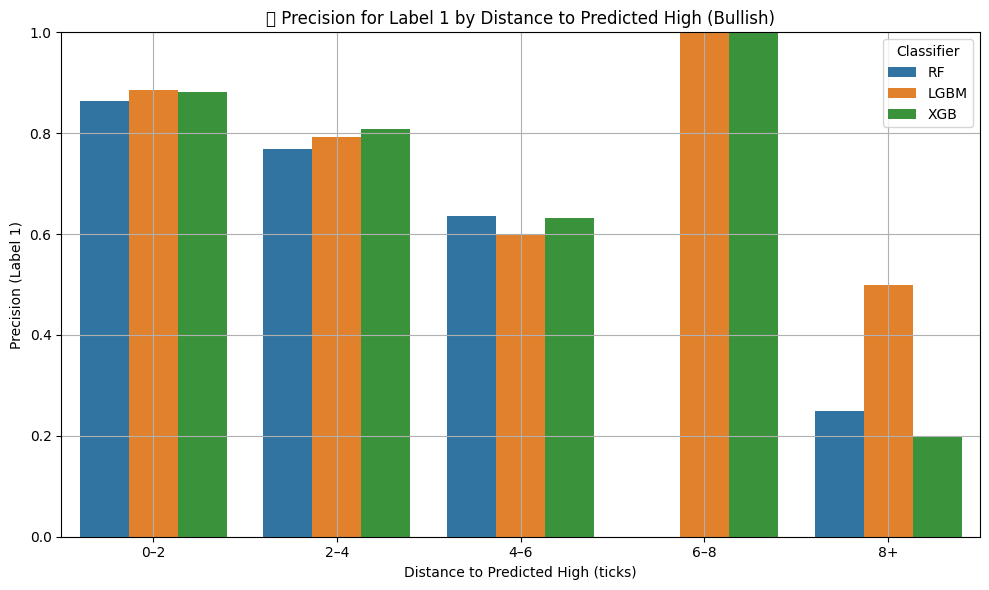

,Bin,Model,Precision_1,Count
0,0–2,RF,0.864238,745
1,2–4,RF,0.769231,366
2,4–6,RF,0.636364,68
3,6–8,RF,0.000000,6
4,8+,RF,0.250000,12
5,0–2,LGBM,0.886207,745
6,2–4,LGBM,0.793296,366
7,4–6,LGBM,0.600000,68
8,6–8,LGBM,1.000000,6
9,8+,LGBM,0.500000,12


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score

# Use Bullish variant as example – you can repeat for All variant similarly
df_test_bullish = X_test_bullish.copy()
df_test_bullish["Close"] = trainer.x_test_with_meta.loc[X_test_bullish.index]["Close"]
df_test_bullish["Predicted_High"] = trainer.x_test_with_meta.loc[X_test_bullish.index]["Predicted_High"]
df_test_bullish["distance"] = df_test_bullish["Predicted_High"] - df_test_bullish["Close"]

# Add classifier predictions for comparison (assumes you've trained already)
df_test_bullish["True_Label"] = y_test_bullish.values
df_test_bullish["Pred_RF"] = classifier_trainer_bullish.rf_results["predictions"]
df_test_bullish["Pred_LGBM"] = classifier_trainer_bullish.lgbm_results["predictions"]
df_test_bullish["Pred_XGB"] = classifier_trainer_bullish.xgb_results["predictions"]

# Define distance bins (in ticks or points)
bins = [-float("inf"), 0, 2, 4, 6, 8, float("inf")]
labels = ["<0", "0–2", "2–4", "4–6", "6–8", "8+"]
df_test_bullish["distance_bin"] = pd.cut(df_test_bullish["distance"], bins=bins, labels=labels)

# Calculate precision per bin per classifier (for Label 1)
results = []
for model in ["Pred_RF", "Pred_LGBM", "Pred_XGB"]:
    for bin_label in labels:
        bin_data = df_test_bullish[df_test_bullish["distance_bin"] == bin_label]
        if not bin_data.empty:
            y_true = bin_data["True_Label"]
            y_pred = bin_data[model]
            prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
            results.append({
                "Bin": bin_label,
                "Model": model.replace("Pred_", ""),
                "Precision_1": prec,
                "Count": len(bin_data)
            })

df_precision_by_distance = pd.DataFrame(results)

# 📊 Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_precision_by_distance, x="Bin", y="Precision_1", hue="Model")
plt.title("📈 Precision for Label 1 by Distance to Predicted High (Bullish)")
plt.ylabel("Precision (Label 1)")
plt.xlabel("Distance to Predicted High (ticks)")
plt.ylim(0, 1)
plt.grid(True)
plt.legend(title="Classifier")
plt.tight_layout()
plt.show()

# Optional: Display table
df_precision_by_distance

In [26]:
# Step 1: Start from df_labeled_bullish and add Prev_Label
df_labeled_bullish_with_prev_label = df_labeled_bullish.copy()
df_labeled_bullish_with_prev_label["Prev_Label"] = df_labeled_bullish_with_prev_label["long_good_bar_label"].shift(1)

# Step 2: Drop rows where Prev_Label is NaN (first row after shift)
df_labeled_bullish_with_prev_label = df_labeled_bullish_with_prev_label.dropna(subset=["Prev_Label"])

# Step 3: Make sure Prev_Label is int
df_labeled_bullish_with_prev_label["Prev_Label"] = df_labeled_bullish_with_prev_label["Prev_Label"].astype(int)

# ✅ Now you're ready to run the CV distance analysis cell!


🎯 Cross-Validated Precision by Distance Bin Analysis

📊 Distance Bin Distribution:
  <0: 5 samples (0.1%)
  0–2: 3594 samples (60.1%)
  2–4: 1611 samples (26.9%)
  4–6: 555 samples (9.3%)
  6–8: 142 samples (2.4%)
  8+: 75 samples (1.3%)

🔁 Running cross-validation by distance bin...
  ⚠️ Skipping bin <0 - insufficient samples (5)
  Processing bin 0–2 (3594 samples)
    RF - Precision: 0.870 (from 3594 cross-validated samples)
    LGBM - Precision: 0.881 (from 3594 cross-validated samples)
    XGB - Precision: 0.877 (from 3594 cross-validated samples)
  Processing bin 2–4 (1611 samples)
    RF - Precision: 0.869 (from 1611 cross-validated samples)
    LGBM - Precision: 0.884 (from 1611 cross-validated samples)
    XGB - Precision: 0.887 (from 1611 cross-validated samples)
  Processing bin 4–6 (555 samples)
    RF - Precision: 0.863 (from 555 cross-validated samples)
    LGBM - Precision: 0.863 (from 555 cross-validated samples)
    XGB - Precision: 0.862 (from 555 cross-validated sampl

C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\118364399.py:138: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


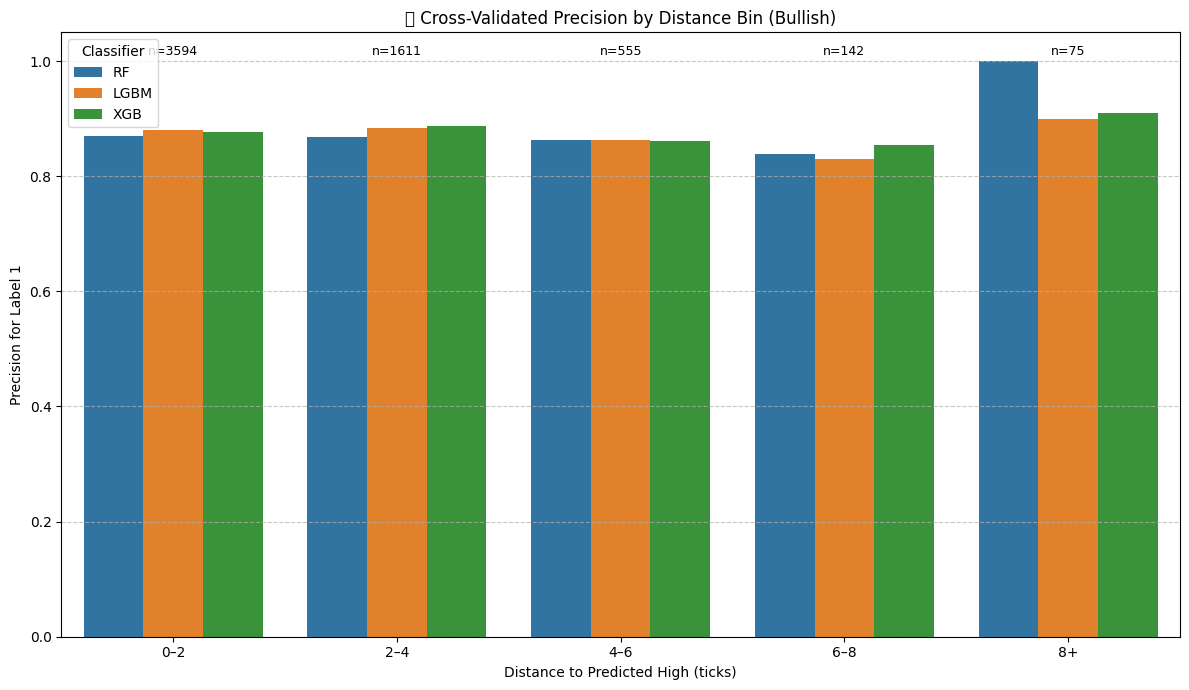


📋 Cross-Validated Precision (Label 1) by Distance Bin:


Model,LGBM,RF,XGB,Sample_Count
Bin,,,,
0–2,0.881,0.870,0.877,3594
2–4,0.884,0.869,0.887,1611
4–6,0.863,0.863,0.862,555
6–8,0.829,0.839,0.854,142
8+,0.900,1.000,0.909,75


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import precision_score
from sklearn.model_selection import KFold

# Use Bullish variant as example
print("🎯 Cross-Validated Precision by Distance Bin Analysis\n")

# Combine train and test data for cross-validation
X_bullish_all = pd.concat([X_train_bullish, X_test_bullish])
y_bullish_all = pd.concat([y_train_bullish, y_test_bullish])

# Get Close and Predicted_High for all samples
all_indices = X_bullish_all.index
filtered_meta = trainer.x_test_with_meta.loc[trainer.x_test_with_meta.index.isin(all_indices)]

# Get only needed columns from meta and rename them to avoid overlap
filtered_meta_subset = filtered_meta[["Close", "Predicted_High"]].copy()
filtered_meta_subset = filtered_meta_subset.rename(columns={
    "Close": "Price_Close", 
    "Predicted_High": "Price_Predicted_High"
})

# Create the main dataframe with features and labels
df_bullish_cv = X_bullish_all.copy()
df_bullish_cv["True_Label"] = y_bullish_all.values

# Add price data with renamed columns to avoid overlap
df_bullish_cv = df_bullish_cv.join(filtered_meta_subset, how="inner")

# Calculate distance using renamed columns
df_bullish_cv["distance"] = df_bullish_cv["Price_Predicted_High"] - df_bullish_cv["Price_Close"]

# Define distance bins (in ticks or points)
bins = [-float("inf"), 0, 2, 4, 6, 8, float("inf")]
labels = ["<0", "0–2", "2–4", "4–6", "6–8", "8+"]
df_bullish_cv["distance_bin"] = pd.cut(df_bullish_cv["distance"], bins=bins, labels=labels)

# Print bin distribution
bin_counts = df_bullish_cv["distance_bin"].value_counts().sort_index()
print("📊 Distance Bin Distribution:")
for bin_label, count in bin_counts.items():
    percent = count / len(df_bullish_cv) * 100
    print(f"  {bin_label}: {count} samples ({percent:.1f}%)")

# Create K-fold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize models
models = {
    "RF": RandomForestClassifier(random_state=42),
    "LGBM": LGBMClassifier(random_state=42),
    "XGB": XGBClassifier(random_state=42, eval_metric='logloss')
}

# Store results by bin and model
cv_precision_by_bin = []

print("\n🔁 Running cross-validation by distance bin...")

# Process each bin separately
for bin_label in labels:
    # Get samples in this bin
    bin_mask = df_bullish_cv["distance_bin"] == bin_label
    bin_samples = df_bullish_cv[bin_mask]
    
    if len(bin_samples) < 10:  # Skip bins with too few samples
        print(f"  ⚠️ Skipping bin {bin_label} - insufficient samples ({len(bin_samples)})")
        continue
        
    print(f"  Processing bin {bin_label} ({len(bin_samples)} samples)")
    
    # Get features and labels - exclude all non-feature columns
    cols_to_drop = ["True_Label", "distance", "distance_bin", "Price_Close", "Price_Predicted_High"]
    X_bin = bin_samples.drop(cols_to_drop, axis=1, errors='ignore')
    y_bin = bin_samples["True_Label"]
    
    # Apply cross-validation for each model
    for model_name, model in models.items():
        # Store predictions from each fold
        all_true = []
        all_pred = []
        
        for train_idx, test_idx in kf.split(X_bin):
            # Skip if a fold has too few samples of each class
            if len(np.unique(y_bin.iloc[train_idx])) < 2 or len(np.unique(y_bin.iloc[test_idx])) < 2:
                continue
                
            # Split data into train and test for this fold
            X_train_fold, X_test_fold = X_bin.iloc[train_idx], X_bin.iloc[test_idx]
            y_train_fold, y_test_fold = y_bin.iloc[train_idx], y_bin.iloc[test_idx]
            
            # Train and predict
            model.fit(X_train_fold, y_train_fold)
            y_pred_fold = model.predict(X_test_fold)
            
            # Store results
            all_true.extend(y_test_fold)
            all_pred.extend(y_pred_fold)
        
        # Calculate precision only if we have predictions
        if len(all_true) > 0 and 1 in all_true:
            prec = precision_score(all_true, all_pred, pos_label=1, zero_division=0)
            
            # Add to results
            cv_precision_by_bin.append({
                "Bin": bin_label,
                "Model": model_name,
                "Precision_1": prec,
                "Count": len(bin_samples)
            })
            print(f"    {model_name} - Precision: {prec:.3f} (from {len(all_true)} cross-validated samples)")

# Convert to DataFrame
df_cv_precision_by_distance = pd.DataFrame(cv_precision_by_bin)

# Plot results if we have data
if not df_cv_precision_by_distance.empty:
    plt.figure(figsize=(12, 7))
    
    # Main bar chart
    ax = sns.barplot(data=df_cv_precision_by_distance, x="Bin", y="Precision_1", hue="Model")
    
    # Add count labels above bars
    for bin_label in df_cv_precision_by_distance["Bin"].unique():
        bin_count = df_cv_precision_by_distance[df_cv_precision_by_distance["Bin"] == bin_label]["Count"].iloc[0]
        bin_index = list(df_cv_precision_by_distance["Bin"].unique()).index(bin_label)
        plt.text(bin_index, 1.01, f"n={bin_count}", ha='center', fontsize=9)
    
    plt.title("📊 Cross-Validated Precision by Distance Bin (Bullish)")
    plt.ylabel("Precision for Label 1")
    plt.xlabel("Distance to Predicted High (ticks)")
    plt.ylim(0, 1.05)  # Leave room for count labels
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Classifier")
    plt.tight_layout()
    plt.show()

# Display table with results
if not df_cv_precision_by_distance.empty:
    # Create a pivot table for easier reading
    pivot_df = df_cv_precision_by_distance.pivot(index="Bin", columns="Model", values="Precision_1")
    pivot_df["Sample_Count"] = df_cv_precision_by_distance.drop_duplicates("Bin").set_index("Bin")["Count"]
    
    # Sort by bin
    bin_order = {label: i for i, label in enumerate(labels)}
    pivot_df = pivot_df.reset_index()
    pivot_df["bin_order"] = pivot_df["Bin"].map(bin_order)
    pivot_df = pivot_df.sort_values("bin_order").drop("bin_order", axis=1).set_index("Bin")
    
    print("\n📋 Cross-Validated Precision (Label 1) by Distance Bin:")
    display(pivot_df.style.format("{:.3f}", subset=["RF", "LGBM", "XGB"]))
else:
    print("\n⚠️ No results to display - check if bins have sufficient samples")

# creating new labels option B 


In [28]:
df_for_labeling = trainer.x_test_with_meta.copy()
df_for_labeling["Predicted_High"] = trainer.predictions[:len(df_for_labeling)]

# ❌ No shifting
# ✅ Use current Close + current Predicted_High to label this bar
df_labeled_bullish = label_generator.long_good_bar_label_bullish_only_goal_b(df_for_labeling)

df_labeled_all = label_generator.long_good_bar_label_all_goal_b(df_for_labeling)



✅ Goal B Bullish Label applied (1 = this bar's High ≥ this bar's Predicted_High).
✅ Goal B ALL Label applied (1 = High ≥ Predicted_High).


In [29]:
from imblearn.over_sampling import SMOTE

processor = DataProcessor()
trainer_b = trainer.copy()  # ✅ Create a separate copy for Option B

# 🔵 All-bar version (Goal B)
X_train_all_goal_b, y_train_all_goal_b, X_test_all_goal_b, y_test_all_goal_b = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_all,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)
smote_all_goal_b = SMOTE(random_state=42)
classifier_X_train_bal_all_goal_b, classifier_y_train_bal_all_goal_b = smote_all_goal_b.fit_resample(
    X_train_all_goal_b, y_train_all_goal_b
)

trainer_b.x_test_with_meta = df_labeled_all.loc[X_test_all_goal_b.index]

print("🧪 Notebook Alignment Check – Option B")
print("trainer_b.x_test_with_meta index:", trainer_b.x_test_with_meta.index[:5])
print("X_test_all_goal_b index:", X_test_all_goal_b.index[:5])
print("⏳ Are they equal?", trainer_b.x_test_with_meta.index.equals(X_test_all_goal_b.index))

# ✅ Train classifiers (All Bars)
classifier_trainer_all_goal_b = ClassifierModelTrainer()
classifier_trainer_all_goal_b.train_all_classifiers(
    classifier_X_train_bal_all_goal_b,
    classifier_y_train_bal_all_goal_b,
    X_test_all_goal_b,
    y_test_all_goal_b,
    trainer_b
)

# 🟣 Bullish-only version (Goal B)
X_train_bullish_goal_b, y_train_bullish_goal_b, X_test_bullish_goal_b, y_test_bullish_goal_b = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_bullish,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

X_test_all_goal_b = X_test_all_goal_b.select_dtypes(include='number')

smote_bullish_goal_b = SMOTE(random_state=42)
classifier_X_train_bal_bullish_goal_b, classifier_y_train_bal_bullish_goal_b = smote_bullish_goal_b.fit_resample(
    X_train_bullish_goal_b, y_train_bullish_goal_b
)

trainer_b.x_test_with_meta = df_labeled_bullish.loc[X_test_bullish_goal_b.index]
X_test_bullish_goal_b = X_test_bullish_goal_b.select_dtypes(include='number')

classifier_trainer_bullish_goal_b = ClassifierModelTrainer()
classifier_trainer_bullish_goal_b.train_all_classifiers(
    classifier_X_train_bal_bullish_goal_b,
    classifier_y_train_bal_bullish_goal_b,
    X_test_bullish_goal_b,
    y_test_bullish_goal_b,
    trainer_b
)

print("✅ Training complete using Goal B labels (All Bars + Bullish Only)")



✅ Sample Data Alignment Check:
   Sample Target (y_test) Corresponding Feature Row
0                       1       2025-01-15 12:00:00
1                       0       2025-01-15 12:05:00
2                       1       2025-01-15 12:10:00
3                       1       2025-01-15 12:15:00
4                       1       2025-01-15 12:20:00
🧪 Notebook Alignment Check – Option B
trainer_b.x_test_with_meta index: DatetimeIndex(['2025-01-15 12:00:00', '2025-01-15 12:05:00',
               '2025-01-15 12:10:00', '2025-01-15 12:15:00',
               '2025-01-15 12:20:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)
X_test_all_goal_b index: DatetimeIndex(['2025-01-15 12:00:00', '2025-01-15 12:05:00',
               '2025-01-15 12:10:00', '2025-01-15 12:15:00',
               '2025-01-15 12:20:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)
⏳ Are they equal? True
✅ ClassifierModelTrainer initialized!

🚀 Training all classifiers...

🚀 Training

In [30]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd

# ✅ Define Goal B variants
variants_b = {
    "GoalB_All": (X_train_all_goal_b, y_train_all_goal_b, X_test_all_goal_b, y_test_all_goal_b),
    "GoalB_Bullish": (X_train_bullish_goal_b, y_train_bullish_goal_b, X_test_bullish_goal_b, y_test_bullish_goal_b),
}

# Models
model_classes = {
    'RandomForest': RandomForestClassifier,
    'LightGBM': LGBMClassifier,
    'XGBoost': XGBClassifier,
}

cv_results_b_smote = []
print("📊 Cross-Validation Results – Goal B with SMOTE (F1 + Precision for Label 1 and 0):\n")

for variant_name, (X_train, y_train, X_test, y_test) in variants_b.items():
    print(f"🔹 {variant_name}:\n")
    X_all = pd.concat([X_train, X_test])
    y_all = pd.concat([y_train, y_test])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for model_name, model_cls in model_classes.items():
        y_true_all = []
        y_pred_all = []

        for train_idx, test_idx in skf.split(X_all, y_all):
            X_fold_train, y_fold_train = X_all.iloc[train_idx], y_all.iloc[train_idx]
            X_fold_test, y_fold_test = X_all.iloc[test_idx], y_all.iloc[test_idx]

            # 🟦 Apply SMOTE to training fold only
            smote = SMOTE(random_state=42)
            X_resampled, y_resampled = smote.fit_resample(X_fold_train, y_fold_train)

            model = model_cls(random_state=42)
            model.fit(X_resampled, y_resampled)
            y_pred = model.predict(X_fold_test)

            y_true_all.extend(y_fold_test)
            y_pred_all.extend(y_pred)

        report = classification_report(y_true_all, y_pred_all, output_dict=True, zero_division=0)

        f1_label_1 = report['1']['f1-score']
        precision_1 = report['1']['precision']
        precision_0 = report['0']['precision']

        print(f"  {model_name}: F1 = {f1_label_1:.3f} | Precision (1) = {precision_1:.3f} | Precision (0) = {precision_0:.3f}")
        cv_results_b_smote.append({
            "Variant": variant_name,
            "Model": model_name,
            "F1_Label_1": f1_label_1,
            "Precision_Label_1": precision_1,
            "Precision_Label_0": precision_0
        })

    print("-" * 60)

# Optional: convert to DataFrame
cv_results_b_smote_df = pd.DataFrame(cv_results_b_smote)


📊 Cross-Validation Results – Goal B with SMOTE (F1 + Precision for Label 1 and 0):

🔹 GoalB_All:

  RandomForest: F1 = 0.795 | Precision (1) = 0.818 | Precision (0) = 0.855
  LightGBM: F1 = 0.840 | Precision (1) = 0.851 | Precision (0) = 0.889
  XGBoost: F1 = 0.851 | Precision (1) = 0.860 | Precision (0) = 0.896
------------------------------------------------------------
🔹 GoalB_Bullish:

  RandomForest: F1 = 0.796 | Precision (1) = 0.820 | Precision (0) = 0.856
  LightGBM: F1 = 0.853 | Precision (1) = 0.857 | Precision (0) = 0.901
  XGBoost: F1 = 0.853 | Precision (1) = 0.858 | Precision (0) = 0.901
------------------------------------------------------------


# creating new labels option C
### ✅ Decision: Moving Forward with **Option C** for Classifier Labeling

After testing and evaluating multiple labeling strategies, we have decided to adopt **Option C** as our main classifier labeling method.

---

### 🔍 What is Option C?

Option C labels bar **T** as a _good bar_ if the **next bar's High** (T+1) is greater than or equal to the **Predicted High** generated at T.

This means:
> **"Given the prediction I made at time T, was it realistic in hindsight — and can I learn from the setup at T to improve future trades?"**

---

### ❌ Why we **discarded Option A**

- **Option A** labeled each bar by checking if the **current bar's High** (T) reached the **previous prediction** (from T-1).
- This setup creates artificially high precision/recall, since it reflects what has already happened — not what can be predicted.
- It’s **not usable for real-time trading**, because the label depends on known outcomes that the model doesn't have at decision time.

---

### ✅ Why Option C is better for live trading

- It **simulates a real decision-making setup**: I’m at bar T and want to know whether to trade, based on whether bar T+1 will reach my predicted target.
- It allows the classifier to learn patterns that **precede successful outcomes**, without leaking future data.
- Performance is more realistic and **aligned with live trading conditions**, even if precision/recall is lower.

---

### 🧭 Next Steps

- Focus on **improving Option C metrics** with better features, label refinements, or model tuning.
- Evaluate **bullish-only vs. all-bar variants** depending on trade filtering goals.
- Treat Option A as a possible **feature analysis tool**, but not for live decisions.



In [31]:
# ✅ Option C: Labeling using Next Bar's High vs Current Predicted High
df_for_labeling_c = trainer.x_test_with_meta.copy()
df_for_labeling_c["Predicted_High"] = trainer.predictions[:len(df_for_labeling_c)]

# ✅ Apply Option C labels
df_labeled_all_c = label_generator.long_good_bar_label_all_goal_c(df_for_labeling_c)
df_labeled_bullish_c = label_generator.long_good_bar_label_bullish_only_goal_c(df_for_labeling_c)


✅ Goal C ALL Label applied (1 = Next High ≥ Predicted High).
✅ Goal C Bullish Label applied (1 = bullish setup + Next High ≥ Predicted High).


In [32]:
from imblearn.over_sampling import SMOTE

processor = DataProcessor()
trainer_c = trainer.copy()  # ✅ Create a dedicated copy for Option C

# 🔵 All-bar version (Goal C)
X_train_all_goal_c, y_train_all_goal_c, X_test_all_goal_c, y_test_all_goal_c = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_all_c,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

# ✅ Balance the training set
smote_all_goal_c = SMOTE(random_state=42)
classifier_X_train_bal_all_goal_c, classifier_y_train_bal_all_goal_c = smote_all_goal_c.fit_resample(
    X_train_all_goal_c, y_train_all_goal_c
)

# ✅ Store metadata for alignment
trainer_c.x_test_with_meta = df_labeled_all_c.loc[X_test_all_goal_c.index]

# ✅ Keep only numeric columns
X_test_all_goal_c = X_test_all_goal_c.select_dtypes(include='number')

print("🧪 Notebook Alignment Check – Option C")
print("trainer_c.x_test_with_meta index:", trainer_c.x_test_with_meta.index[:5])
print("X_test_all_goal_c index:", X_test_all_goal_c.index[:5])
print("⏳ Are they equal?", trainer_c.x_test_with_meta.index.equals(X_test_all_goal_c.index))

# ✅ Train classifiers (All Bars)
classifier_trainer_all_goal_c = ClassifierModelTrainer()
classifier_trainer_all_goal_c.train_all_classifiers(
    classifier_X_train_bal_all_goal_c,
    classifier_y_train_bal_all_goal_c,
    X_test_all_goal_c,
    y_test_all_goal_c,
    trainer_c
)

# 🟣 Bullish-only version (Goal C)
X_train_bullish_goal_c, y_train_bullish_goal_c, X_test_bullish_goal_c, y_test_bullish_goal_c = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_bullish_c,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

smote_bullish_goal_c = SMOTE(random_state=42)
classifier_X_train_bal_bullish_goal_c, classifier_y_train_bal_bullish_goal_c = smote_bullish_goal_c.fit_resample(
    X_train_bullish_goal_c, y_train_bullish_goal_c
)

trainer_c.x_test_with_meta = df_labeled_bullish_c.loc[X_test_bullish_goal_c.index]

X_test_bullish_goal_c = X_test_bullish_goal_c.select_dtypes(include='number')

classifier_trainer_bullish_goal_c = ClassifierModelTrainer()
classifier_trainer_bullish_goal_c.train_all_classifiers(
    classifier_X_train_bal_bullish_goal_c,
    classifier_y_train_bal_bullish_goal_c,
    X_test_bullish_goal_c,
    y_test_bullish_goal_c,
    trainer_c
)

print("✅ Training complete using Goal C labels (All Bars + Bullish Only)")



✅ Sample Data Alignment Check:
   Sample Target (y_test) Corresponding Feature Row
0                       0       2025-01-15 12:00:00
1                       0       2025-01-15 12:05:00
2                       1       2025-01-15 12:10:00
3                       0       2025-01-15 12:15:00
4                       1       2025-01-15 12:20:00
🧪 Notebook Alignment Check – Option C
trainer_c.x_test_with_meta index: DatetimeIndex(['2025-01-15 12:00:00', '2025-01-15 12:05:00',
               '2025-01-15 12:10:00', '2025-01-15 12:15:00',
               '2025-01-15 12:20:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)
X_test_all_goal_c index: DatetimeIndex(['2025-01-15 12:00:00', '2025-01-15 12:05:00',
               '2025-01-15 12:10:00', '2025-01-15 12:15:00',
               '2025-01-15 12:20:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)
⏳ Are they equal? True
✅ ClassifierModelTrainer initialized!

🚀 Training all classifiers...

🚀 Training

In [33]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd

# ✅ Define Goal B variants
variants_c = {
    "GoalB_All": (X_train_all_goal_c, y_train_all_goal_c, X_test_all_goal_c, y_test_all_goal_c),
    "GoalB_Bullish": (X_train_bullish_goal_c, y_train_bullish_goal_c, X_test_bullish_goal_c, y_test_bullish_goal_c),
}

# Models
model_classes = {
    'RandomForest': RandomForestClassifier,
    'LightGBM': LGBMClassifier,
    'XGBoost': XGBClassifier,
}

cv_results_c_smote = []
print("📊 Cross-Validation Results – Goal c with SMOTE (F1 + Precision for Label 1 and 0):\n")

for variant_name, (X_train, y_train, X_test, y_test) in variants_c.items():
    print(f"🔹 {variant_name}:\n")
    X_all = pd.concat([X_train, X_test])
    y_all = pd.concat([y_train, y_test])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for model_name, model_cls in model_classes.items():
        y_true_all = []
        y_pred_all = []

        for train_idx, test_idx in skf.split(X_all, y_all):
            X_fold_train, y_fold_train = X_all.iloc[train_idx], y_all.iloc[train_idx]
            X_fold_test, y_fold_test = X_all.iloc[test_idx], y_all.iloc[test_idx]

            # 🟦 Apply SMOTE to training fold only
            smote = SMOTE(random_state=42)
            X_resampled, y_resampled = smote.fit_resample(X_fold_train, y_fold_train)

            model = model_cls(random_state=42)
            model.fit(X_resampled, y_resampled)
            y_pred = model.predict(X_fold_test)

            y_true_all.extend(y_fold_test)
            y_pred_all.extend(y_pred)

        report = classification_report(y_true_all, y_pred_all, output_dict=True, zero_division=0)

        f1_label_1 = report['1']['f1-score']
        precision_1 = report['1']['precision']
        precision_0 = report['0']['precision']

        print(f"  {model_name}: F1 = {f1_label_1:.3f} | Precision (1) = {precision_1:.3f} | Precision (0) = {precision_0:.3f}")
        cv_results_c_smote.append({
            "Variant": variant_name,
            "Model": model_name,
            "F1_Label_1": f1_label_1,
            "Precision_Label_1": precision_1,
            "Precision_Label_0": precision_0
        })

    print("-" * 60)

# Optional: convert to DataFrame
cv_results_c_smote_df = pd.DataFrame(cv_results_c_smote)


📊 Cross-Validation Results – Goal c with SMOTE (F1 + Precision for Label 1 and 0):

🔹 GoalB_All:

  RandomForest: F1 = 0.428 | Precision (1) = 0.459 | Precision (0) = 0.621
  LightGBM: F1 = 0.538 | Precision (1) = 0.580 | Precision (0) = 0.687
  XGBoost: F1 = 0.530 | Precision (1) = 0.555 | Precision (0) = 0.680
------------------------------------------------------------
🔹 GoalB_Bullish:

  RandomForest: F1 = 0.413 | Precision (1) = 0.436 | Precision (0) = 0.612
  LightGBM: F1 = 0.513 | Precision (1) = 0.563 | Precision (0) = 0.675
  XGBoost: F1 = 0.524 | Precision (1) = 0.547 | Precision (0) = 0.678
------------------------------------------------------------


## Adding previous signal as feature attempt

In [34]:
# ✅ Add previous signal features to labeled DataFrames (Option C)

label_col = "long_good_bar_label"  # still the same for Option C

# --- For ALL (Goal C) ---
df_labeled_all_c["Prev_Label"] = df_labeled_all_c[label_col].shift(1)

# --- For BULLISH (Goal C) ---
df_labeled_bullish_c["Prev_Label"] = df_labeled_bullish_c[label_col].shift(1)

# Drop rows with NaN in Prev_Label after shift
df_labeled_all_c = df_labeled_all_c.dropna(subset=["Prev_Label"])
df_labeled_bullish_c = df_labeled_bullish_c.dropna(subset=["Prev_Label"])

# Convert Prev_Label to integer
df_labeled_all_c["Prev_Label"] = df_labeled_all_c["Prev_Label"].astype(int)
df_labeled_bullish_c["Prev_Label"] = df_labeled_bullish_c["Prev_Label"].astype(int)

print("✅ Previous signal features added to both Option C labeled DataFrames.")


✅ Previous signal features added to both Option C labeled DataFrames.


In [35]:
from imblearn.over_sampling import SMOTE

processor = DataProcessor()
trainer_c2 = trainer.copy()  # ✅ Separate copy for this training round (Option C with updated labels)

# 🔵 All-bar version (Goal C)
X_train_all_goal_c, y_train_all_goal_c, X_test_all_goal_c, y_test_all_goal_c = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_all_c,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

smote_all_goal_c = SMOTE(random_state=42)
classifier_X_train_bal_all_goal_c, classifier_y_train_bal_all_goal_c = smote_all_goal_c.fit_resample(
    X_train_all_goal_c, y_train_all_goal_c
)

trainer_c2.x_test_with_meta = df_labeled_all_c.loc[X_test_all_goal_c.index]
X_test_all_goal_c = X_test_all_goal_c.select_dtypes(include='number')

classifier_trainer_all_goal_c = ClassifierModelTrainer()
classifier_trainer_all_goal_c.train_all_classifiers(
    classifier_X_train_bal_all_goal_c,
    classifier_y_train_bal_all_goal_c,
    X_test_all_goal_c,
    y_test_all_goal_c,
    trainer_c2
)

# 🟣 Bullish-only version (Goal C)
X_train_bullish_goal_c, y_train_bullish_goal_c, X_test_bullish_goal_c, y_test_bullish_goal_c = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_bullish_c,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

smote_bullish_goal_c = SMOTE(random_state=42)
classifier_X_train_bal_bullish_goal_c, classifier_y_train_bal_bullish_goal_c = smote_bullish_goal_c.fit_resample(
    X_train_bullish_goal_c, y_train_bullish_goal_c
)

trainer_c2.x_test_with_meta = df_labeled_bullish_c.loc[X_test_bullish_goal_c.index]
X_test_bullish_goal_c = X_test_bullish_goal_c.select_dtypes(include='number')

classifier_trainer_bullish_goal_c = ClassifierModelTrainer()
classifier_trainer_bullish_goal_c.train_all_classifiers(
    classifier_X_train_bal_bullish_goal_c,
    classifier_y_train_bal_bullish_goal_c,
    X_test_bullish_goal_c,
    y_test_bullish_goal_c,
    trainer_c2
)

print("✅ Training complete using Option C (fresh-labeled) DataFrames")



✅ Sample Data Alignment Check:
   Sample Target (y_test) Corresponding Feature Row
0                       0       2025-01-15 12:00:00
1                       0       2025-01-15 12:05:00
2                       1       2025-01-15 12:10:00
3                       0       2025-01-15 12:15:00
4                       1       2025-01-15 12:20:00
✅ ClassifierModelTrainer initialized!

🚀 Training all classifiers...

🚀 Training RandomForest...

📊 RandomForest Evaluation:
              precision    recall  f1-score   support

           0       0.63      0.66      0.64       722
           1       0.45      0.42      0.44       478

    accuracy                           0.56      1200
   macro avg       0.54      0.54      0.54      1200
weighted avg       0.56      0.56      0.56      1200


🎯 RandomForest Accuracy: 0.5642

🚀 Training LightGBM...

📊 LightGBM Evaluation:
              precision    recall  f1-score   support

           0       0.63      0.73      0.68       722
           1  

In [36]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd

# ✅ Define Goal B variants
variants_c = {
    "GoalB_All": (X_train_all_goal_c, y_train_all_goal_c, X_test_all_goal_c, y_test_all_goal_c),
    "GoalB_Bullish": (X_train_bullish_goal_c, y_train_bullish_goal_c, X_test_bullish_goal_c, y_test_bullish_goal_c),
}

# Models
model_classes = {
    'RandomForest': RandomForestClassifier,
    'LightGBM': LGBMClassifier,
    'XGBoost': XGBClassifier,
}

cv_results_c_smote = []
print("📊 Cross-Validation Results – Goal C with SMOTE (F1 + Precision for Label 1 and 0):\n")

for variant_name, (X_train, y_train, X_test, y_test) in variants_c.items():
    print(f"🔹 {variant_name}:\n")
    X_all = pd.concat([X_train, X_test])
    y_all = pd.concat([y_train, y_test])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for model_name, model_cls in model_classes.items():
        y_true_all = []
        y_pred_all = []

        for train_idx, test_idx in skf.split(X_all, y_all):
            X_fold_train, y_fold_train = X_all.iloc[train_idx], y_all.iloc[train_idx]
            X_fold_test, y_fold_test = X_all.iloc[test_idx], y_all.iloc[test_idx]

            # 🟦 Apply SMOTE to training fold only
            smote = SMOTE(random_state=42)
            X_resampled, y_resampled = smote.fit_resample(X_fold_train, y_fold_train)

            model = model_cls(random_state=42)
            model.fit(X_resampled, y_resampled)
            y_pred = model.predict(X_fold_test)

            y_true_all.extend(y_fold_test)
            y_pred_all.extend(y_pred)

        report = classification_report(y_true_all, y_pred_all, output_dict=True, zero_division=0)

        f1_label_1 = report['1']['f1-score']
        precision_1 = report['1']['precision']
        precision_0 = report['0']['precision']

        print(f"  {model_name}: F1 = {f1_label_1:.3f} | Precision (1) = {precision_1:.3f} | Precision (0) = {precision_0:.3f}")
        cv_results_c_smote.append({
            "Variant": variant_name,
            "Model": model_name,
            "F1_Label_1": f1_label_1,
            "Precision_Label_1": precision_1,
            "Precision_Label_0": precision_0
        })

    print("-" * 60)

# Optional: convert to DataFrame
cv_results_c_smote_df = pd.DataFrame(cv_results_c_smote)


📊 Cross-Validation Results – Goal C with SMOTE (F1 + Precision for Label 1 and 0):

🔹 GoalB_All:

  RandomForest: F1 = 0.416 | Precision (1) = 0.445 | Precision (0) = 0.614
  LightGBM: F1 = 0.534 | Precision (1) = 0.575 | Precision (0) = 0.684
  XGBoost: F1 = 0.519 | Precision (1) = 0.548 | Precision (0) = 0.674
------------------------------------------------------------
🔹 GoalB_Bullish:

  RandomForest: F1 = 0.405 | Precision (1) = 0.438 | Precision (0) = 0.611
  LightGBM: F1 = 0.524 | Precision (1) = 0.572 | Precision (0) = 0.681
  XGBoost: F1 = 0.518 | Precision (1) = 0.546 | Precision (0) = 0.675
------------------------------------------------------------


# option c distibutn of precision in Bins


🔍 Missing timestamps in trainer_c.x_test_with_meta: 3
🧯 First few missing timestamps: [Timestamp('2025-01-15 12:00:00'), Timestamp('2025-01-15 12:05:00'), Timestamp('2025-01-15 12:10:00')]


C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\1978756145.py:61: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


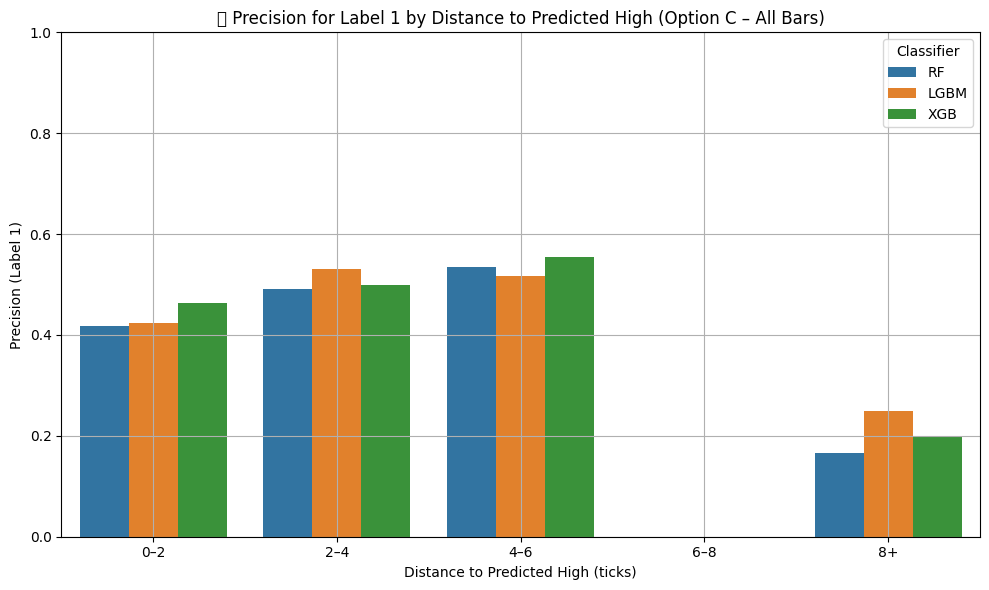

,Bin,Model,Precision_1,Count
0,0–2,RF,0.417021,745
1,2–4,RF,0.491620,366
2,4–6,RF,0.535714,68
3,6–8,RF,0.000000,6
4,8+,RF,0.166667,12
5,0–2,LGBM,0.424242,745
6,2–4,LGBM,0.529851,366
7,4–6,LGBM,0.517241,68
8,6–8,LGBM,0.000000,6
9,8+,LGBM,0.250000,12


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score

# ✅ DEBUG: Check for index mismatch
missing_idx = [i for i in X_test_all_goal_c.index if i not in trainer_c.x_test_with_meta.index]
print(f"🔍 Missing timestamps in trainer_c.x_test_with_meta: {len(missing_idx)}")
if missing_idx:
    print("🧯 First few missing timestamps:", missing_idx[:5])

# ✅ Fix: Align trainer_c.x_test_with_meta to valid test indices
trainer_c.x_test_with_meta = trainer_c.x_test_with_meta.loc[
    trainer_c.x_test_with_meta.index.intersection(X_test_all_goal_c.index)
]

# ✅ Use All Bars variant from Option C
df_test_all_c = X_test_all_goal_c.copy()
df_test_all_c["Close"] = trainer_c.x_test_with_meta["Close"]
df_test_all_c["Predicted_High"] = trainer_c.x_test_with_meta["Predicted_High"]
df_test_all_c["distance"] = df_test_all_c["Predicted_High"] - df_test_all_c["Close"]

# ✅ Add true labels and predictions
df_test_all_c["True_Label"] = y_test_all_goal_c.values
df_test_all_c["Pred_RF"] = classifier_trainer_all_goal_c.rf_results["predictions"]
df_test_all_c["Pred_LGBM"] = classifier_trainer_all_goal_c.lgbm_results["predictions"]
df_test_all_c["Pred_XGB"] = classifier_trainer_all_goal_c.xgb_results["predictions"]

# ✅ Define distance bins
bins = [-float("inf"), 0, 2, 4, 6, 8, float("inf")]
labels = ["<0", "0–2", "2–4", "4–6", "6–8", "8+"]
df_test_all_c["distance_bin"] = pd.cut(df_test_all_c["distance"], bins=bins, labels=labels)

# ✅ Calculate precision per bin per classifier
results = []
for model in ["Pred_RF", "Pred_LGBM", "Pred_XGB"]:
    for bin_label in labels:
        bin_data = df_test_all_c[df_test_all_c["distance_bin"] == bin_label]
        if not bin_data.empty:
            y_true = bin_data["True_Label"]
            y_pred = bin_data[model]
            prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
            results.append({
                "Bin": bin_label,
                "Model": model.replace("Pred_", ""),
                "Precision_1": prec,
                "Count": len(bin_data)
            })

df_precision_by_distance_all_c = pd.DataFrame(results)

# ✅ Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_precision_by_distance_all_c, x="Bin", y="Precision_1", hue="Model")
plt.title("📈 Precision for Label 1 by Distance to Predicted High (Option C – All Bars)")
plt.ylabel("Precision (Label 1)")
plt.xlabel("Distance to Predicted High (ticks)")
plt.ylim(0, 1)
plt.grid(True)
plt.legend(title="Classifier")
plt.tight_layout()
plt.show()

# ✅ Optional: View results table
df_precision_by_distance_all_c


## Bullish only

C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\2891530321.py:50: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


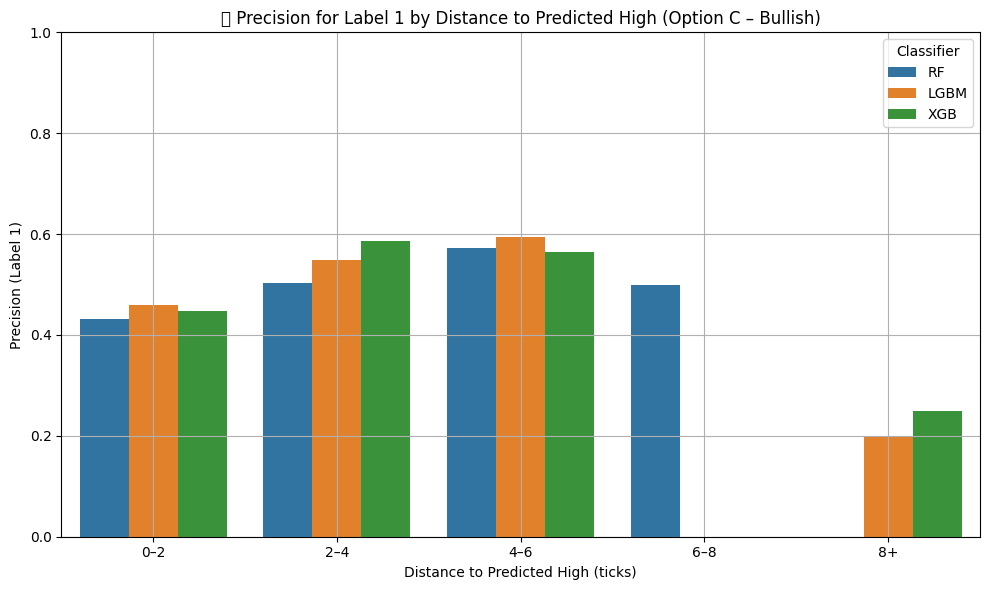

,Bin,Model,Precision_1,Count
0,0–2,RF,0.431655,745
1,2–4,RF,0.502488,366
2,4–6,RF,0.571429,68
3,6–8,RF,0.500000,6
4,8+,RF,0.000000,12
5,0–2,LGBM,0.460227,745
6,2–4,LGBM,0.548387,366
7,4–6,LGBM,0.593750,68
8,6–8,LGBM,0.000000,6
9,8+,LGBM,0.200000,12


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score

# ✅ Use Bullish variant from Option C
df_test_bullish_c = X_test_bullish_goal_c.copy()
df_test_bullish_c["Close"] = trainer_c.x_test_with_meta.loc[X_test_bullish_goal_c.index]["Close"]
df_test_bullish_c["Predicted_High"] = trainer_c.x_test_with_meta.loc[X_test_bullish_goal_c.index]["Predicted_High"]
df_test_bullish_c["distance"] = df_test_bullish_c["Predicted_High"] - df_test_bullish_c["Close"]

# ✅ Add true labels and predictions
df_test_bullish_c["True_Label"] = y_test_bullish_goal_c.values
df_test_bullish_c["Pred_RF"] = classifier_trainer_bullish_goal_c.rf_results["predictions"]
df_test_bullish_c["Pred_LGBM"] = classifier_trainer_bullish_goal_c.lgbm_results["predictions"]
df_test_bullish_c["Pred_XGB"] = classifier_trainer_bullish_goal_c.xgb_results["predictions"]

# ✅ Define distance bins
bins = [-float("inf"), 0, 2, 4, 6, 8, float("inf")]
labels = ["<0", "0–2", "2–4", "4–6", "6–8", "8+"]
df_test_bullish_c["distance_bin"] = pd.cut(df_test_bullish_c["distance"], bins=bins, labels=labels)

# ✅ Calculate precision per bin per classifier
results = []
for model in ["Pred_RF", "Pred_LGBM", "Pred_XGB"]:
    for bin_label in labels:
        bin_data = df_test_bullish_c[df_test_bullish_c["distance_bin"] == bin_label]
        if not bin_data.empty:
            y_true = bin_data["True_Label"]
            y_pred = bin_data[model]
            prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
            results.append({
                "Bin": bin_label,
                "Model": model.replace("Pred_", ""),
                "Precision_1": prec,
                "Count": len(bin_data)
            })

df_precision_by_distance_c = pd.DataFrame(results)

# ✅ Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_precision_by_distance_c, x="Bin", y="Precision_1", hue="Model")
plt.title("📈 Precision for Label 1 by Distance to Predicted High (Option C – Bullish)")
plt.ylabel("Precision (Label 1)")
plt.xlabel("Distance to Predicted High (ticks)")
plt.ylim(0, 1)
plt.grid(True)
plt.legend(title="Classifier")
plt.tight_layout()
plt.show()

# ✅ Optional: view table
df_precision_by_distance_c


🎯 Cross-Validated Precision by Distance Bin Analysis – Option C (Bullish)

📊 Distance Bin Distribution:
  <0: 0 samples (0.0%)
  0–2: 745 samples (62.2%)
  2–4: 366 samples (30.6%)
  4–6: 68 samples (5.7%)
  6–8: 6 samples (0.5%)
  8+: 12 samples (1.0%)

🔁 Running cross-validation by distance bin...
  ⚠️ Skipping bin <0 - insufficient samples (0)
  Processing bin 0–2 (745 samples)
    RF - Precision: 0.392 (from 745 cross-validated samples)
    LGBM - Precision: 0.434 (from 745 cross-validated samples)
    XGB - Precision: 0.467 (from 745 cross-validated samples)
  Processing bin 2–4 (366 samples)
    RF - Precision: 0.431 (from 366 cross-validated samples)
    LGBM - Precision: 0.474 (from 366 cross-validated samples)
    XGB - Precision: 0.456 (from 366 cross-validated samples)
  Processing bin 4–6 (68 samples)
    RF - Precision: 0.345 (from 68 cross-validated samples)
    LGBM - Precision: 0.300 (from 68 cross-validated samples)
    XGB - Precision: 0.367 (from 68 cross-validated s

C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\1475916418.py:111: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


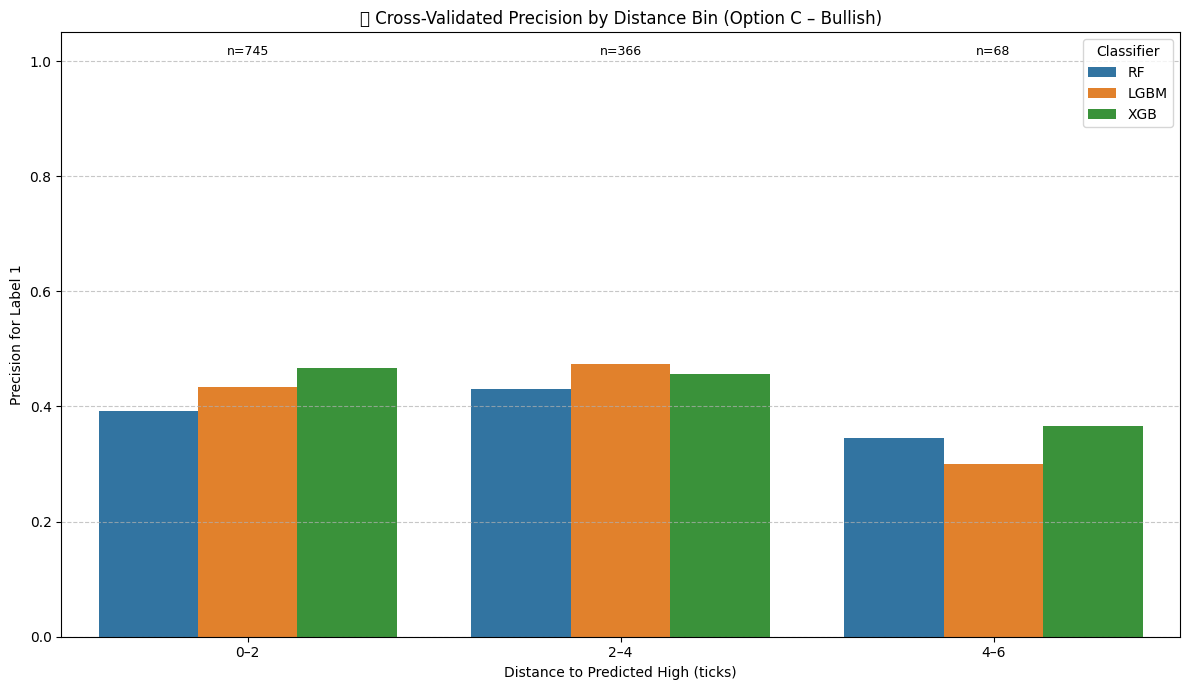


📋 Cross-Validated Precision (Label 1) by Distance Bin:


Model,LGBM,RF,XGB,Sample_Count
Bin,,,,
0–2,0.434,0.392,0.467,745
2–4,0.474,0.431,0.456,366
4–6,0.300,0.345,0.367,68


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import precision_score
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

print("🎯 Cross-Validated Precision by Distance Bin Analysis – Option C (Bullish)\n")

# Combine train and test sets
X_bullish_c = pd.concat([X_train_bullish_goal_c, X_test_bullish_goal_c])
y_bullish_c = pd.concat([y_train_bullish_goal_c, y_test_bullish_goal_c])

# Get indices and filtered meta
all_indices_c = X_bullish_c.index
filtered_meta_c = trainer_c.x_test_with_meta.loc[trainer_c.x_test_with_meta.index.isin(all_indices_c)]

# Rename and attach price data
meta_prices_c = filtered_meta_c[["Close", "Predicted_High"]].rename(columns={
    "Close": "Price_Close",
    "Predicted_High": "Price_Predicted_High"
})
df_bullish_cv_c = X_bullish_c.copy()
df_bullish_cv_c["True_Label"] = y_bullish_c.values
df_bullish_cv_c = df_bullish_cv_c.join(meta_prices_c, how="inner")

# Add distance and bin
df_bullish_cv_c["distance"] = df_bullish_cv_c["Price_Predicted_High"] - df_bullish_cv_c["Price_Close"]
bins = [-float("inf"), 0, 2, 4, 6, 8, float("inf")]
labels = ["<0", "0–2", "2–4", "4–6", "6–8", "8+"]
df_bullish_cv_c["distance_bin"] = pd.cut(df_bullish_cv_c["distance"], bins=bins, labels=labels)

# Bin distribution
print("📊 Distance Bin Distribution:")
bin_counts = df_bullish_cv_c["distance_bin"].value_counts().sort_index()
for bin_label, count in bin_counts.items():
    percent = count / len(df_bullish_cv_c) * 100
    print(f"  {bin_label}: {count} samples ({percent:.1f}%)")

# K-Fold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Models
models = {
    "RF": RandomForestClassifier(random_state=42),
    "LGBM": LGBMClassifier(random_state=42),
    "XGB": XGBClassifier(random_state=42, eval_metric='logloss')
}

# Cross-validation loop
cv_precision_by_bin_c = []
print("\n🔁 Running cross-validation by distance bin...")

for bin_label in labels:
    bin_data = df_bullish_cv_c[df_bullish_cv_c["distance_bin"] == bin_label]
    
    if len(bin_data) < 10:
        print(f"  ⚠️ Skipping bin {bin_label} - insufficient samples ({len(bin_data)})")
        continue
    
    print(f"  Processing bin {bin_label} ({len(bin_data)} samples)")
    X_bin = bin_data.drop(["True_Label", "distance", "distance_bin", "Price_Close", "Price_Predicted_High"], axis=1, errors='ignore')
    y_bin = bin_data["True_Label"]
    
    for model_name, model in models.items():
        all_true, all_pred = [], []
        
        for train_idx, test_idx in kf.split(X_bin):
            if len(np.unique(y_bin.iloc[train_idx])) < 2 or len(np.unique(y_bin.iloc[test_idx])) < 2:
                continue
            X_train_fold, X_test_fold = X_bin.iloc[train_idx], X_bin.iloc[test_idx]
            y_train_fold, y_test_fold = y_bin.iloc[train_idx], y_bin.iloc[test_idx]
            
            model.fit(X_train_fold, y_train_fold)
            y_pred_fold = model.predict(X_test_fold)
            
            all_true.extend(y_test_fold)
            all_pred.extend(y_pred_fold)
        
        if len(all_true) > 0 and 1 in all_true:
            prec = precision_score(all_true, all_pred, pos_label=1, zero_division=0)
            cv_precision_by_bin_c.append({
                "Bin": bin_label,
                "Model": model_name,
                "Precision_1": prec,
                "Count": len(bin_data)
            })
            print(f"    {model_name} - Precision: {prec:.3f} (from {len(all_true)} cross-validated samples)")

# DataFrame and Plot
df_cv_precision_by_distance_c = pd.DataFrame(cv_precision_by_bin_c)

if not df_cv_precision_by_distance_c.empty:
    plt.figure(figsize=(12, 7))
    sns.barplot(data=df_cv_precision_by_distance_c, x="Bin", y="Precision_1", hue="Model")
    
    for bin_label in df_cv_precision_by_distance_c["Bin"].unique():
        bin_count = df_cv_precision_by_distance_c[df_cv_precision_by_distance_c["Bin"] == bin_label]["Count"].iloc[0]
        bin_index = list(df_cv_precision_by_distance_c["Bin"].unique()).index(bin_label)
        plt.text(bin_index, 1.01, f"n={bin_count}", ha='center', fontsize=9)
    
    plt.title("📊 Cross-Validated Precision by Distance Bin (Option C – Bullish)")
    plt.ylabel("Precision for Label 1")
    plt.xlabel("Distance to Predicted High (ticks)")
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Classifier")
    plt.tight_layout()
    plt.show()

    # 📋 Optional pivot table
    pivot_df = df_cv_precision_by_distance_c.pivot(index="Bin", columns="Model", values="Precision_1")
    pivot_df["Sample_Count"] = df_cv_precision_by_distance_c.drop_duplicates("Bin").set_index("Bin")["Count"]
    
    bin_order = {label: i for i, label in enumerate(labels)}
    pivot_df = pivot_df.reset_index()
    pivot_df["bin_order"] = pivot_df["Bin"].map(bin_order)
    pivot_df = pivot_df.sort_values("bin_order").drop("bin_order", axis=1).set_index("Bin")
    
    print("\n📋 Cross-Validated Precision (Label 1) by Distance Bin:")
    display(pivot_df.style.format("{:.3f}", subset=["RF", "LGBM", "XGB"]))
else:
    print("\n⚠️ No results to display - check if bins have sufficient samples")


# option D Simple red bar green bar prediction

In [56]:
import importlib
import label_generator  # Adjust path if needed
importlib.reload(label_generator)

from label_generator import LabelGenerator


In [57]:
# ✅ Option D: Labeling Green Bars (Close > Open)
df_for_labeling_d = trainer.x_test_with_meta.copy()
label_gen = LabelGenerator()
# ✅ Apply Option D labels
df_labeled_all_d = label_gen.green_red_bar_label_goal_d(df_for_labeling_d)


✅ Goal D Label applied (1 = green bar) TEST.


In [58]:
from imblearn.over_sampling import SMOTE

processor = DataProcessor()
trainer_d = trainer.copy()  # ✅ Dedicated copy for Option D

# 🔵 All-bar version (Goal D)
X_train_all_goal_d, y_train_all_goal_d, X_test_all_goal_d, y_test_all_goal_d = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_all_d,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

# ✅ Balance the training set
smote_all_goal_d = SMOTE(random_state=42)
classifier_X_train_bal_all_goal_d, classifier_y_train_bal_all_goal_d = smote_all_goal_d.fit_resample(
    X_train_all_goal_d, y_train_all_goal_d
)

# ✅ Store metadata for alignment
trainer_d.x_test_with_meta = df_labeled_all_d.loc[X_test_all_goal_d.index]

# ✅ Keep only numeric columns
X_test_all_goal_d = X_test_all_goal_d.select_dtypes(include='number')

print("🧪 Notebook Alignment Check – Option D")
print("trainer_d.x_test_with_meta index:", trainer_d.x_test_with_meta.index[:5])
print("X_test_all_goal_d index:", X_test_all_goal_d.index[:5])
print("⏳ Are they equal?", trainer_d.x_test_with_meta.index.equals(X_test_all_goal_d.index))

# ✅ Train classifiers (All Bars – Goal D)
classifier_trainer_all_goal_d = ClassifierModelTrainer()
classifier_trainer_all_goal_d.train_all_classifiers(
    classifier_X_train_bal_all_goal_d,
    classifier_y_train_bal_all_goal_d,
    X_test_all_goal_d,
    y_test_all_goal_d,
    trainer_d
)

print("✅ Training complete using Goal D (Green Bar Classifier)")



✅ Sample Data Alignment Check:
   Sample Target (y_test) Corresponding Feature Row
0                       0       2025-01-15 12:00:00
1                       0       2025-01-15 12:05:00
2                       0       2025-01-15 12:10:00
3                       0       2025-01-15 12:15:00
4                       1       2025-01-15 12:20:00
🧪 Notebook Alignment Check – Option D
trainer_d.x_test_with_meta index: DatetimeIndex(['2025-01-15 12:00:00', '2025-01-15 12:05:00',
               '2025-01-15 12:10:00', '2025-01-15 12:15:00',
               '2025-01-15 12:20:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)
X_test_all_goal_d index: DatetimeIndex(['2025-01-15 12:00:00', '2025-01-15 12:05:00',
               '2025-01-15 12:10:00', '2025-01-15 12:15:00',
               '2025-01-15 12:20:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)
⏳ Are they equal? True
✅ ClassifierModelTrainer initialized!

🚀 Training all classifiers...

🚀 Training

Index(['Volume', 'FastAvg', 'SlowAvg', 'FastEMA', 'MedEMA', 'SlowEMA', 'ADX',
       'DMI_plus', 'DMI_minus', 'AroonUp',
       ...
       'Williams_R', 'Relative_Volume', 'Open', 'High', 'Low', 'Close',
       'Predicted_High', 'Prev_Predicted_High', 'Next_Close', 'Next_Open'],
      dtype='object', length=119)

# Option D with 15 Mins Bars


In [60]:
# ✅ Load CSV
loader = DataLoader()
training_df_raw_15_min = loader.load_from_csv("data/training/mes_2_new_15_mins.csv")  # change filename accordingly

# ✅ Drop any duplicate timestamps
training_df_raw_15_min = training_df_raw.drop_duplicates(subset=["Date", "Time"])

training_df_raw_15_min.head()


Data successfully loaded from data/training/mes_2_new_15_mins.csv


,Open,High,Low,Close,Volume,Date,Time
0,5771.00,5771.00,5769.00,5769.50,0,08/19/2024,4:05
1,5769.50,5770.50,5768.25,5769.50,0,08/19/2024,4:10
2,5769.75,5771.50,5769.75,5770.75,0,08/19/2024,4:15
3,5770.75,5770.75,5768.50,5769.75,0,08/19/2024,4:20
4,5770.00,5771.00,5768.75,5769.75,0,08/19/2024,4:25


In [61]:
feature_generator_15_mins = FeatureGenerator()
training_df_features_15_mins = feature_generator_15_mins.create_all_features(training_df_raw_15_min)

training_df_features_15_mins.head()


✅ FeatureGenerator initialized!
🚀 Starting full feature generation pipeline...
✅ Successfully calculated all technical indicators with correct column names!
✅ VWAP added successfully!
✅ Fibonacci levels added successfully! (Length=50, Retrace=0.382)
🔹 Computing CCI with length=14...
✅ Successfully computed CCI and CCI_Avg (CCI: 14, CCI_Avg: 9)
✅ Ichimoku Cloud indicators added successfully!
✅ Successfully computed ATR and added ATR-adjusted price features!
✅ Added EMAs (5-50) and their Distances (Close/Open) Successfully!
✅ Successfully added High-Based Indicators (Unified Method)!
✅ Added constant columns: ['OverBot', 'OverSld', 'OverBought', 'OverSold', 'Zero Cross', 'CROSS FIB.1', 'CROSS FIB.2']
✅ Successfully added MACD indicators!
✅ Successfully added volatility, Williams %R, and Relative Volume features!
✅ Feature generation complete! Final DataFrame: 117 columns


,Open,High,Low,Close,Volume,Date,Time,FastAvg,SlowAvg,FastEMA,...,OverBought,OverSold,Zero Cross,CROSS FIB.1,CROSS FIB.2,MACD,MACDAvg,MACDDiff,Williams_R,Relative_Volume
0,5771.00,5771.00,5769.00,5769.50,0,08/19/2024,4:05,NaN,NaN,5769.50,...,70,30,0,0,0,0.000000,0.000000,0.000000,NaN,NaN
1,5769.50,5770.50,5768.25,5769.50,0,08/19/2024,4:10,NaN,NaN,5769.50,...,70,30,0,0,0,0.000000,0.000000,0.000000,NaN,NaN
2,5769.75,5771.50,5769.75,5770.75,0,08/19/2024,4:15,NaN,NaN,5769.75,...,70,30,0,0,0,0.099715,0.019943,0.079772,NaN,NaN
3,5770.75,5770.75,5768.50,5769.75,0,08/19/2024,4:20,NaN,NaN,5769.75,...,70,30,0,0,0,0.096931,0.035341,0.061590,NaN,NaN
4,5770.00,5771.00,5768.75,5769.75,0,08/19/2024,4:25,NaN,NaN,5769.75,...,70,30,0,0,0,0.093645,0.047002,0.046644,NaN,NaN


In [64]:
# ✅ Option D: Labeling Green Bars (Close > Open)
label_gen = LabelGenerator()
# ✅ Apply Option D labels
df_labeled_all_d_15_mins = label_gen.green_red_bar_label_goal_d(training_df_features_15_mins)


✅ Goal D Label applied (1 = green bar) TEST.


In [65]:

# label_col = "long_good_bar_label"  # still the same for Option C


# df_labeled_all_d_15_mins["Prev_Label"] = df_labeled_all_d_15_mins[label_col].shift(1)


# # Drop rows with NaN in Prev_Label after shift
# df_labeled_all_d_15_mins = df_labeled_all_d_15_mins.dropna(subset=["Prev_Label"])

# # Convert Prev_Label to integer
# df_labeled_all_d_15_mins["Prev_Label"] = df_labeled_all_d_15_mins["Prev_Label"].astype(int)

# print("✅ Previous signal features added to both Option  D 15 mins labeled DataFrames.")

✅ Previous signal features added to both Option  D 15 mins labeled DataFrames.


In [66]:
from imblearn.over_sampling import SMOTE

# ✅ Setup Processor and Trainer
processor = DataProcessor()
trainer_d_15m = trainer.copy()  # ✅ Clone to keep clean trainer state

# ✅ Prepare dataset (using Option D labels)
X_train_d_15m, y_train_d_15m, X_test_d_15m, y_test_d_15m = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_all_d_15_mins,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

# ✅ Apply SMOTE to training data
smote_d_15m = SMOTE(random_state=42)
classifier_X_train_bal_d_15m, classifier_y_train_bal_d_15m = smote_d_15m.fit_resample(X_train_d_15m, y_train_d_15m)

# ✅ Store meta info for visualization
trainer_d_15m.x_test_with_meta = df_labeled_all_d_15_mins.loc[X_test_d_15m.index]

# ✅ Remove non-numeric columns from test set
X_test_d_15m = X_test_d_15m.select_dtypes(include='number')

# ✅ Sanity Check
print("🧪 Alignment Check – 15-Min Green/Red")
print("trainer_d_15m.x_test_with_meta index:", trainer_d_15m.x_test_with_meta.index[:5])
print("X_test_d_15m index:", X_test_d_15m.index[:5])
print("⏳ Are they equal?", trainer_d_15m.x_test_with_meta.index.equals(X_test_d_15m.index))

# ✅ Train classifiers
classifier_trainer_d_15m = ClassifierModelTrainer()
classifier_trainer_d_15m.train_all_classifiers(
    classifier_X_train_bal_d_15m,
    classifier_y_train_bal_d_15m,
    X_test_d_15m,
    y_test_d_15m,
    trainer_d_15m
)

print("✅ Training complete for Goal D (Green Bar Classifier – 15 Min Bars)")



✅ Sample Data Alignment Check:
   Sample Target (y_test)  Corresponding Feature Row
0                       1                      24000
1                       0                      24001
2                       0                      24002
3                       1                      24003
4                       0                      24004
🧪 Alignment Check – 15-Min Green/Red
trainer_d_15m.x_test_with_meta index: Index([24000, 24001, 24002, 24003, 24004], dtype='int64')
X_test_d_15m index: Index([24000, 24001, 24002, 24003, 24004], dtype='int64')
⏳ Are they equal? True
✅ ClassifierModelTrainer initialized!

🚀 Training all classifiers...

🚀 Training RandomForest...

📊 RandomForest Evaluation:
              precision    recall  f1-score   support

           0       0.56      0.23      0.33      3089
           1       0.50      0.81      0.62      2911

    accuracy                           0.51      6000
   macro avg       0.53      0.52      0.47      6000
weighted avg       

# Trying Multi class classification for red green bars 5+15

Analyzing 5-minute data (df_for_labeling_c):


C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\3952900354.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['movement_category'] = pd.cut(
C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\3952900354.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_percents, palette=colors, ax=axes[1])
C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\3952900354.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45

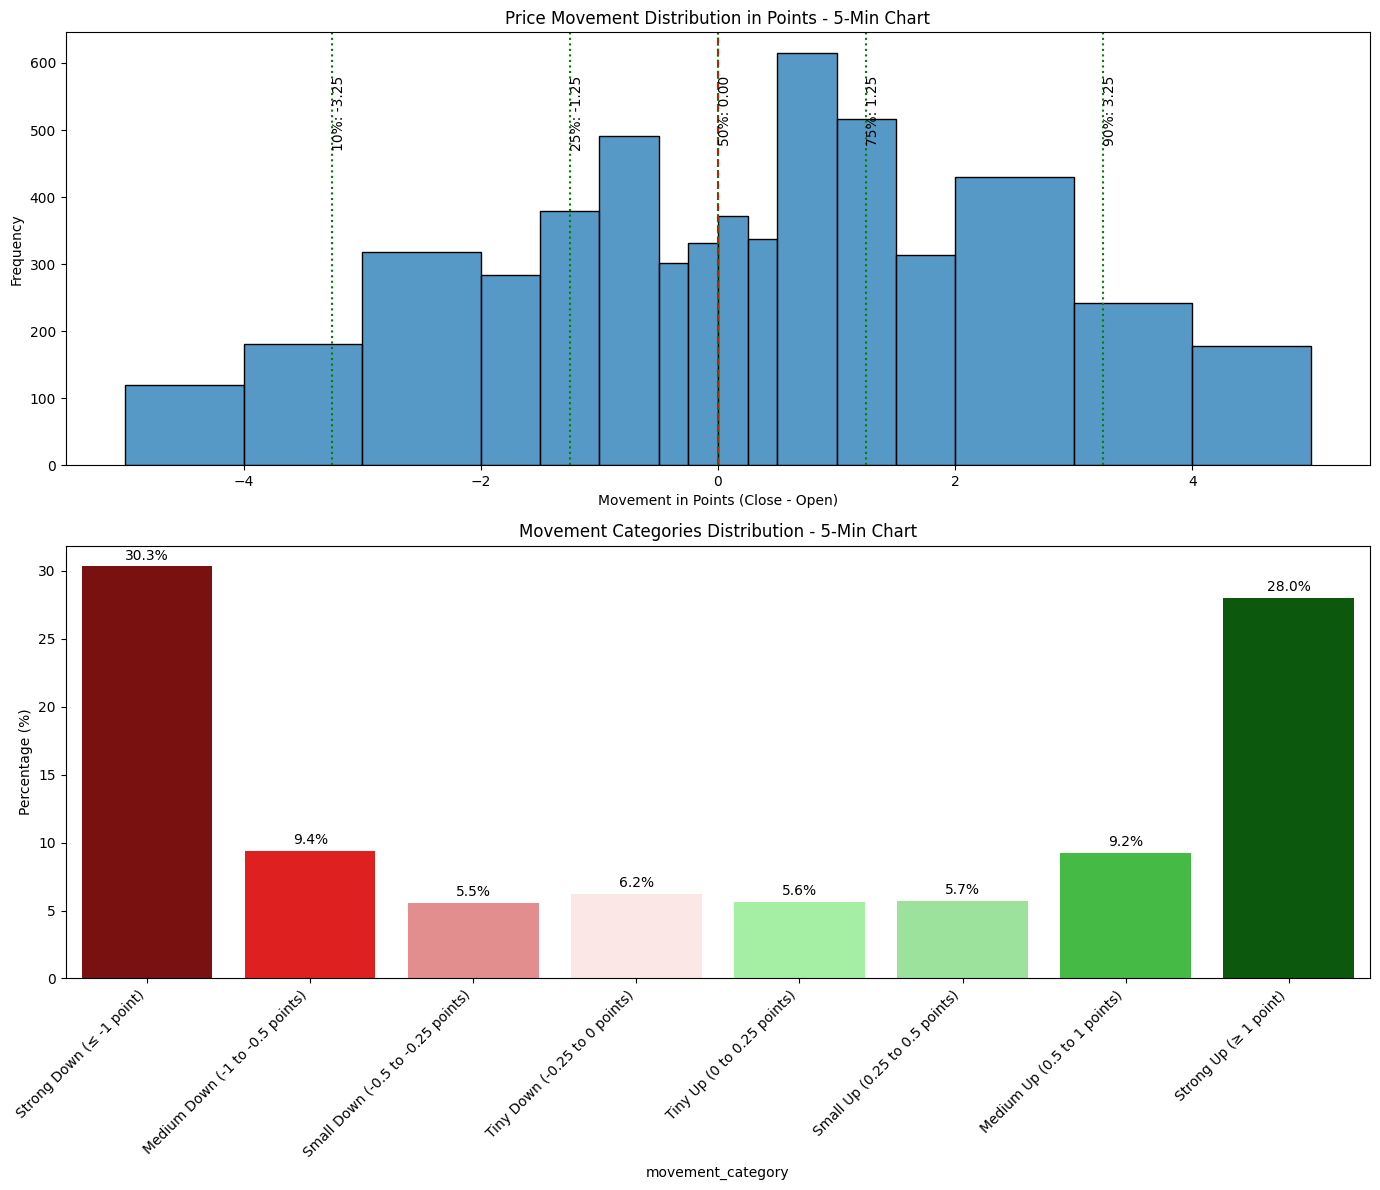


📊 Bar Movement Statistics for 5-Min Chart (in points):
Mean movement: -0.02 points
Median movement: 0.00 points
Max up move: 58.75 points
Max down move: -51.50 points

Percentile values (potential class boundaries):
10th percentile: -3.25 points
25th percentile: -1.25 points
50th percentile: 0.00 points
75th percentile: 1.25 points
90th percentile: 3.25 points

Basic bar type distribution:
Green bars: 48.5%
Red bars: 45.3%
Neutral bars: 6.2%

Analyzing 15-minute data (training_df_features_15_mins):


C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\3952900354.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['movement_category'] = pd.cut(
C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\3952900354.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_percents, palette=colors, ax=axes[1])
C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\3952900354.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45

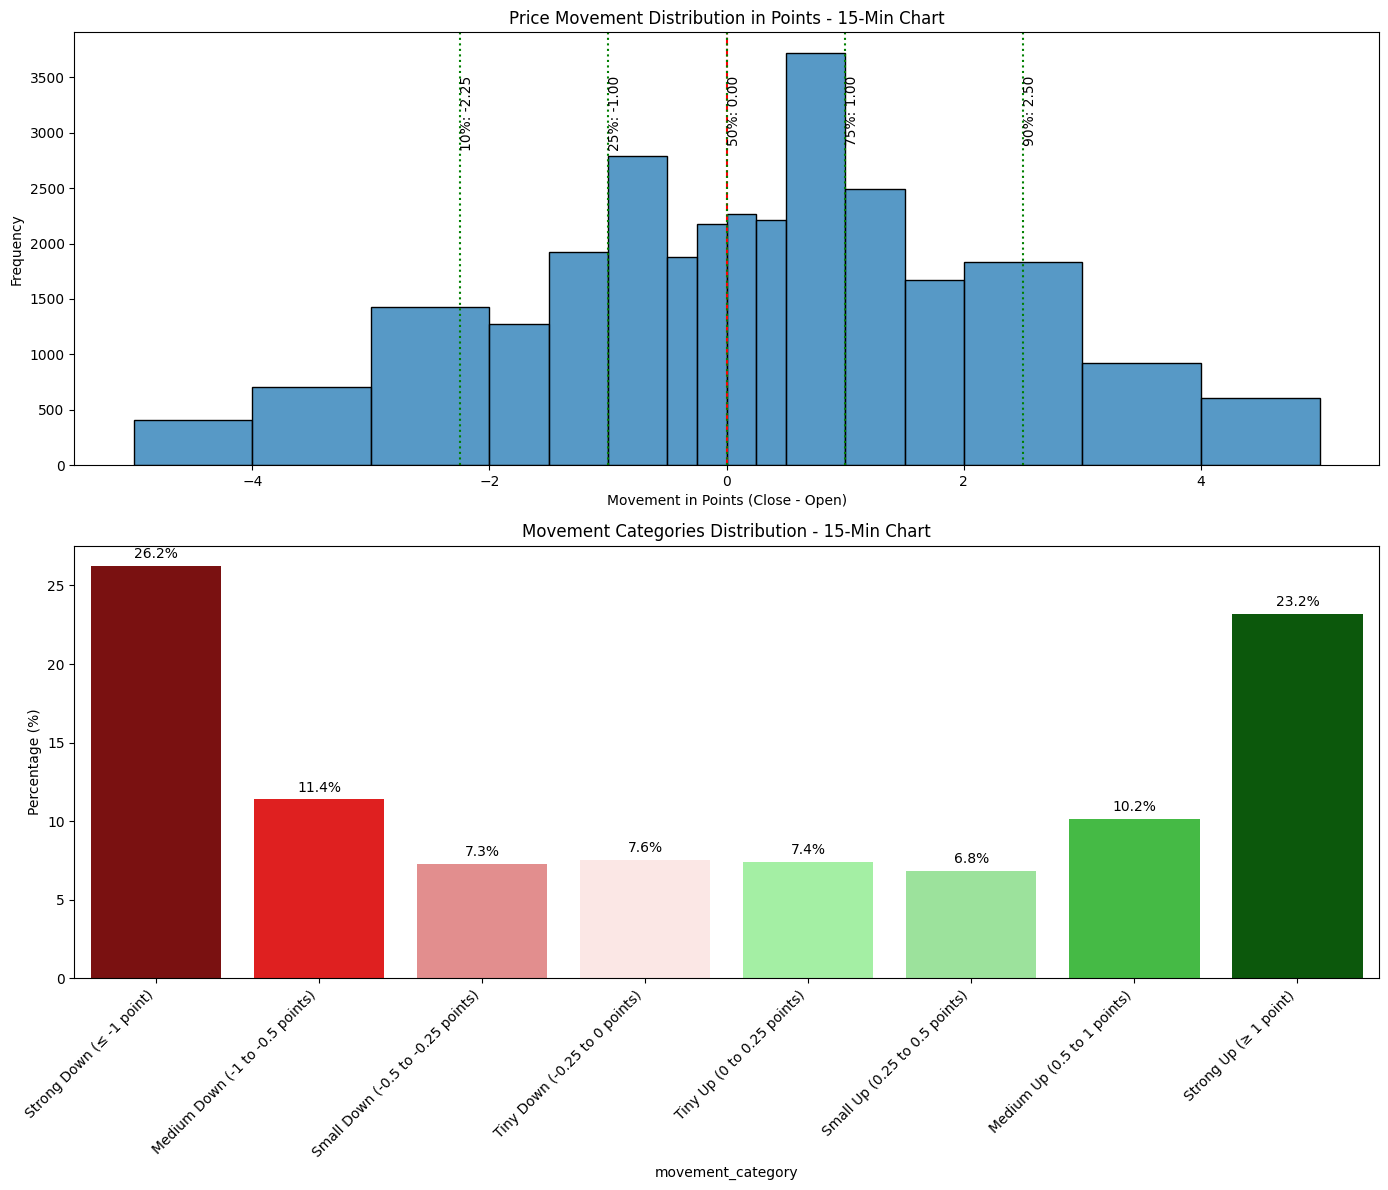


📊 Bar Movement Statistics for 15-Min Chart (in points):
Mean movement: 0.01 points
Median movement: 0.00 points
Max up move: 58.75 points
Max down move: -51.50 points

Percentile values (potential class boundaries):
10th percentile: -2.25 points
25th percentile: -1.00 points
50th percentile: 0.00 points
75th percentile: 1.00 points
90th percentile: 2.50 points

Basic bar type distribution:
Green bars: 47.6%
Red bars: 44.9%
Neutral bars: 7.6%


In [68]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

def analyze_bar_movement(df, title):
    # Calculate price movement (Close - Open) in points
    df['movement'] = df['Close'] - df['Open']
    
    # Calculate next bar movement for our multiclass prediction target
    df['next_bar_movement'] = df['movement'].shift(-1)
    df_clean = df.dropna(subset=['next_bar_movement'])
    
    # Define point ranges for histogram bins
    point_ranges = [-5, -4, -3, -2, -1.5, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 1.5, 2, 3, 4, 5]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 1, figsize=(14, 12))
    
    # Plot 1: Histogram with precise bins
    sns.histplot(df_clean['next_bar_movement'], bins=point_ranges, kde=False, ax=axes[0])
    axes[0].set_title(f'Price Movement Distribution in Points - {title}')
    axes[0].axvline(x=0, color='red', linestyle='--')
    axes[0].set_xlabel('Movement in Points (Close - Open)')
    axes[0].set_ylabel('Frequency')
    
    # Add percentile lines
    percentiles = [10, 25, 50, 75, 90]
    perc_values = np.percentile(df_clean['next_bar_movement'], percentiles)
    
    for p, pv in zip(percentiles, perc_values):
        axes[0].axvline(x=pv, color='green', linestyle=':')
        axes[0].text(pv, axes[0].get_ylim()[1]*0.9, f'{p}%: {pv:.2f}', 
                  rotation=90, verticalalignment='top')
    
    # Plot 2: Bar chart of movement categories
    # Create categories for clearer visualization
    movement_bins = [
        (-float('inf'), -1, "Strong Down (≤ -1 point)"),
        (-1, -0.5, "Medium Down (-1 to -0.5 points)"),
        (-0.5, -0.25, "Small Down (-0.5 to -0.25 points)"),
        (-0.25, 0, "Tiny Down (-0.25 to 0 points)"),
        (0, 0.25, "Tiny Up (0 to 0.25 points)"),
        (0.25, 0.5, "Small Up (0.25 to 0.5 points)"),
        (0.5, 1, "Medium Up (0.5 to 1 points)"),
        (1, float('inf'), "Strong Up (≥ 1 point)")
    ]
    
    # Categorize movements
    df_clean['movement_category'] = pd.cut(
        df_clean['next_bar_movement'],
        bins=[b[0] for b in movement_bins] + [float('inf')],
        labels=[b[2] for b in movement_bins]
    )
    
    # Count and plot
    category_counts = df_clean['movement_category'].value_counts().sort_index()
    category_percents = (category_counts / len(df_clean) * 100)
    
    colors = ['darkred', 'red', 'lightcoral', 'mistyrose', 
             'palegreen', 'lightgreen', 'limegreen', 'darkgreen']
    
    sns.barplot(x=category_counts.index, y=category_percents, palette=colors, ax=axes[1])
    axes[1].set_title(f'Movement Categories Distribution - {title}')
    axes[1].set_ylabel('Percentage (%)')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    
    # Add percentage labels on bars
    for i, p in enumerate(category_percents):
        axes[1].text(i, p + 0.5, f'{p:.1f}%', ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics in points
    print(f"\n📊 Bar Movement Statistics for {title} (in points):")
    print(f"Mean movement: {df_clean['next_bar_movement'].mean():.2f} points")
    print(f"Median movement: {df_clean['next_bar_movement'].median():.2f} points")
    print(f"Max up move: {df_clean['next_bar_movement'].max():.2f} points")
    print(f"Max down move: {df_clean['next_bar_movement'].min():.2f} points")
    
    print("\nPercentile values (potential class boundaries):")
    for p, pv in zip(percentiles, perc_values):
        print(f"{p}th percentile: {pv:.2f} points")
    
    # Count green vs red bars
    green_pct = (df_clean['next_bar_movement'] > 0).mean() * 100
    red_pct = (df_clean['next_bar_movement'] < 0).mean() * 100
    neutral_pct = (df_clean['next_bar_movement'] == 0).mean() * 100
    
    print(f"\nBasic bar type distribution:")
    print(f"Green bars: {green_pct:.1f}%")
    print(f"Red bars: {red_pct:.1f}%")
    print(f"Neutral bars: {neutral_pct:.1f}%")
    
    # Return clean dataframe for further analysis
    return df_clean

# Analyze both datasets
print("Analyzing 5-minute data (df_for_labeling_c):")
df_5min_clean = analyze_bar_movement(df_for_labeling_c, "5-Min Chart")

print("\nAnalyzing 15-minute data (training_df_features_15_mins):")
df_15min_clean = analyze_bar_movement(training_df_features_15_mins, "15-Min Chart")

## reload !!

In [75]:
import importlib

# ✅ Reload label generator module
import label_generator  # Adjust if using subfolders like backend.label_generator
importlib.reload(label_generator)
from label_generator import LabelGenerator

# ✅ Reload classifier trainer module (adjust path as needed)
import classifier_model_trainer
importlib.reload(classifier_model_trainer)
from classifier_model_trainer import ClassifierModelTrainer


In [76]:
# ✅ Create copies for multi-class labeling (Option D)
df_labeled_all_d_5_mins = df_for_labeling_c.copy()
df_labeled_all_d_15_mins = training_df_features_15_mins.copy()

# ✅ Apply Option D multi-class label
labeler = LabelGenerator()
df_labeled_all_d_5_mins = labeler.option_d_multiclass_next_bar_movement(df_labeled_all_d_5_mins)
df_labeled_all_d_15_mins = labeler.option_d_multiclass_next_bar_movement(df_labeled_all_d_15_mins)


✅ Option D Multi-Class Labels applied (based on next bar movement).
✅ Option D Multi-Class Labels applied (based on next bar movement).


In [77]:
from imblearn.over_sampling import SMOTE

# ✅ Setup Processor and Trainers
processor = DataProcessor()
trainer_d_5m = trainer.copy()
trainer_d_15m = trainer.copy()

# ✅ Split 5-min
X_train_d_5m, y_train_d_5m, X_test_d_5m, y_test_d_5m = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_all_d_5_mins,
    target_column="multi_class_label",
    drop_target=True,
    split_ratio=0.8
)

# ✅ Split 15-min
X_train_d_15m, y_train_d_15m, X_test_d_15m, y_test_d_15m = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_all_d_15_mins,
    target_column="multi_class_label",
    drop_target=True,
    split_ratio=0.8
)

# ✅ Apply SMOTE
smote_d_5m = SMOTE(random_state=42)
classifier_X_train_bal_d_5m, classifier_y_train_bal_d_5m = smote_d_5m.fit_resample(X_train_d_5m, y_train_d_5m)

smote_d_15m = SMOTE(random_state=42)
classifier_X_train_bal_d_15m, classifier_y_train_bal_d_15m = smote_d_15m.fit_resample(X_train_d_15m, y_train_d_15m)

# ✅ Meta info for test sets
trainer_d_5m.x_test_with_meta = df_labeled_all_d_5_mins.loc[X_test_d_5m.index]
trainer_d_15m.x_test_with_meta = df_labeled_all_d_15_mins.loc[X_test_d_15m.index]

# ✅ Remove non-numeric cols from test
X_test_d_5m = X_test_d_5m.select_dtypes(include='number')
X_test_d_15m = X_test_d_15m.select_dtypes(include='number')

# ✅ Sanity check
print("🧪 Alignment Check – 5 Min")
print("Indexes equal?", trainer_d_5m.x_test_with_meta.index.equals(X_test_d_5m.index))
print("🧪 Alignment Check – 15 Min")
print("Indexes equal?", trainer_d_15m.x_test_with_meta.index.equals(X_test_d_15m.index))

# ✅ Train classifiers

classifier_trainer_d_5m = ClassifierModelTrainer()
classifier_trainer_d_5m.xgboost_num_classes = 5  # 👈 Enable multi-class mode


classifier_trainer_d_15m = ClassifierModelTrainer()
classifier_trainer_d_15m.xgboost_num_classes = 5  # 👈 Enable multi-class mode



classifier_trainer_d_5m.train_all_classifiers(
    classifier_X_train_bal_d_5m,
    classifier_y_train_bal_d_5m,
    X_test_d_5m,
    y_test_d_5m,
    trainer_d_5m
)

classifier_trainer_d_15m.train_all_classifiers(
    classifier_X_train_bal_d_15m,
    classifier_y_train_bal_d_15m,
    X_test_d_15m,
    y_test_d_15m,
    trainer_d_15m
)

print("✅ Training complete for Option D Multi-Class (5-min + 15-min)")



✅ Sample Data Alignment Check:
   Sample Target (y_test) Corresponding Feature Row
0                       2       2025-01-15 12:00:00
1                       1       2025-01-15 12:05:00
2                       2       2025-01-15 12:10:00
3                       1       2025-01-15 12:15:00
4                       3       2025-01-15 12:20:00

✅ Sample Data Alignment Check:
   Sample Target (y_test)  Corresponding Feature Row
0                       3                      24000
1                       2                      24001
2                       1                      24002
3                       2                      24003
4                       1                      24004
🧪 Alignment Check – 5 Min
Indexes equal? True
🧪 Alignment Check – 15 Min
Indexes equal? True
✅ ClassifierModelTrainer initialized!
✅ ClassifierModelTrainer initialized!

🚀 Training all classifiers...

🚀 Training RandomForest...

📊 RandomForest Evaluation:
              precision    recall  f1-score   supp

C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita


📊 XGBoost Evaluation:
              precision    recall  f1-score   support

         0.0       0.18      0.23      0.20       125
         1.0       0.25      0.07      0.10       227
         2.0       0.51      0.74      0.60       505
         3.0       0.12      0.07      0.09       194
         4.0       0.33      0.28      0.30       149

    accuracy                           0.40      1200
   macro avg       0.28      0.28      0.26      1200
weighted avg       0.34      0.40      0.35      1200


🎯 XGBoost Accuracy: 0.3950
✅ All classifier predictions stored successfully!

🚀 Training all classifiers...

🚀 Training RandomForest...

📊 RandomForest Evaluation:
              precision    recall  f1-score   support

         0.0       0.19      0.15      0.17       828
         1.0       0.18      0.04      0.07       992
         2.0       0.60      0.56      0.58      2499
         3.0       0.20      0.18      0.19       883
         4.0       0.26      0.64      0.37       79

C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita


📊 XGBoost Evaluation:
              precision    recall  f1-score   support

         0.0       0.25      0.15      0.19       828
         1.0       0.19      0.02      0.04       992
         2.0       0.54      0.75      0.63      2499
         3.0       0.20      0.07      0.10       883
         4.0       0.28      0.57      0.37       798

    accuracy                           0.42      6000
   macro avg       0.29      0.31      0.26      6000
weighted avg       0.36      0.42      0.36      6000


🎯 XGBoost Accuracy: 0.4217
✅ All classifier predictions stored successfully!
✅ Training complete for Option D Multi-Class (5-min + 15-min)


# 🔬 Feature Importance Exploration – Strategy Plan

We are now exploring **feature importance** and **feature analysis** as the next step to improve model quality and understand which features are driving predictions.

---

### 🎯 Goals

- **Goal C (Binary Classifier – 5-Minute Bars)**  
  Model: `classifier_trainer_all_goal_c`  
  > Predicts whether the **next bar's high** will reach the **current predicted high**.

- **Option D (Multi-Class Classifier – 15-Minute Bars)**  
  Model: `classifier_trainer_d_15m`  
  > Classifies the **strength of next bar's movement** into 5 classes (from big drop to big jump).

---

### 🔍 Why Feature Importance?

Analyzing feature importance helps us:

- 🧹 **Identify noisy or irrelevant features**
- 💡 **Highlight key signals** that drive model predictions
- 🛠️ **Inform new feature engineering ideas**  
  _Examples: momentum indicators, trend streaks, volatility signals_

---

This will support both **strategy refinement** and **classifier improvement** by helping us isolate which features are worth trusting and enhancing.


In [78]:
# ✅ Inspect current model input sizes and structure

def print_model_summary(trainer_obj, name):
    model = trainer_obj.rf_results["model"]
    n_features = model.n_features_in_
    feature_names = model.feature_names_in_ if hasattr(model, "feature_names_in_") else "N/A"
    
    print(f"📊 Summary for {name}")
    print(f"➡️  Number of input features: {n_features}")
    print(f"🧠  Feature names: {feature_names[:10]}..." if isinstance(feature_names, (list, np.ndarray)) else f"🧠  Feature names: {feature_names}")
    print("-" * 50)

print_model_summary(classifier_trainer_all_goal_c, "Goal C (5-min Binary Classifier)")
print_model_summary(classifier_trainer_d_15m, "Option D (15-min Multi-Class Classifier)")


📊 Summary for Goal C (5-min Binary Classifier)
➡️  Number of input features: 117
🧠  Feature names: ['Volume' 'FastAvg' 'SlowAvg' 'FastEMA' 'MedEMA' 'SlowEMA' 'ADX'
 'DMI_plus' 'DMI_minus' 'AroonUp']...
--------------------------------------------------
📊 Summary for Option D (15-min Multi-Class Classifier)
➡️  Number of input features: 116
🧠  Feature names: ['Open' 'High' 'Low' 'Close' 'Volume' 'FastAvg' 'SlowAvg' 'FastEMA'
 'MedEMA' 'SlowEMA']...
--------------------------------------------------


🔍 Top 20 Features for Goal C (Binary Classifier):
1. Volume: 0.0265
2. Relative_Volume: 0.0264
3. Williams_R: 0.0254
4. CCI_Avg: 0.0218
5. TR3: 0.0215
6. Close_vs_EMA_5: 0.0210
7. TR2: 0.0201
8. ADX: 0.0191
9. Close_vs_EMA_10: 0.0168
10. CCI: 0.0164
11. AroonDn: 0.0162
12. TR1: 0.0161
13. AroonUp: 0.0154
14. Open_vs_EMA_5: 0.0150
15. True_Range: 0.0150
16. ATR: 0.0149
17. Open_vs_EMA_10: 0.0141
18. DMI_minus: 0.0140
19. Next_High: 0.0139
20. High_vs_EMA_5_High: 0.0137


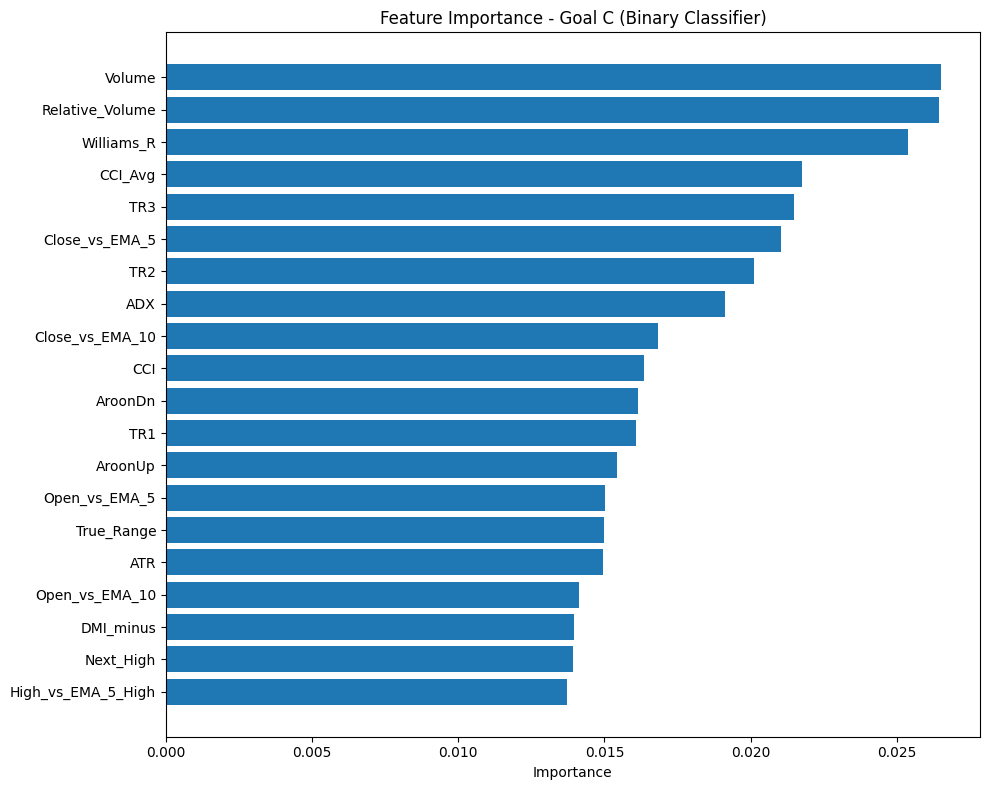

🔍 Top 20 Features for Option D (Multi-Class Classifier):
1. True_Range: 0.1164
2. TR1: 0.0970
3. ATR: 0.0944
4. TR2: 0.0543
5. TR3: 0.0510
6. Volume: 0.0455
7. AroonDn: 0.0165
8. AroonUp: 0.0152
9. movement: 0.0147
10. Relative_Volume: 0.0120
11. Close_vs_EMA_40: 0.0093
12. Open_vs_EMA_40: 0.0090
13. Close_vs_EMA_5: 0.0089
14. Open_vs_EMA_50: 0.0088
15. Open_vs_EMA_35: 0.0086
16. AroonOsc: 0.0085
17. Cum_PxV: 0.0083
18. Chikou: 0.0081
19. Open_vs_EMA_5: 0.0079
20. High_vs_EMA_30_High: 0.0079


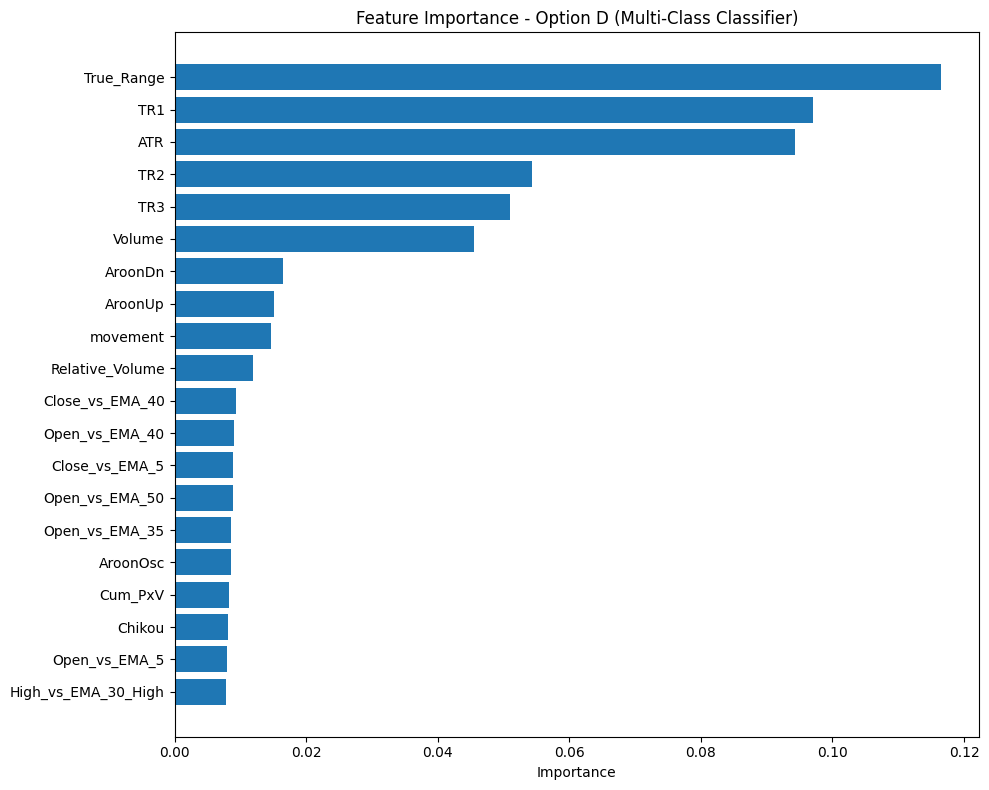

In [79]:
def analyze_feature_importance(trainer_obj, name, top_n=20, plot=True):
    """
    Analyze feature importance for a given classifier trainer object.
    
    Args:
        trainer_obj: The trainer object (classifier_trainer_all_goal_c or classifier_trainer_d_15m)
        name: String name for the model
        top_n: Number of top features to display
        plot: Whether to create visualization
    """
    model = trainer_obj.rf_results["model"]
    
    # Get feature names and importance scores
    feature_names = model.feature_names_in_ if hasattr(model, "feature_names_in_") else [f"Feature_{i}" for i in range(model.n_features_in_)]
    
    # Different models store importance differently
    if hasattr(model, "feature_importances_"):
        # For RandomForest, XGBoost, etc.
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        # For linear models
        importances = np.abs(model.coef_).mean(axis=0) if model.coef_.ndim > 1 else np.abs(model.coef_)
    else:
        print(f"Model doesn't have standard feature importance method")
        return None, None
    
    # Sort features by importance
    indices = np.argsort(importances)[::-1]
    sorted_names = [feature_names[i] for i in indices]
    sorted_importance = importances[indices]
    
    # Print top features
    print(f"🔍 Top {top_n} Features for {name}:")
    for i in range(min(top_n, len(sorted_names))):
        print(f"{i+1}. {sorted_names[i]}: {sorted_importance[i]:.4f}")
    
    # Create visualization
    if plot:
        plt.figure(figsize=(10, 8))
        plt.title(f"Feature Importance - {name}")
        plt.barh(range(min(top_n, len(sorted_names))), 
                 sorted_importance[:top_n], 
                 align='center')
        plt.yticks(range(min(top_n, len(sorted_names))), sorted_names[:top_n])
        plt.gca().invert_yaxis()  # Display highest importance at top
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.show()
        
    return sorted_names, sorted_importance

# Analyze both models
sorted_names_c, sorted_importance_c = analyze_feature_importance(
    classifier_trainer_all_goal_c, "Goal C (Binary Classifier)", top_n=20)

sorted_names_d, sorted_importance_d = analyze_feature_importance(
    classifier_trainer_d_15m, "Option D (Multi-Class Classifier)", top_n=20)

Calculating permutation importance for Goal C (Binary Classifier - All Bars)...
🔍 Top 15 Features by Permutation Importance for Goal C (Binary Classifier - All Bars):
1. SlowAvg: 0.0047 ± 0.0017
2. Prev_Label: 0.0038 ± 0.0072
3. High_Max_12: 0.0033 ± 0.0011
4. Open_vs_EMA_15: 0.0033 ± 0.0025
5. TR3: 0.0032 ± 0.0037
6. TR2: 0.0025 ± 0.0032
7. High_Daily: 0.0022 ± 0.0019
8. MACD: 0.0022 ± 0.0043
9. Close: 0.0020 ± 0.0015
10. True_Range: 0.0018 ± 0.0056
11. High_vs_EMA_25_High: 0.0017 ± 0.0036
12. SenkouSpan_A: 0.0013 ± 0.0017
13. ADX: 0.0013 ± 0.0029
14. EMA_25_High: 0.0013 ± 0.0011
15. Typical_Price: 0.0012 ± 0.0020


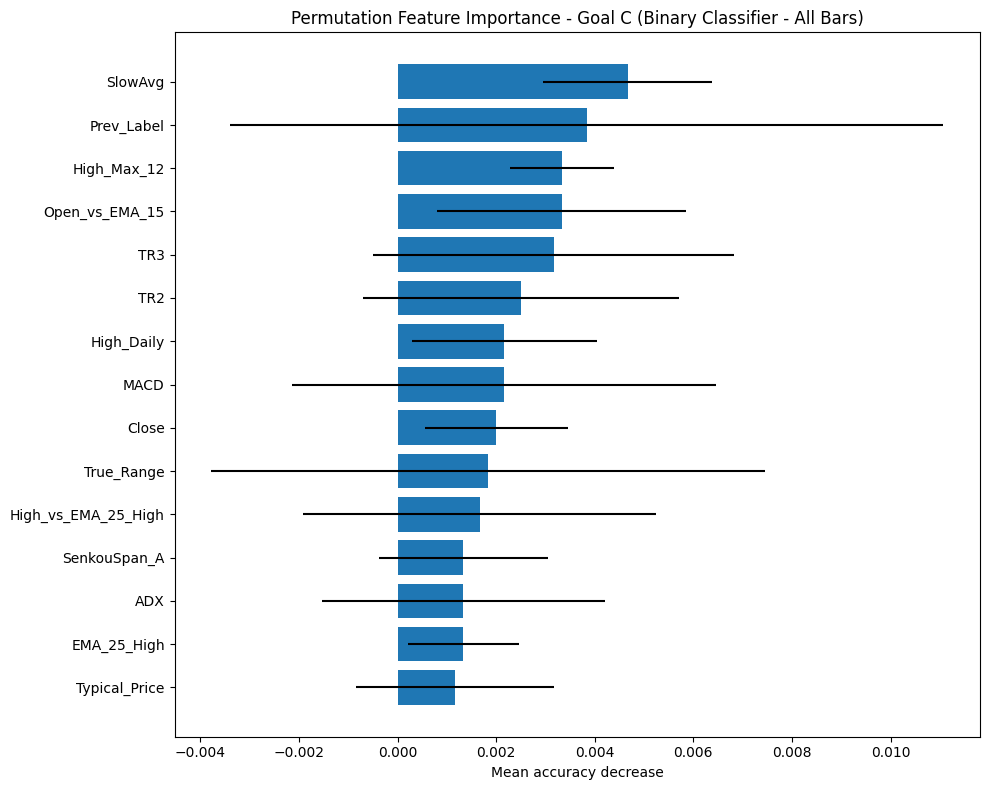

Calculating permutation importance for Option D (Multi-Class Classifier - 15 min)...
🔍 Top 15 Features by Permutation Importance for Option D (Multi-Class Classifier - 15 min):
1. True_Range: 0.0137 ± 0.0024
2. Volume: 0.0101 ± 0.0010
3. ATR: 0.0081 ± 0.0012
4. TR1: 0.0080 ± 0.0018
5. TR3: 0.0024 ± 0.0013
6. AroonUp: 0.0015 ± 0.0019
7. FastAvg: 0.0013 ± 0.0003
8. AroonDn: 0.0013 ± 0.0011
9. High_Daily: 0.0012 ± 0.0003
10. High_vs_EMA_35_High: 0.0012 ± 0.0012
11. CCI: 0.0012 ± 0.0004
12. EMA_25_High: 0.0008 ± 0.0006
13. ATR+ Low: 0.0008 ± 0.0005
14. High_vs_EMA_30_High: 0.0007 ± 0.0004
15. Open_vs_EMA_40: 0.0007 ± 0.0012


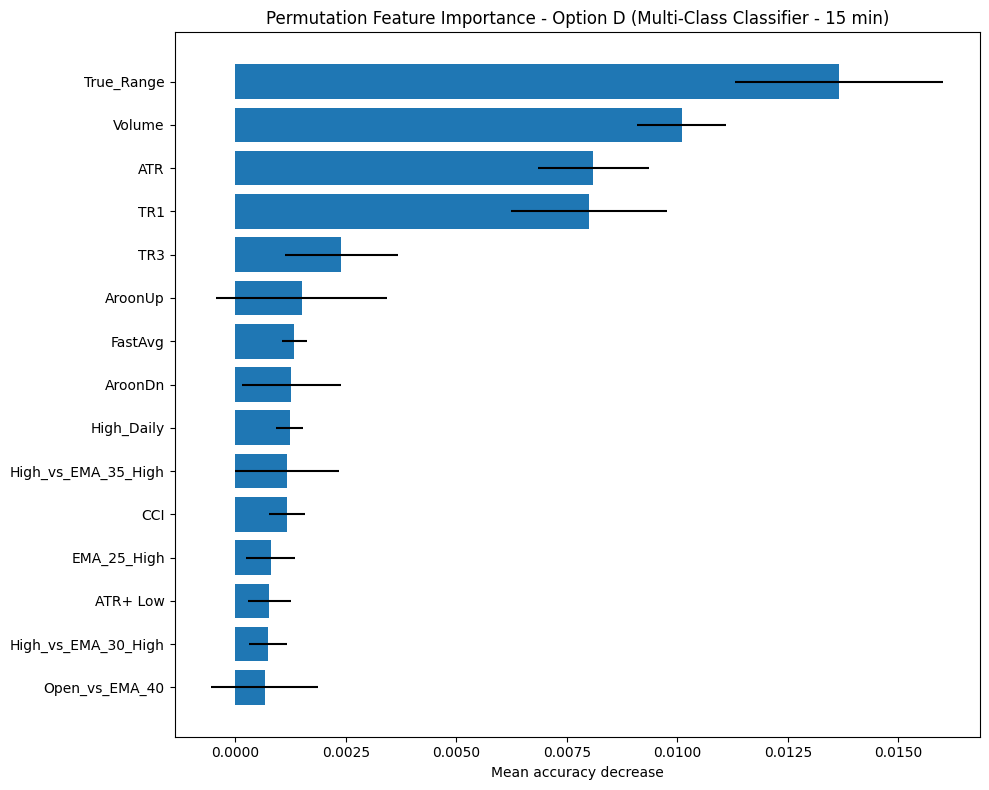

In [83]:
from sklearn.inspection import permutation_importance

def analyze_permutation_importance(trainer_obj, name, X_test, y_test, n_repeats=5, top_n=15, plot=True):
    """
    Analyze permutation feature importance for a given classifier trainer object.
    
    Args:
        trainer_obj: The trainer object
        name: String name for the model
        X_test: Test features DataFrame
        y_test: Test labels Series
        n_repeats: Number of permutation repetitions
        top_n: Number of top features to display
        plot: Whether to create visualization
    """
    model = trainer_obj.rf_results["model"]
    
    # Get feature names
    feature_names = model.feature_names_in_ if hasattr(model, "feature_names_in_") else [f"Feature_{i}" for i in range(model.n_features_in_)]
    
    # Calculate permutation importance
    print(f"Calculating permutation importance for {name}...")
    perm_importance = permutation_importance(model, X_test, y_test, 
                                             n_repeats=n_repeats, random_state=42)
    
    # Sort features by importance
    indices = np.argsort(perm_importance.importances_mean)[::-1]
    sorted_names = [feature_names[i] for i in indices]
    sorted_importance = perm_importance.importances_mean[indices]
    
    # Print top features
    print(f"🔍 Top {top_n} Features by Permutation Importance for {name}:")
    for i in range(min(top_n, len(sorted_names))):
        print(f"{i+1}. {sorted_names[i]}: {sorted_importance[i]:.4f} ± {perm_importance.importances_std[indices[i]]:.4f}")
    
    # Create visualization
    if plot:
        plt.figure(figsize=(10, 8))
        plt.title(f"Permutation Feature Importance - {name}")
        plt.barh(range(min(top_n, len(sorted_names))), 
                sorted_importance[:top_n], 
                xerr=perm_importance.importances_std[indices][:top_n],
                align='center')
        plt.yticks(range(min(top_n, len(sorted_names))), sorted_names[:top_n])
        plt.gca().invert_yaxis()  # Display highest importance at top
        plt.xlabel('Mean accuracy decrease')
        plt.tight_layout()
        plt.show()
        
    return sorted_names, sorted_importance

# For Goal C (Binary Classifier - All Bars)
perm_names_c, perm_importance_c = analyze_permutation_importance(
    classifier_trainer_all_goal_c, 
    "Goal C (Binary Classifier - All Bars)",
    X_test_all_goal_c,
    y_test_all_goal_c,
    n_repeats=5, 
    top_n=15
)


# For Option D (Multi-Class Classifier - 15 min)
# You'll need to adapt this based on your variable names for Option D
perm_names_d, perm_importance_d = analyze_permutation_importance(
    classifier_trainer_d_15m, 
    "Option D (Multi-Class Classifier - 15 min)",
    X_test_d_15m,  # Replace with your actual variable name
    y_test_d_15m,  # Replace with your actual variable name
    n_repeats=5, 
    top_n=15
)

📊 Feature Correlations with Target for Goal C:
TR3                    0.020850
High_Daily             0.012302
True_Range             0.008667
Open_vs_EMA_15        -0.007960
SlowAvg               -0.010069
EMA_25_High           -0.010147
High_Max_12           -0.011000
SenkouSpan_A          -0.011042
TR2                   -0.012037
Typical_Price         -0.013111
Close                 -0.013589
MACD                  -0.014693
High_vs_EMA_25_High   -0.018386
ADX                   -0.022490
Prev_Label            -0.082149
Name: target, dtype: float64


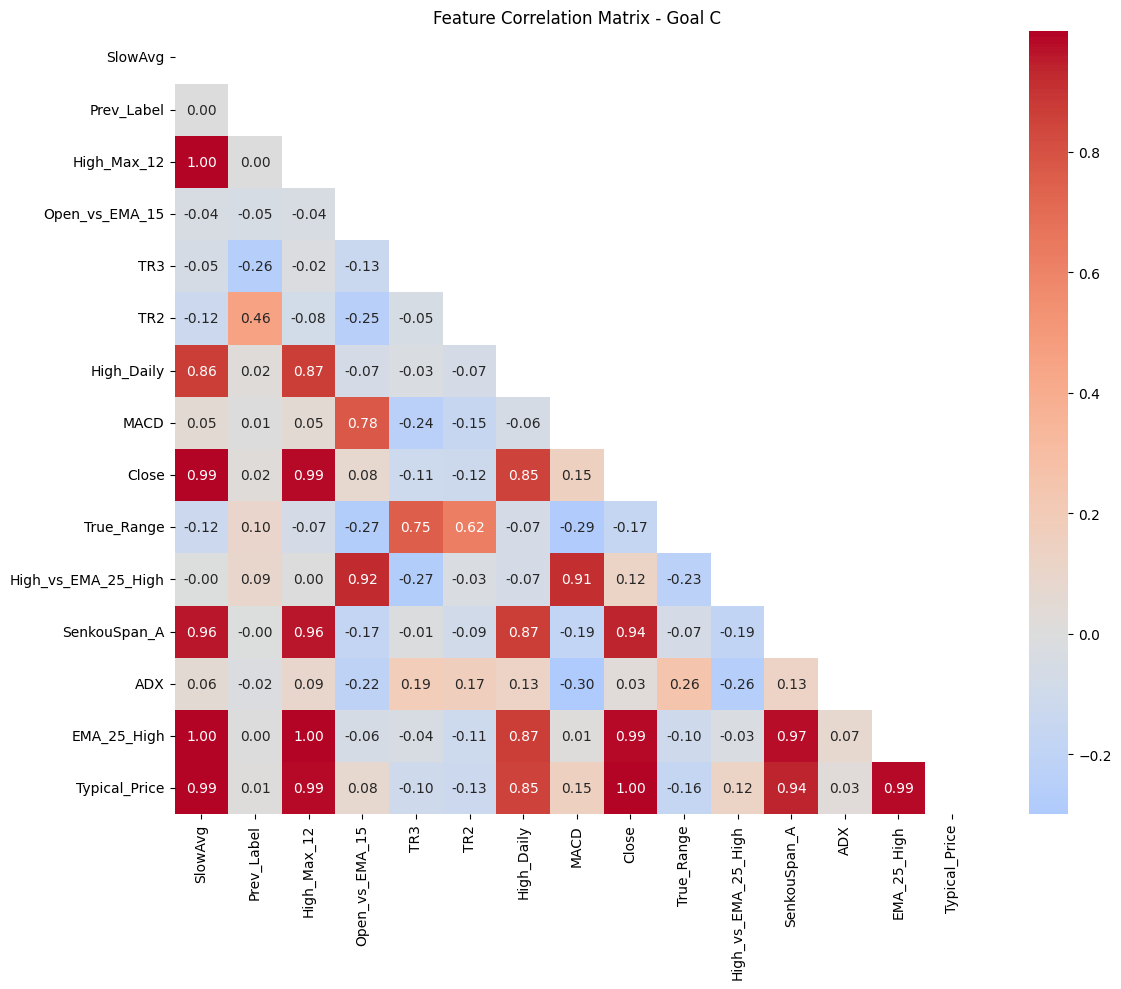

📊 Feature Correlations with Target for Option D:
True_Range             0.062937
TR1                    0.062345
TR3                    0.057667
ATR                    0.057601
Volume                 0.035835
AroonUp                0.018316
High_vs_EMA_30_High    0.006771
CCI                    0.006567
High_vs_EMA_35_High    0.005164
Open_vs_EMA_40         0.003448
AroonDn               -0.000781
High_Daily            -0.009196
EMA_25_High           -0.019290
FastAvg               -0.019730
ATR+ Low              -0.020772
Name: target, dtype: float64


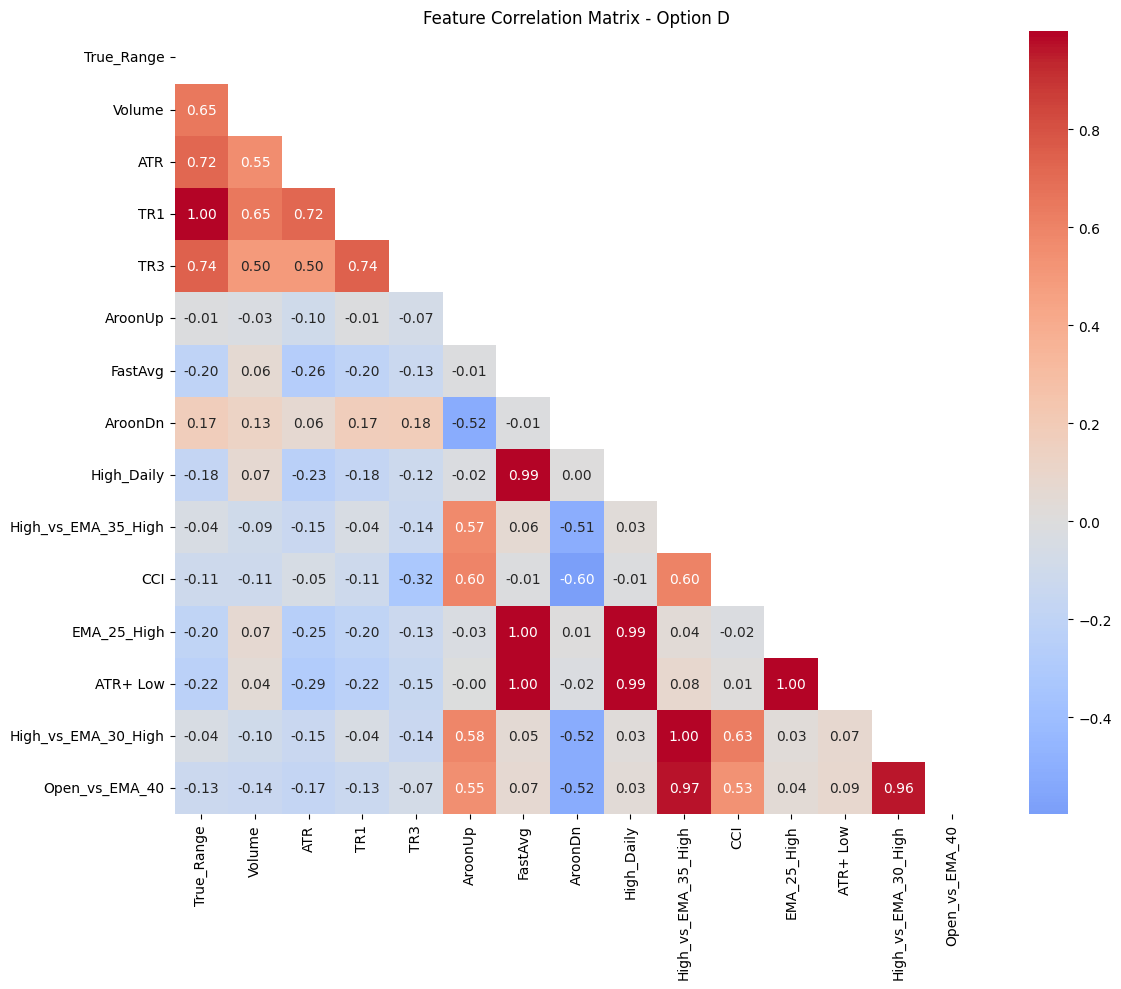

True_Range             0.062937
TR1                    0.062345
TR3                    0.057667
ATR                    0.057601
Volume                 0.035835
AroonUp                0.018316
High_vs_EMA_30_High    0.006771
CCI                    0.006567
High_vs_EMA_35_High    0.005164
Open_vs_EMA_40         0.003448
AroonDn               -0.000781
High_Daily            -0.009196
EMA_25_High           -0.019290
FastAvg               -0.019730
ATR+ Low              -0.020772
Name: target, dtype: float64

In [85]:
def analyze_feature_correlations(trainer_obj, name, X_train, y_train, top_features=None, n_features=15):
    """
    Analyze correlations between top features and target.
    
    Args:
        trainer_obj: The trainer object
        name: String name for the model
        X_train: Training features DataFrame
        y_train: Training labels Series
        top_features: List of top feature names (if None, uses all features)
        n_features: Number of top features to analyze
    """
    # Get feature names from the model
    if hasattr(trainer_obj.rf_results["model"], "feature_names_in_"):
        feature_names = trainer_obj.rf_results["model"].feature_names_in_
    else:
        feature_names = X_train.columns.tolist()
    
    # Select features to analyze
    if top_features is not None:
        selected_indices = [list(feature_names).index(feat) for feat in top_features[:n_features] if feat in feature_names]
        selected_features = [feature_names[i] for i in selected_indices]
    else:
        selected_features = feature_names[:n_features]
    
    # Create a DataFrame with selected features and target
    df = pd.DataFrame(X_train, columns=feature_names)
    df = df[selected_features]
    df['target'] = y_train
    
    # Calculate correlation with target
    correlations = df.corr()['target'].drop('target').sort_values(ascending=False)
    
    print(f"📊 Feature Correlations with Target for {name}:")
    print(correlations)
    
    # Create correlation heatmap between features
    plt.figure(figsize=(12, 10))
    feature_corr = df[selected_features].corr()
    mask = np.triu(np.ones_like(feature_corr, dtype=bool))
    sns.heatmap(feature_corr, mask=mask, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title(f"Feature Correlation Matrix - {name}")
    plt.tight_layout()
    plt.show()
    
    return correlations

# Analyze correlations for top features from permutation importance
analyze_feature_correlations(
    classifier_trainer_all_goal_c, 
    "Goal C", 
    classifier_X_train_bal_all_goal_c,  # Use the balanced training data
    classifier_y_train_bal_all_goal_c,
    top_features=perm_names_c, 
    n_features=15
)

# For Option D, replace with your actual variable names
analyze_feature_correlations(
    classifier_trainer_d_15m, 
    "Option D", 
    classifier_X_train_bal_d_15m,  # Replace with your actual variable name
    classifier_y_train_bal_d_15m,  # Replace with your actual variable name
    top_features=perm_names_d, 
    n_features=15
)

C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\1214335884.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = y_train


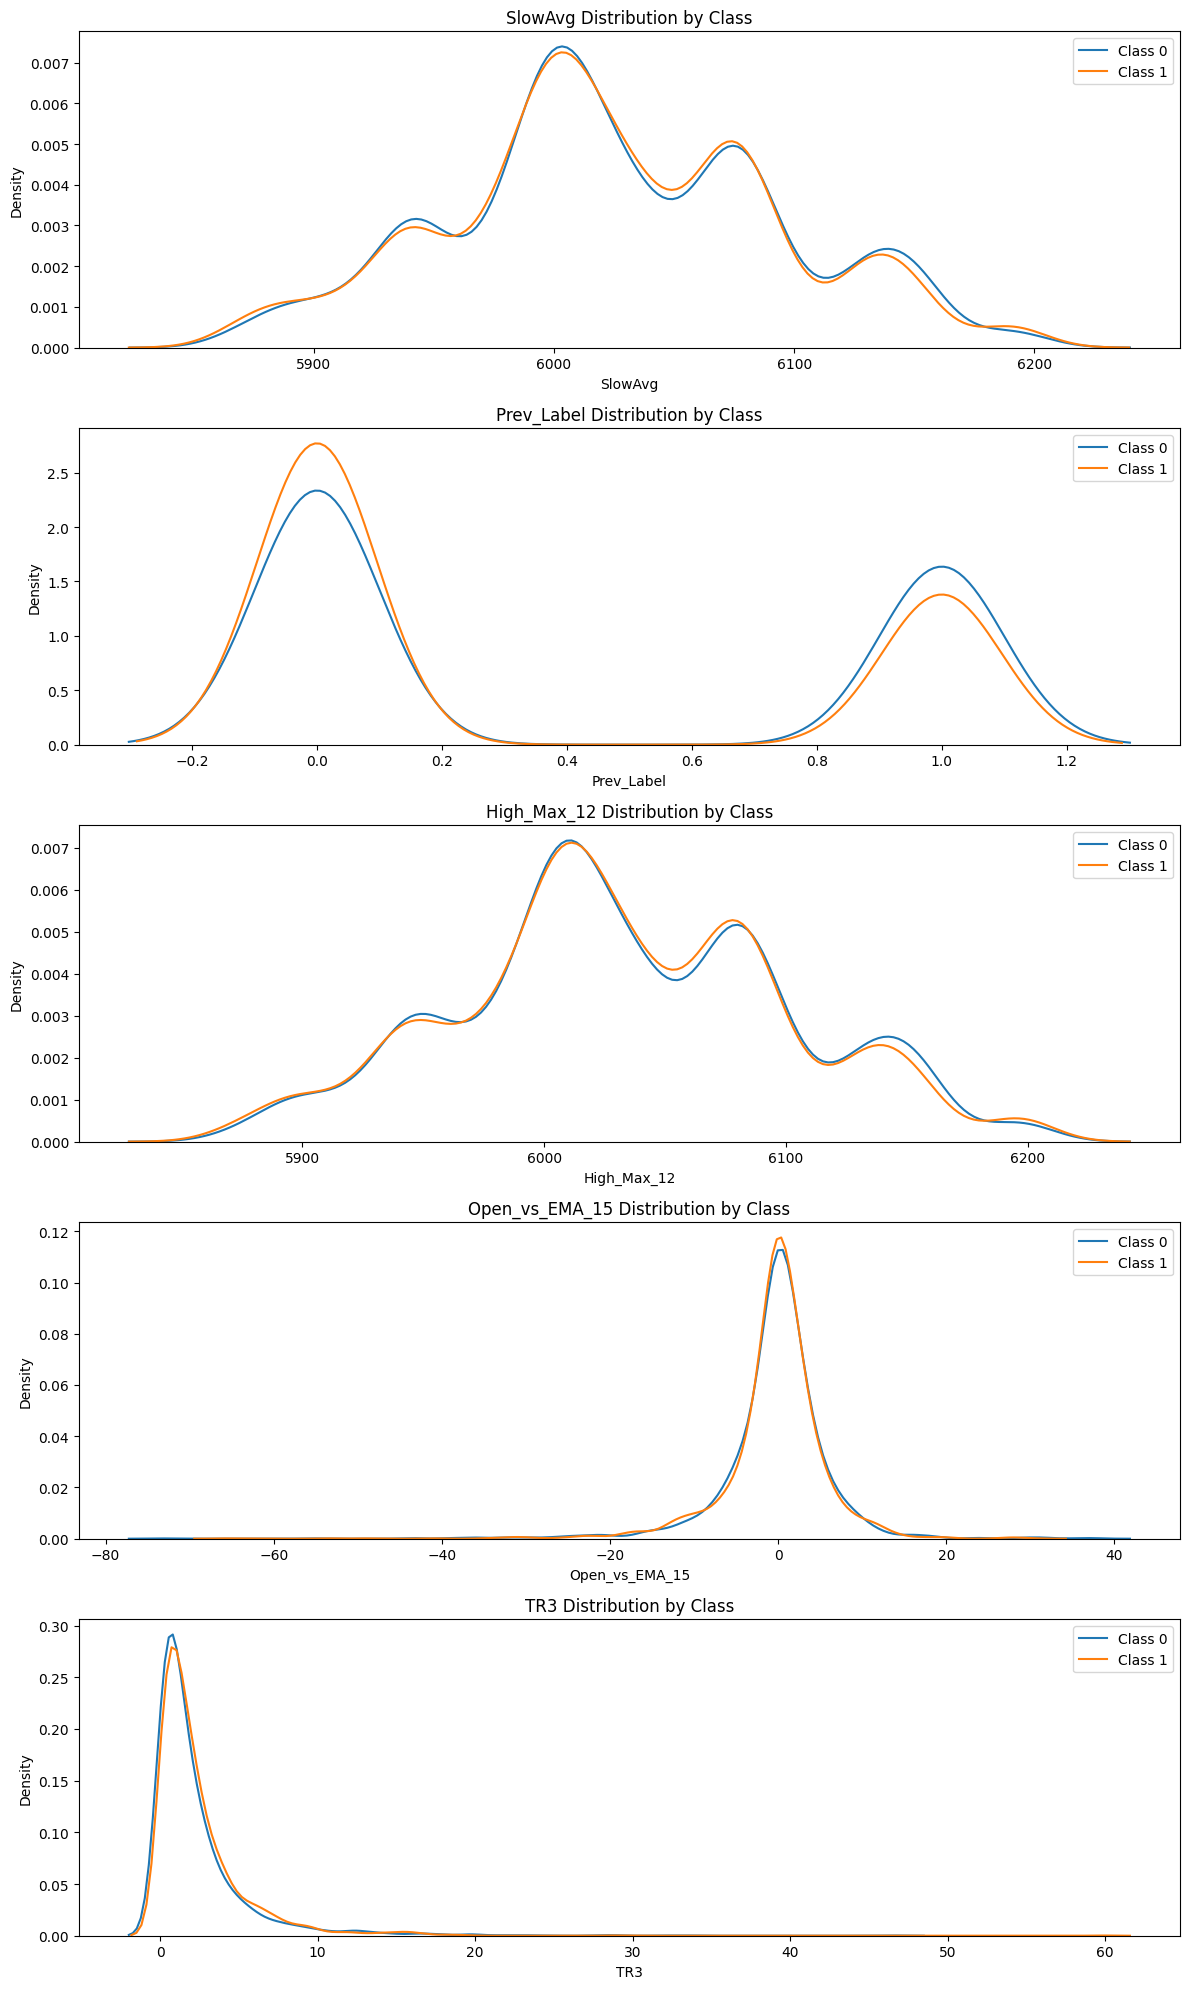

C:\Users\itzha\AppData\Local\Temp\ipykernel_165476\1214335884.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = y_train


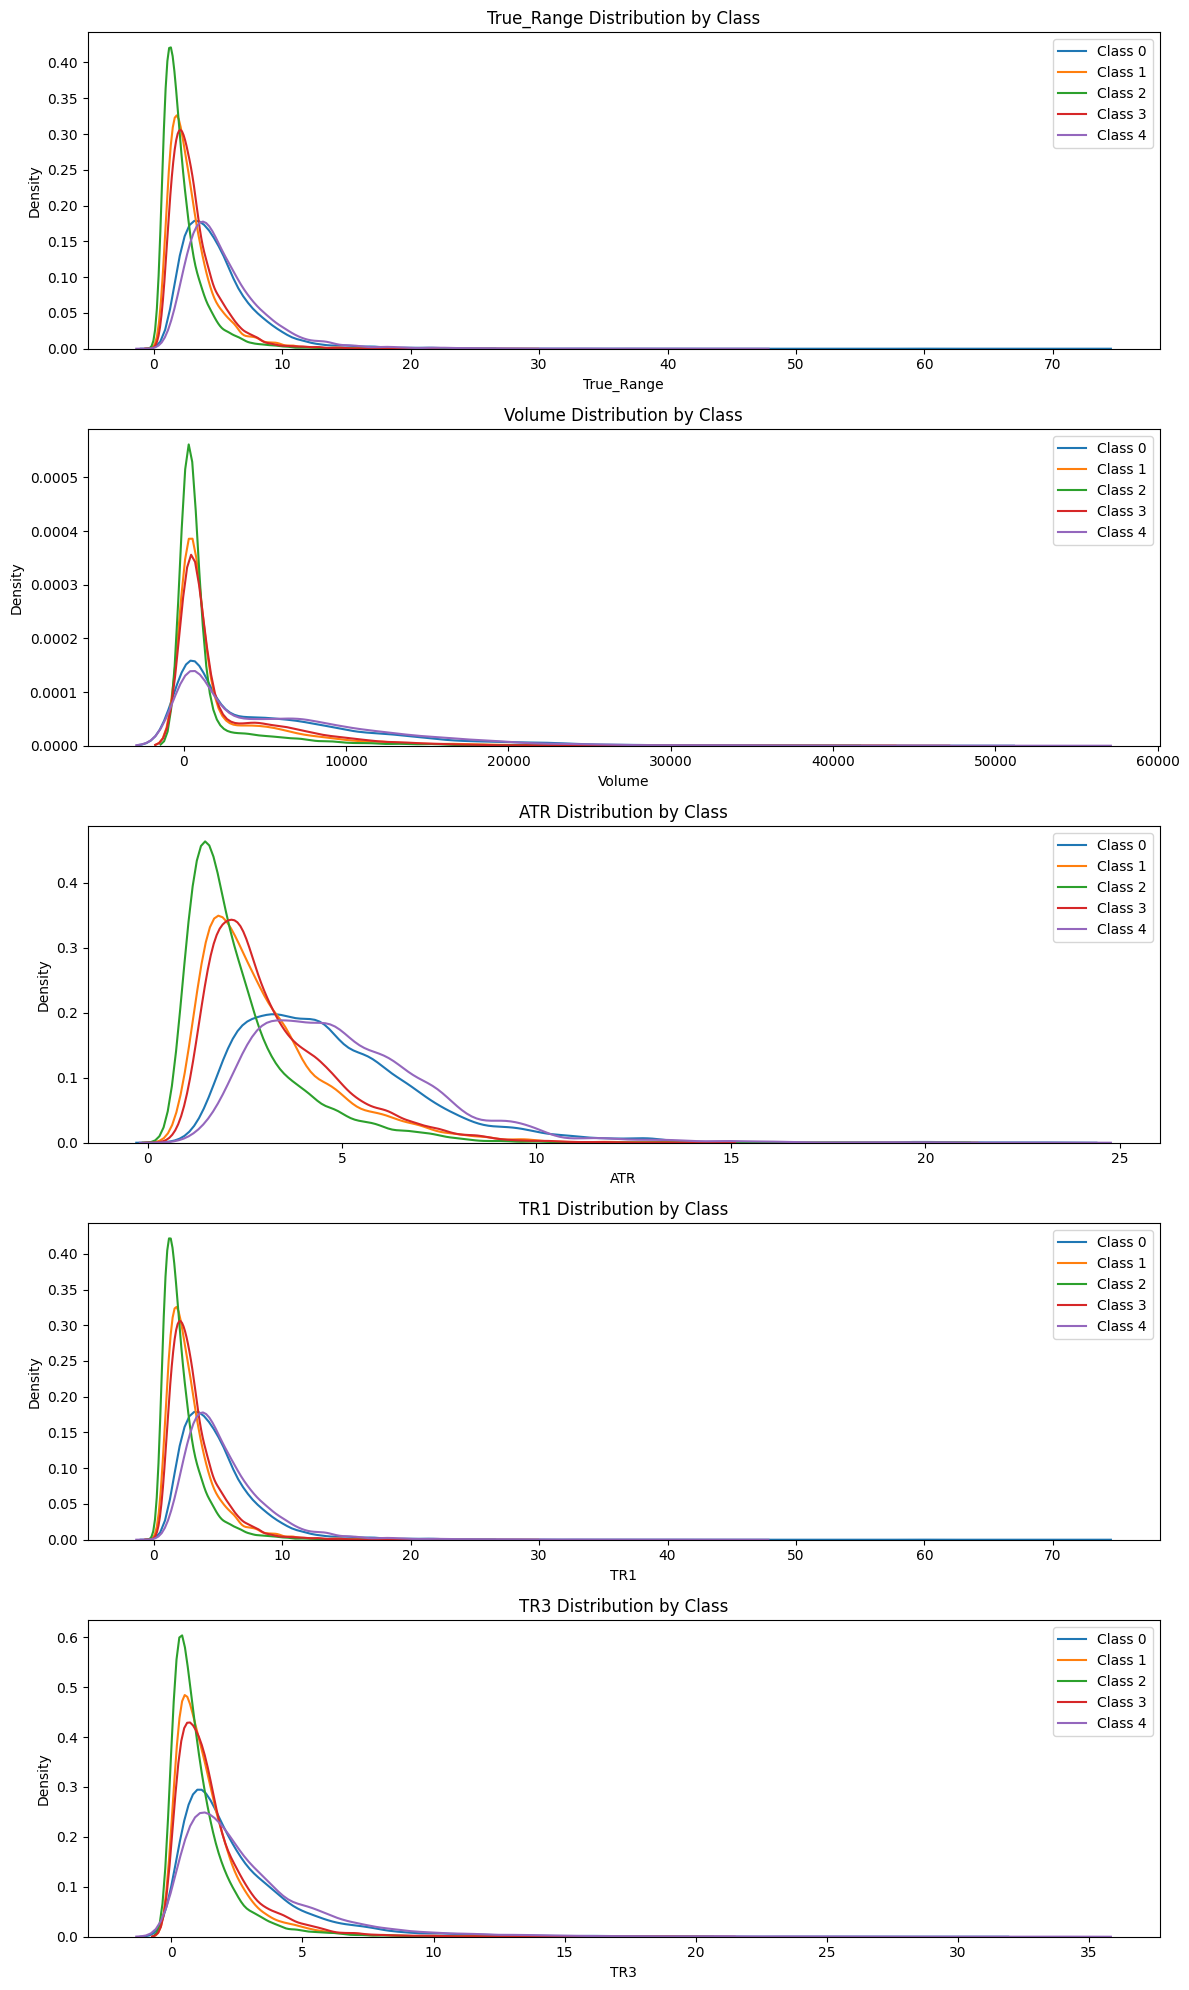

In [87]:
def plot_feature_distributions(trainer_obj, name, X_train, y_train, top_features=None, n_features=5):
    """
    Plot feature distributions separated by class.
    
    Args:
        trainer_obj: The trainer object
        name: String name for the model
        X_train: Training features DataFrame
        y_train: Training labels Series
        top_features: List of top feature names (if None, uses all features)
        n_features: Number of top features to visualize
    """
    # Get feature names from the model
    if hasattr(trainer_obj.rf_results["model"], "feature_names_in_"):
        feature_names = trainer_obj.rf_results["model"].feature_names_in_
    else:
        feature_names = X_train.columns.tolist()
    
    # Select features to analyze
    if top_features is not None:
        selected_indices = [list(feature_names).index(feat) for feat in top_features[:n_features] if feat in feature_names]
        selected_features = [feature_names[i] for i in selected_indices]
    else:
        selected_features = feature_names[:n_features]
    
    # Create DataFrame
    df = pd.DataFrame(X_train, columns=feature_names)
    df['target'] = y_train
    
    # Visualize distributions
    fig, axes = plt.subplots(len(selected_features), 1, figsize=(12, 4*len(selected_features)))
    if len(selected_features) == 1:
        axes = [axes]
    
    for i, feature in enumerate(selected_features):
        ax = axes[i]
        for target_class in np.unique(y_train):
            sns.kdeplot(df[df['target'] == target_class][feature], 
                        label=f"Class {target_class}", ax=ax)
        ax.set_title(f"{feature} Distribution by Class")
        ax.legend()
    
    plt.tight_layout()
    plt.show()

# Plot distributions for top features from permutation importance
plot_feature_distributions(
    classifier_trainer_all_goal_c, 
    "Goal C", 
    classifier_X_train_bal_all_goal_c,  # Use the balanced training data
    classifier_y_train_bal_all_goal_c,
    top_features=perm_names_c, 
    n_features=5
)

# For Option D, replace with your actual variable names
plot_feature_distributions(
    classifier_trainer_d_15m, 
    "Option D", 
    classifier_X_train_bal_d_15m,  # Replace with your actual variable name
    classifier_y_train_bal_d_15m,  # Replace with your actual variable name
    top_features=perm_names_d, 
    n_features=5
)

Running stability analysis for Goal C (Binary Classifier) with 5 iterations...

🔍 Feature Importance Stability for Goal C (Binary Classifier):
                    mean_rank  std_rank  appearance_rate
Williams_R           1.800000  0.400000              1.4
Relative_Volume      2.400000  1.496663              1.4
Volume               4.000000  0.894427              1.4
TR3                  4.400000  3.072458              1.4
CCI_Avg              5.200000  1.166190              1.4
Close_vs_EMA_5       6.800000  2.481935              1.4
AroonDn              8.000000  1.000000              0.8
ADX                  8.000000  3.949684              1.4
TR2                  9.200000  3.655133              1.4
True_Range           9.250000  1.785357              1.2
TR1                 10.333333  3.091206              1.0
AroonUp             10.333333  2.624669              1.0
Close_vs_EMA_10     10.500000  2.500000              0.8
High_vs_EMA_5_High  11.000000  1.224745              1.2
DM

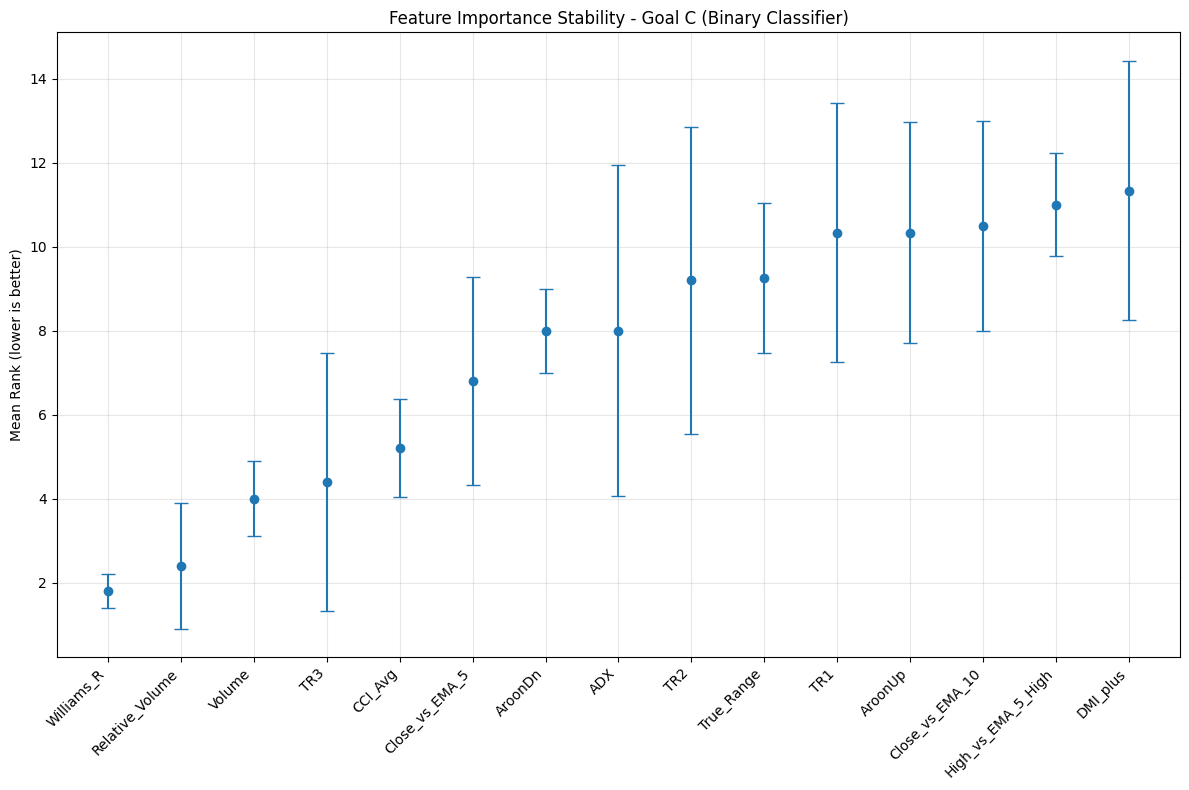

Running stability analysis for Option D (Multi-Class Classifier) with 5 iterations...

🔍 Feature Importance Stability for Option D (Multi-Class Classifier):
                 mean_rank  std_rank  appearance_rate
True_Range        1.000000  0.000000              1.4
TR1               2.200000  0.400000              1.4
ATR               2.800000  0.400000              1.4
TR2               4.200000  0.400000              1.4
TR3               5.000000  0.632456              1.4
Volume            5.800000  0.400000              1.4
AroonDn           7.200000  0.400000              1.4
movement          8.400000  0.489898              1.4
AroonUp           8.400000  0.800000              1.4
Relative_Volume  10.000000  0.000000              1.4
Open_vs_EMA_20   11.000000  0.000000              0.8
Close_vs_EMA_5   11.666667  0.471405              1.0
Open_vs_EMA_30   12.000000  0.000000              0.6
Close_vs_EMA_35  12.500000  1.500000              1.2
Close_vs_EMA_20  12.500000  0.500

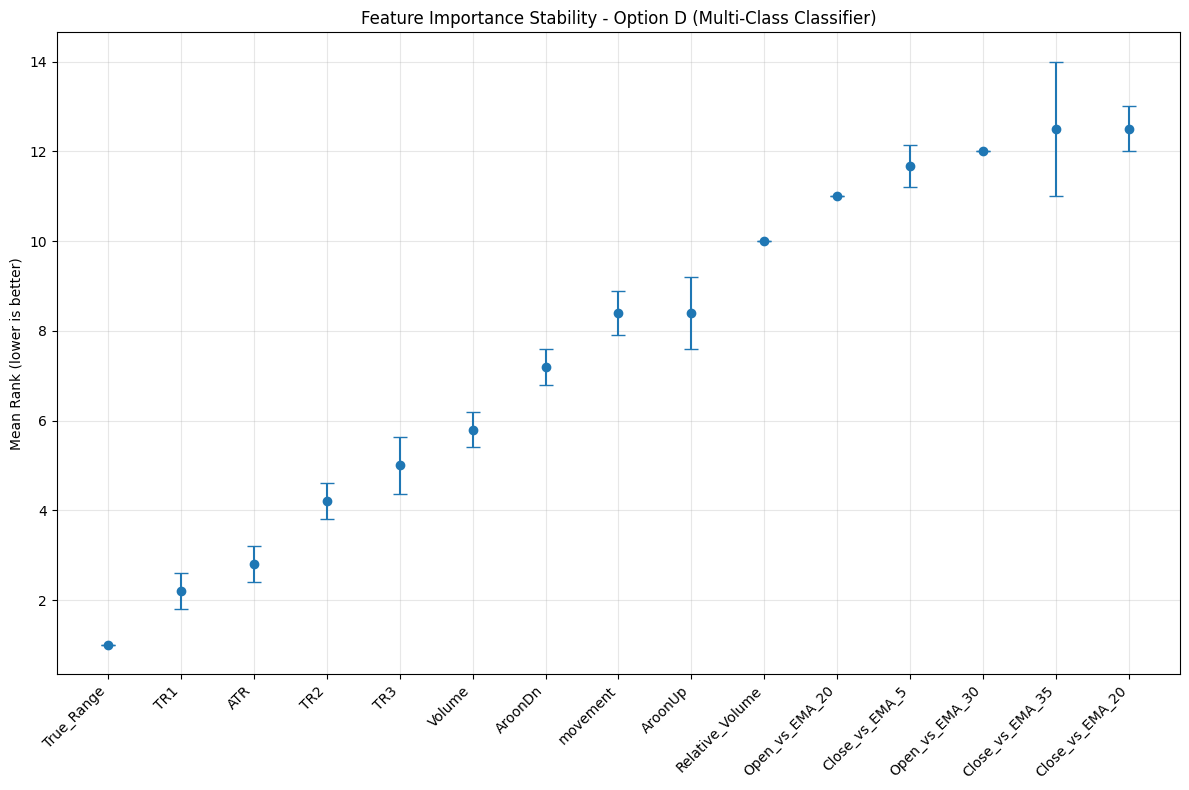

In [89]:
from sklearn.base import clone

def feature_importance_stability(trainer_obj, name, X_train, y_train, n_iterations=5, sample_size=0.8, top_n=15):
    """
    Analyze stability of feature importance by repeatedly training models on different samples.
    
    Args:
        trainer_obj: The trainer object
        name: String name for the model
        X_train: Training features DataFrame
        y_train: Training labels Series
        n_iterations: Number of subsamples to create
        sample_size: Fraction of training data to use in each iteration
        top_n: Number of top features to track
    """
    # Get original model and feature names
    original_model = trainer_obj.rf_results["model"]
    if hasattr(original_model, "feature_names_in_"):
        feature_names = original_model.feature_names_in_
    else:
        feature_names = X_train.columns.tolist()
    
    # Create a DataFrame to track feature ranks
    feature_ranks = pd.DataFrame(index=feature_names)
    
    # Function to train new model and get importance
    def train_and_get_importance(X_sample, y_sample):
        # Clone the original model
        model = clone(original_model)
        model.fit(X_sample, y_sample)
        
        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_
        elif hasattr(model, "coef_"):
            importances = np.abs(model.coef_).mean(axis=0) if model.coef_.ndim > 1 else np.abs(model.coef_)
        else:
            return None
            
        # Get top features
        indices = np.argsort(importances)[::-1]
        return {feature_names[i]: {'rank': r+1, 'importance': importances[i]} 
                for r, i in enumerate(indices[:top_n])}
    
    print(f"Running stability analysis for {name} with {n_iterations} iterations...")
    
    # Convert to numpy for indexing if DataFrame
    X_np = X_train.values if hasattr(X_train, 'values') else X_train
    y_np = y_train.values if hasattr(y_train, 'values') else y_train
    
    # Run multiple iterations
    for i in range(n_iterations):
        # Sample data
        sample_indices = np.random.choice(len(X_np), size=int(sample_size * len(X_np)), replace=False)
        X_sample, y_sample = X_np[sample_indices], y_np[sample_indices]
        
        # Get importance
        imp = train_and_get_importance(X_sample, y_sample)
        if imp is None:
            continue
            
        # Record ranks
        col_name = f"Iteration_{i+1}"
        feature_ranks[col_name] = np.nan
        for feature, data in imp.items():
            feature_ranks.loc[feature, col_name] = data['rank']
    
    # Calculate stability metrics
    feature_ranks['mean_rank'] = feature_ranks.mean(axis=1)
    feature_ranks['std_rank'] = feature_ranks.std(axis=1)
    feature_ranks['appearance_rate'] = feature_ranks.count(axis=1) / n_iterations
    
    # Sort by mean rank
    feature_ranks = feature_ranks.sort_values('mean_rank')
    
    # Display results
    print(f"\n🔍 Feature Importance Stability for {name}:")
    stable_features = feature_ranks.head(top_n)[['mean_rank', 'std_rank', 'appearance_rate']]
    print(stable_features)
    
    # Plot stability
    plt.figure(figsize=(12, 8))
    plt.errorbar(range(len(stable_features)), stable_features['mean_rank'], 
                 yerr=stable_features['std_rank'], fmt='o', capsize=5)
    plt.xticks(range(len(stable_features)), stable_features.index, rotation=45, ha='right')
    plt.ylabel('Mean Rank (lower is better)')
    plt.title(f'Feature Importance Stability - {name}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return feature_ranks

# Run stability analysis for both models (this may take some time)
stability_c = feature_importance_stability(
    classifier_trainer_all_goal_c, 
    "Goal C (Binary Classifier)",
    classifier_X_train_bal_all_goal_c,  # Use the balanced training data
    classifier_y_train_bal_all_goal_c,
    n_iterations=5,
    top_n=15
)

# For Option D, replace with your actual variable names
stability_d = feature_importance_stability(
    classifier_trainer_d_15m, 
    "Option D (Multi-Class Classifier)",
    classifier_X_train_bal_d_15m,  # Replace with your actual variable name
    classifier_y_train_bal_d_15m,  # Replace with your actual variable name
    n_iterations=5,
    top_n=15
)

## Calling al feature imprtnace funstions!!!

📊 Starting comprehensive feature analysis for Goal C (Binary Classifier)...

🔍 ANALYSIS 1: Basic Feature Importance from Model
  Top 15 Features:
  1. Volume: 0.0265
  2. Relative_Volume: 0.0264
  3. Williams_R: 0.0254
  4. CCI_Avg: 0.0218
  5. TR3: 0.0215
  6. Close_vs_EMA_5: 0.0210
  7. TR2: 0.0201
  8. ADX: 0.0191
  9. Close_vs_EMA_10: 0.0168
  10. CCI: 0.0164
  11. AroonDn: 0.0162
  12. TR1: 0.0161
  13. AroonUp: 0.0154
  14. Open_vs_EMA_5: 0.0150
  15. True_Range: 0.0150


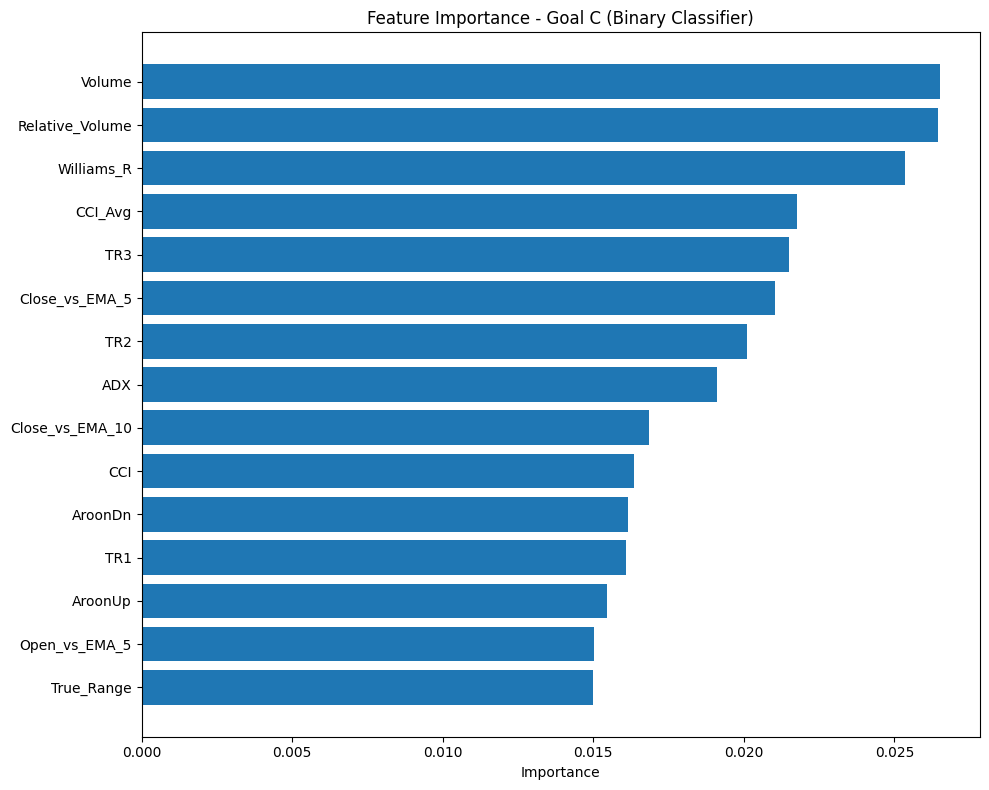


🔍 ANALYSIS 2: Permutation Importance
  Calculating permutation importance for Goal C (Binary Classifier)...
  Top 15 Features by Permutation Importance:
  1. SlowAvg: 0.0047 ± 0.0017
  2. Prev_Label: 0.0038 ± 0.0072
  3. High_Max_12: 0.0033 ± 0.0011
  4. Open_vs_EMA_15: 0.0033 ± 0.0025
  5. TR3: 0.0032 ± 0.0037
  6. TR2: 0.0025 ± 0.0032
  7. High_Daily: 0.0022 ± 0.0019
  8. MACD: 0.0022 ± 0.0043
  9. Close: 0.0020 ± 0.0015
  10. True_Range: 0.0018 ± 0.0056
  11. High_vs_EMA_25_High: 0.0017 ± 0.0036
  12. SenkouSpan_A: 0.0013 ± 0.0017
  13. ADX: 0.0013 ± 0.0029
  14. EMA_25_High: 0.0013 ± 0.0011
  15. Typical_Price: 0.0012 ± 0.0020


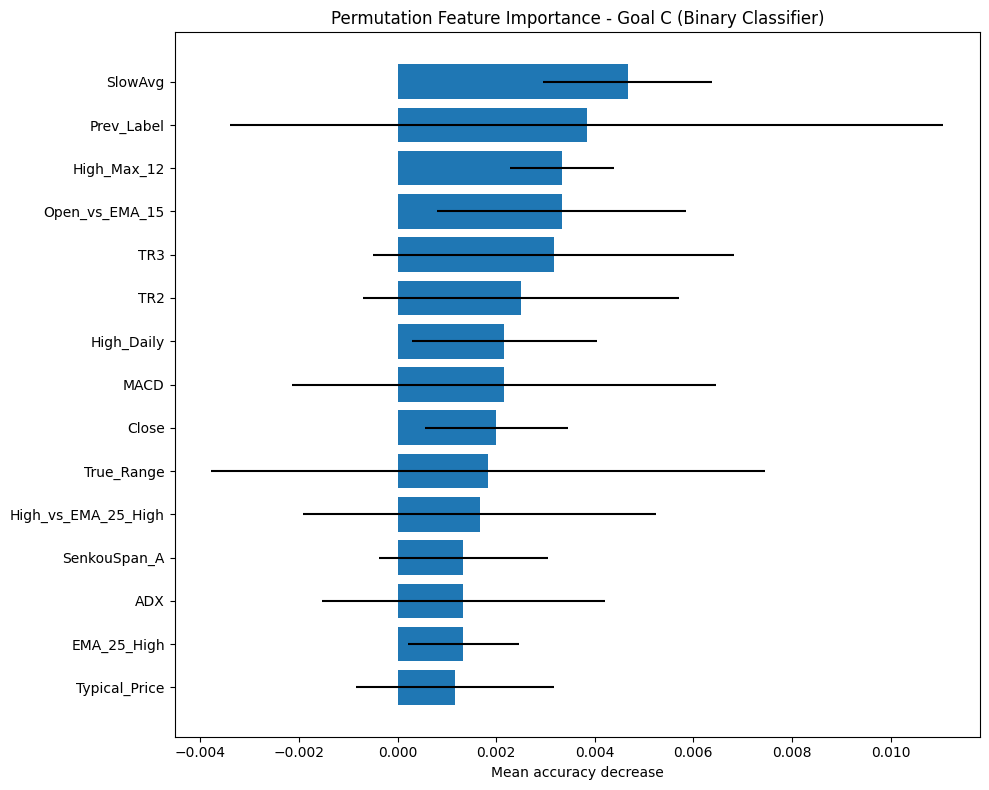

  ✅ Permutation importance completed in 14.2s

🔍 ANALYSIS 3: Feature Correlations
  📊 Feature Correlations with Target:
TR3                    0.020850
High_Daily             0.012302
True_Range             0.008667
Open_vs_EMA_15        -0.007960
SlowAvg               -0.010069
EMA_25_High           -0.010147
High_Max_12           -0.011000
SenkouSpan_A          -0.011042
TR2                   -0.012037
Typical_Price         -0.013111
Close                 -0.013589
MACD                  -0.014693
High_vs_EMA_25_High   -0.018386
ADX                   -0.022490
Prev_Label            -0.082149
Name: target, dtype: float64


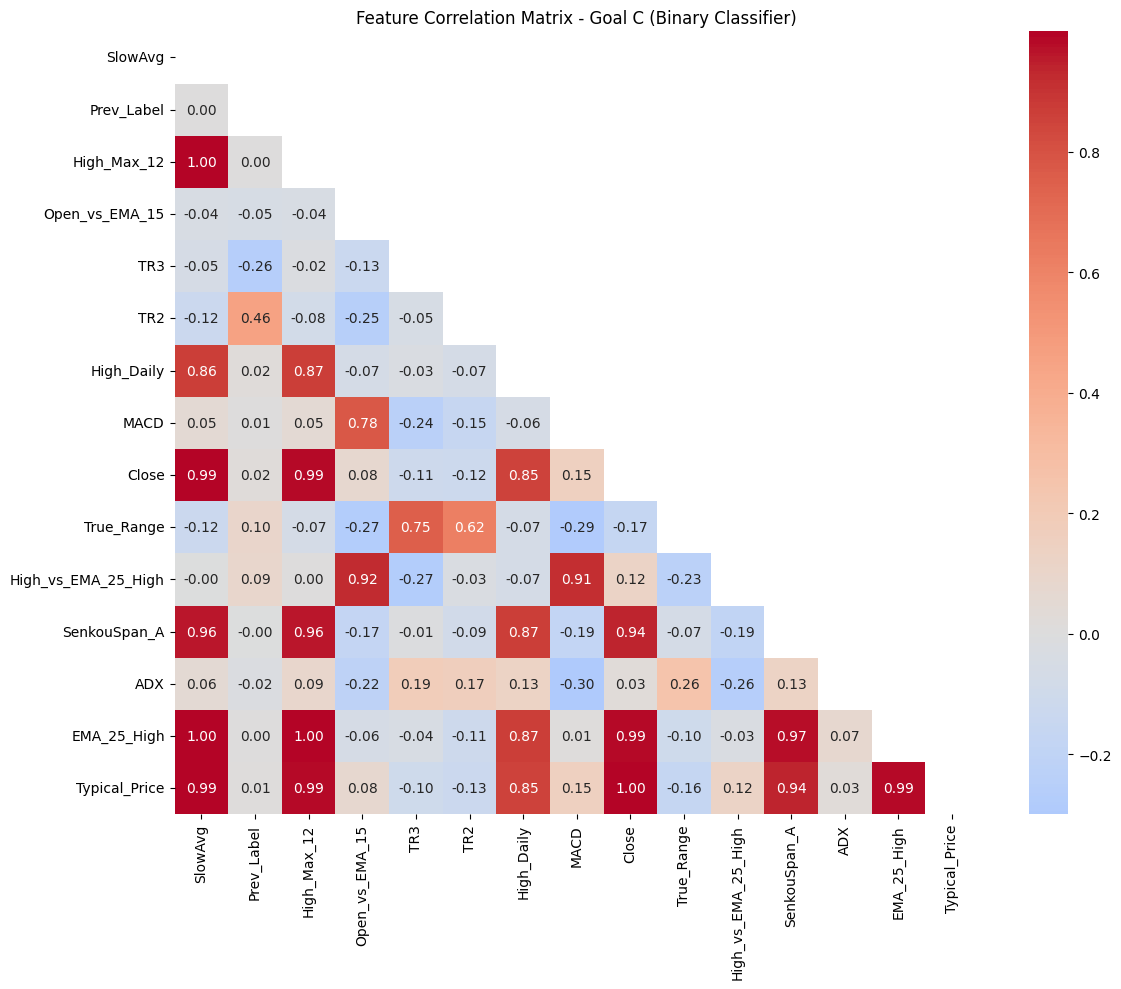


🔍 ANALYSIS 4: Feature Distributions by Class


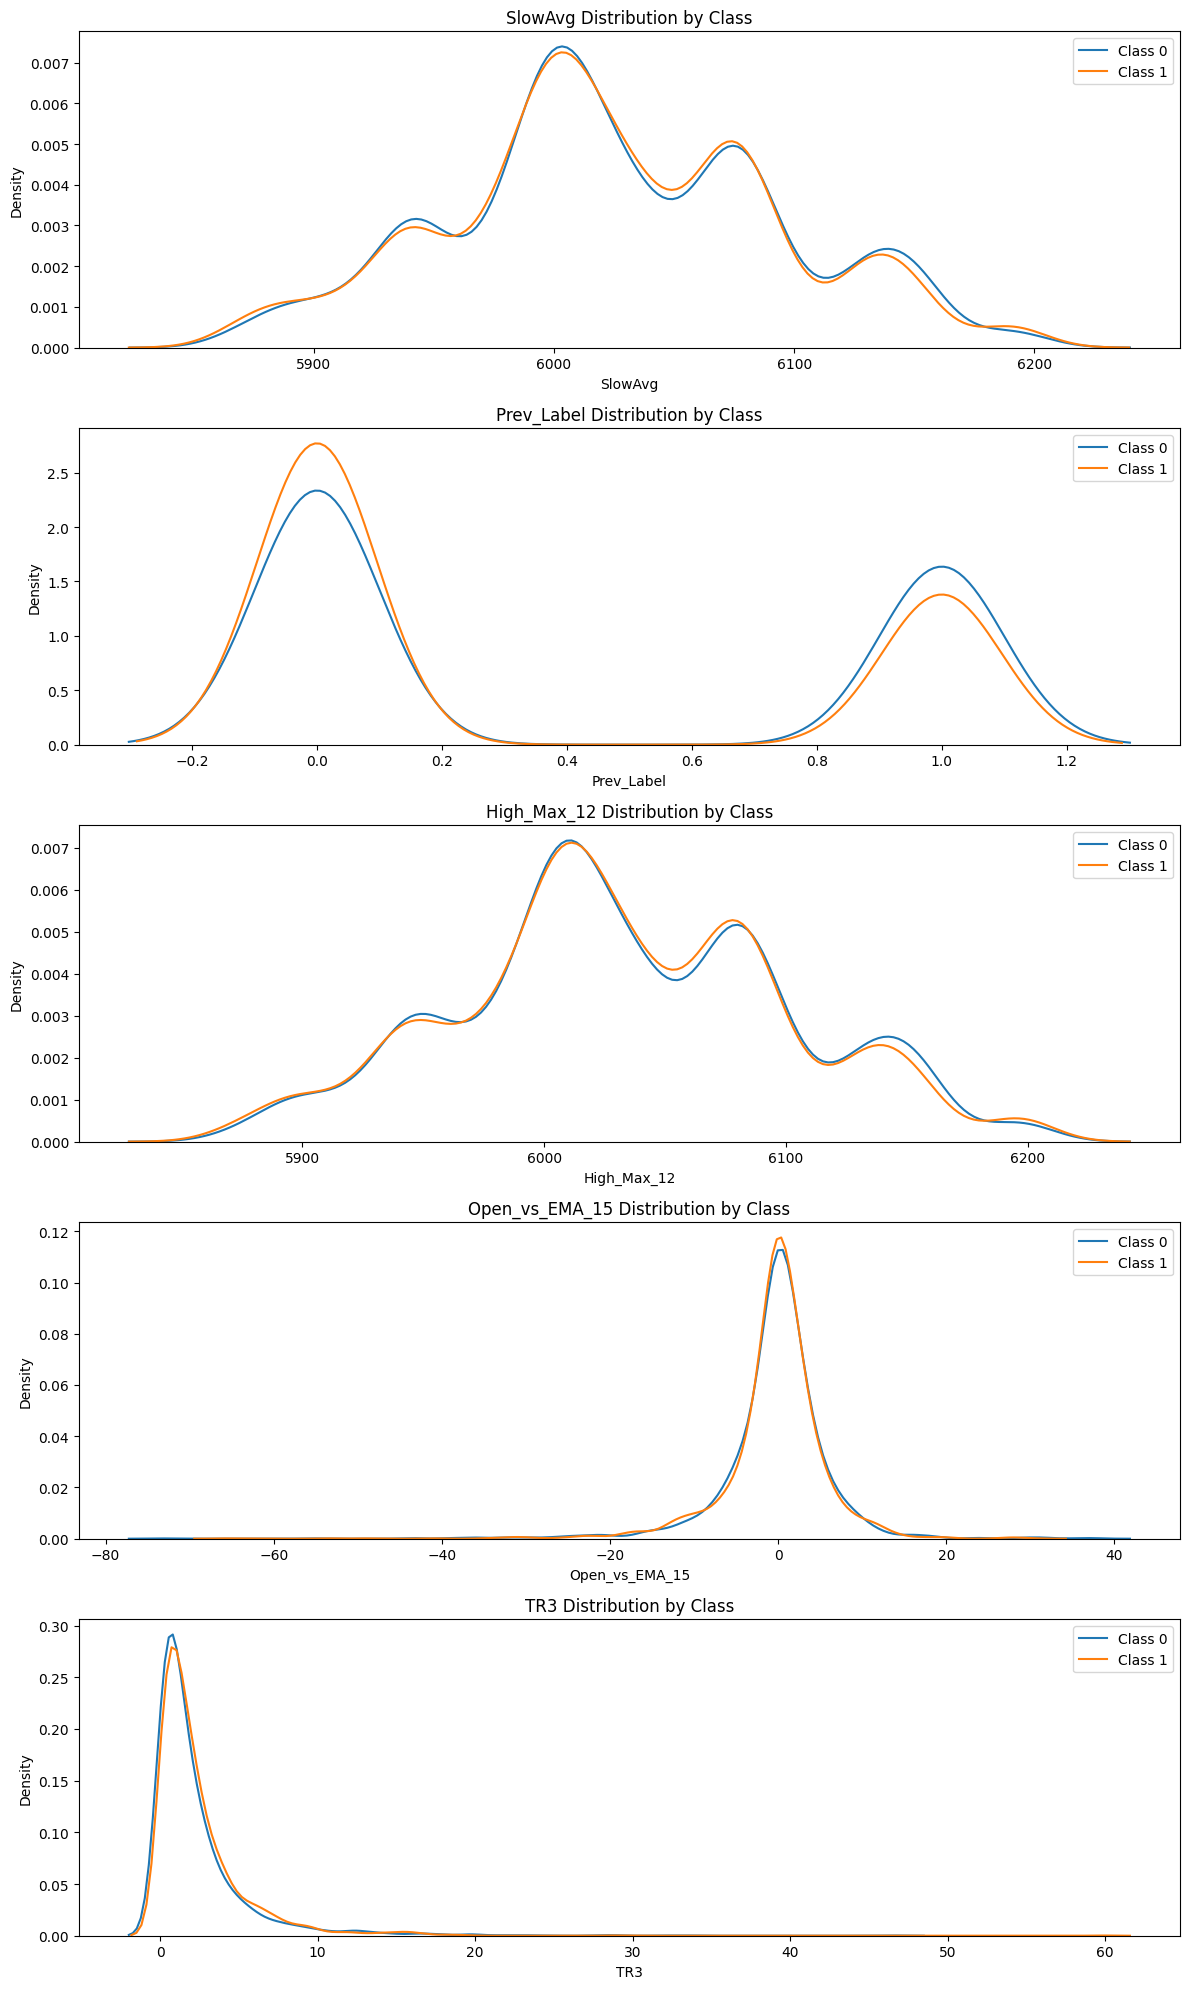


🔍 ANALYSIS 5: Feature Importance Stability
  Running stability analysis with 3 iterations...
  Iteration 1/3... Done
  Iteration 2/3... Done
  Iteration 3/3... Done

  🔍 Feature Importance Stability Results:
                 mean_rank  std_rank  appearance_rate
Relative_Volume   2.333333  0.942809         1.666667
TR3               3.000000  1.632993         1.666667
Williams_R        3.333333  0.942809         1.666667
CCI_Avg           4.666667  3.299832         1.666667
Volume            5.000000  2.160247         1.666667
Close_vs_EMA_5    6.333333  0.471405         1.666667
TR2               6.333333  4.189935         1.666667
AroonUp           7.500000  2.500000         1.333333
ADX               9.333333  2.624669         1.666667
True_Range       10.333333  2.624669         1.666667
ATR              10.500000  0.500000         1.333333
AroonDn          11.000000  2.000000         1.333333
CCI              11.000000  0.000000         1.000000
TR1              11.333333  2.49443

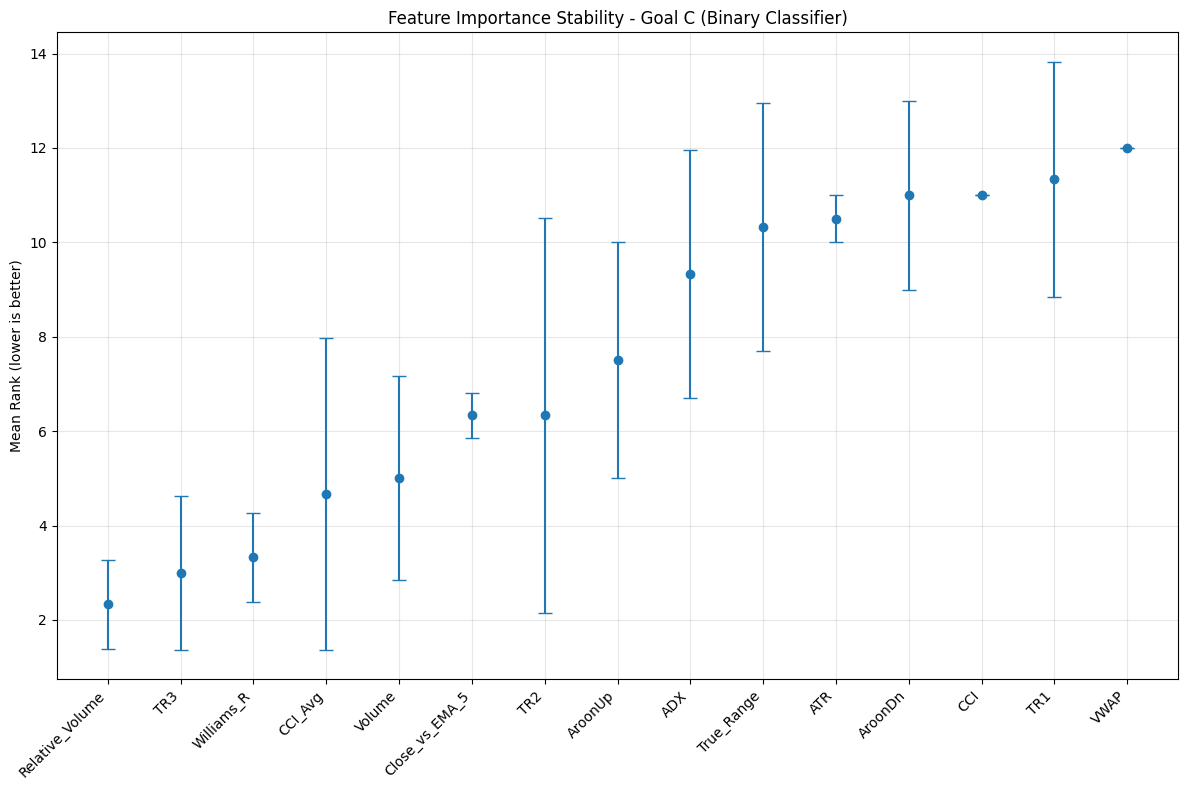

  ✅ Stability analysis completed in 11.8s

✅ Comprehensive feature analysis for Goal C (Binary Classifier) completed!
📊 Starting comprehensive feature analysis for Option D (Multi-Class Classifier)...

🔍 ANALYSIS 1: Basic Feature Importance from Model
  Top 15 Features:
  1. True_Range: 0.1164
  2. TR1: 0.0970
  3. ATR: 0.0944
  4. TR2: 0.0543
  5. TR3: 0.0510
  6. Volume: 0.0455
  7. AroonDn: 0.0165
  8. AroonUp: 0.0152
  9. movement: 0.0147
  10. Relative_Volume: 0.0120
  11. Close_vs_EMA_40: 0.0093
  12. Open_vs_EMA_40: 0.0090
  13. Close_vs_EMA_5: 0.0089
  14. Open_vs_EMA_50: 0.0088
  15. Open_vs_EMA_35: 0.0086


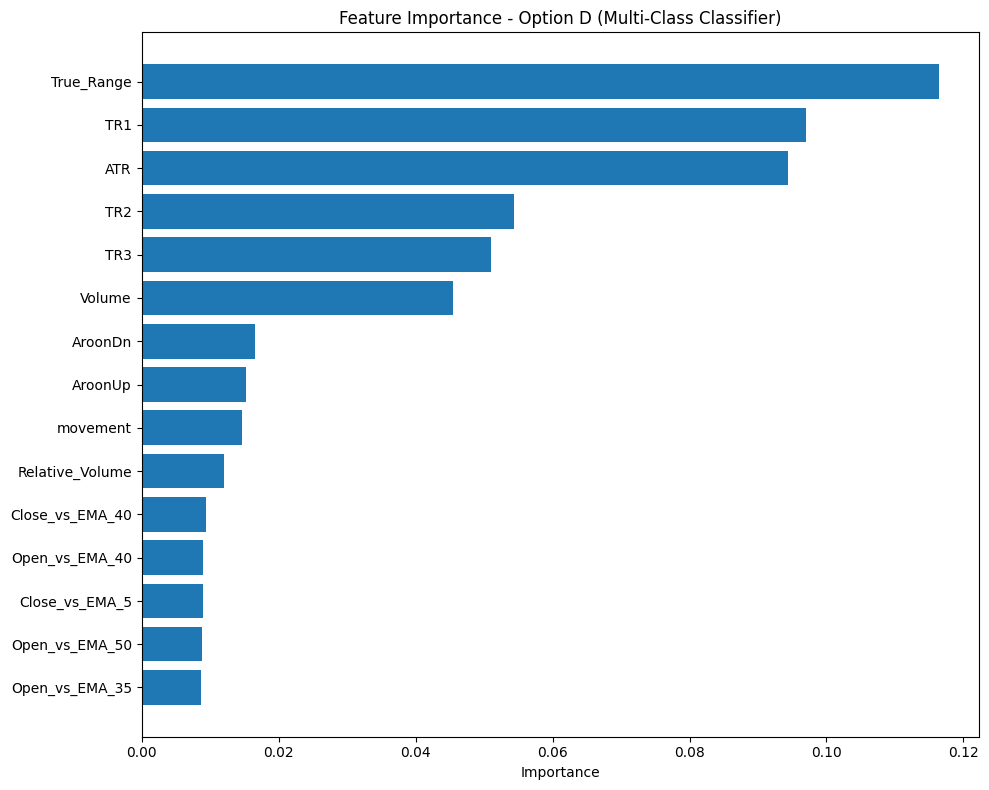


🔍 ANALYSIS 2: Permutation Importance
  Calculating permutation importance for Option D (Multi-Class Classifier)...
  Top 15 Features by Permutation Importance:
  1. True_Range: 0.0137 ± 0.0024
  2. Volume: 0.0101 ± 0.0010
  3. ATR: 0.0081 ± 0.0012
  4. TR1: 0.0080 ± 0.0018
  5. TR3: 0.0024 ± 0.0013
  6. AroonUp: 0.0015 ± 0.0019
  7. FastAvg: 0.0013 ± 0.0003
  8. AroonDn: 0.0013 ± 0.0011
  9. High_Daily: 0.0012 ± 0.0003
  10. High_vs_EMA_35_High: 0.0012 ± 0.0012
  11. CCI: 0.0012 ± 0.0004
  12. EMA_25_High: 0.0008 ± 0.0006
  13. ATR+ Low: 0.0008 ± 0.0005
  14. High_vs_EMA_30_High: 0.0007 ± 0.0004
  15. Open_vs_EMA_40: 0.0007 ± 0.0012


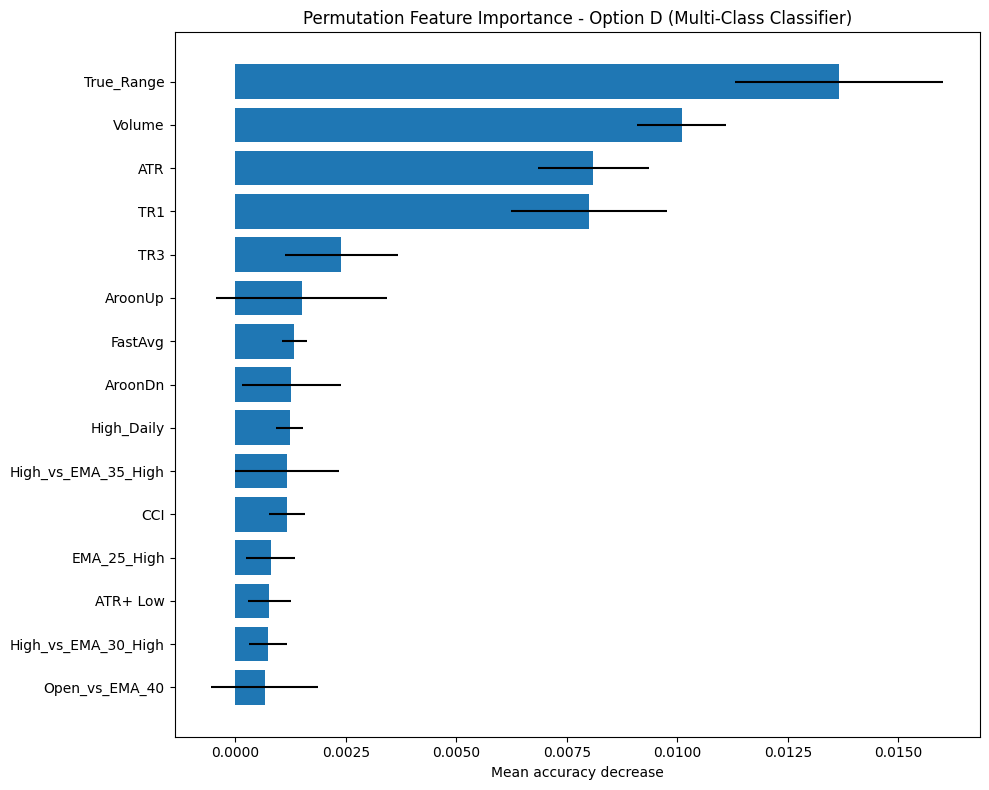

  ✅ Permutation importance completed in 28.7s

🔍 ANALYSIS 3: Feature Correlations
  📊 Feature Correlations with Target:
True_Range             0.062937
TR1                    0.062345
TR3                    0.057667
ATR                    0.057601
Volume                 0.035835
AroonUp                0.018316
High_vs_EMA_30_High    0.006771
CCI                    0.006567
High_vs_EMA_35_High    0.005164
Open_vs_EMA_40         0.003448
AroonDn               -0.000781
High_Daily            -0.009196
EMA_25_High           -0.019290
FastAvg               -0.019730
ATR+ Low              -0.020772
Name: target, dtype: float64


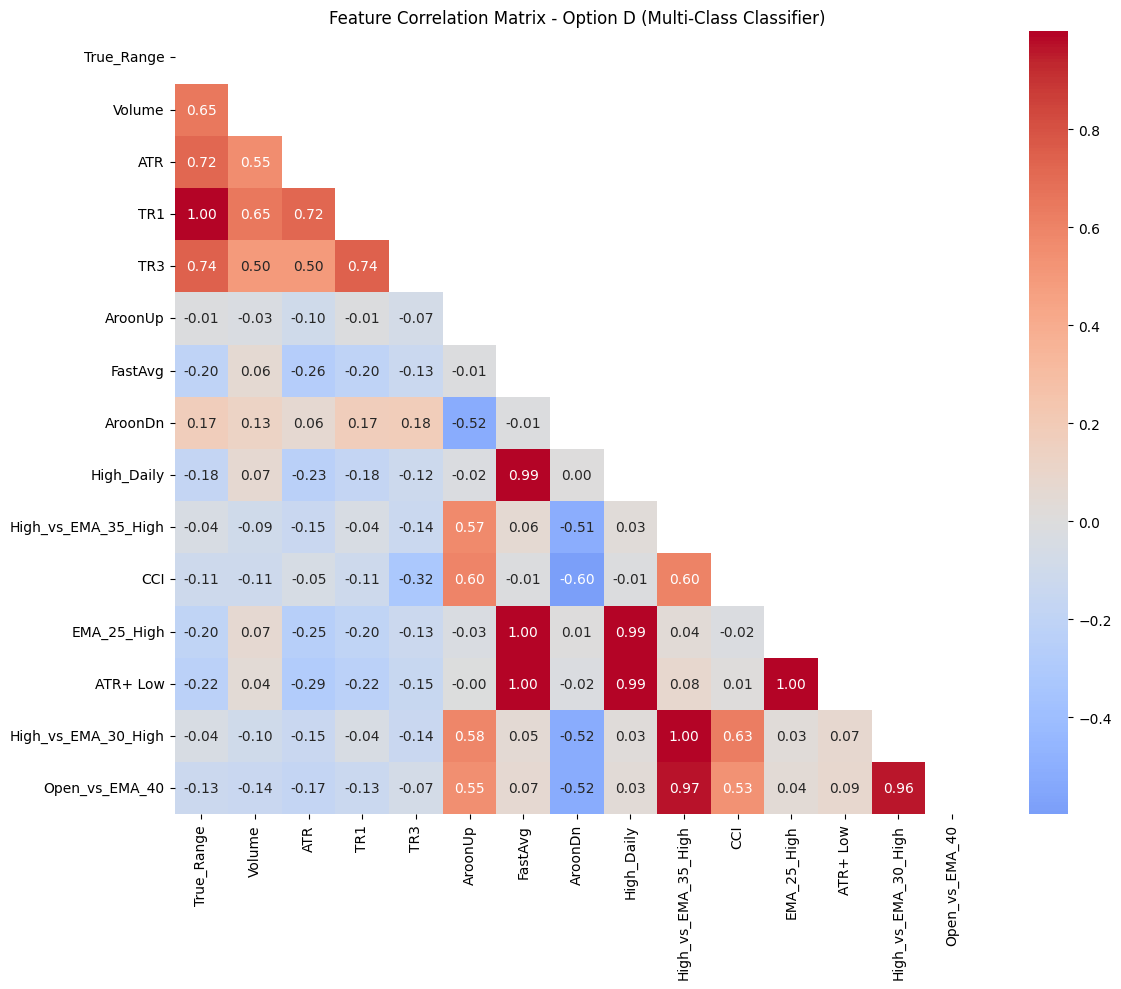


🔍 ANALYSIS 4: Feature Distributions by Class


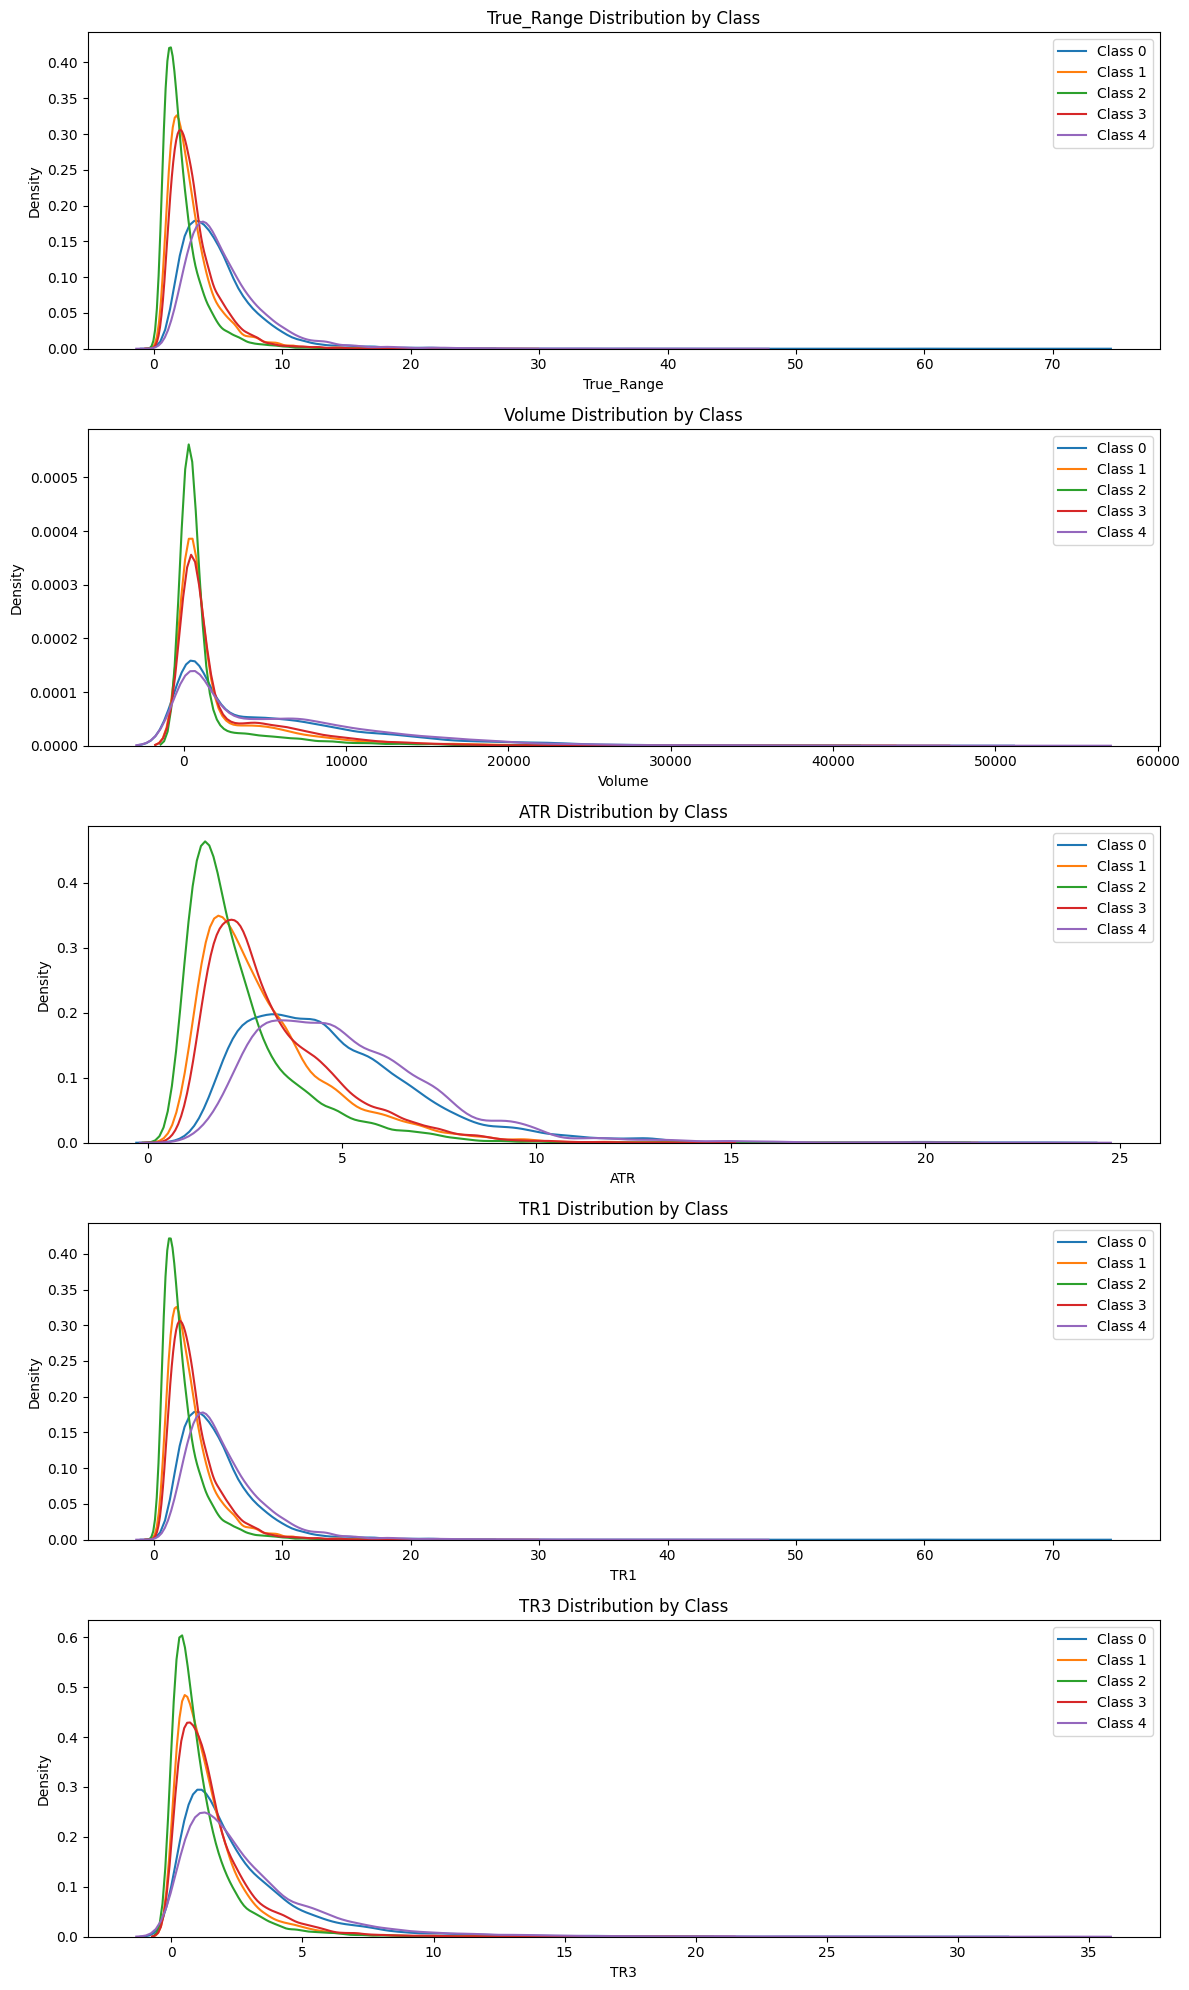


🔍 ANALYSIS 5: Feature Importance Stability
  Running stability analysis with 3 iterations...
  Iteration 1/3... Done
  Iteration 2/3... Done
  Iteration 3/3... Done

  🔍 Feature Importance Stability Results:
                 mean_rank  std_rank  appearance_rate
True_Range        1.000000  0.000000         1.666667
TR1               2.000000  0.000000         1.666667
ATR               3.000000  0.000000         1.666667
TR2               4.333333  0.471405         1.666667
TR3               4.666667  0.471405         1.666667
Volume            6.000000  0.000000         1.666667
AroonDn           7.333333  0.471405         1.666667
AroonUp           8.333333  0.471405         1.666667
movement          8.333333  0.942809         1.666667
Relative_Volume  10.000000  0.000000         1.666667
Close_vs_EMA_35  11.000000  0.000000         1.000000
Open_vs_EMA_5    12.000000  0.000000         1.000000
Close_vs_EMA_30  12.000000  0.000000         1.000000
Close_vs_EMA_5   12.333333  0.94280

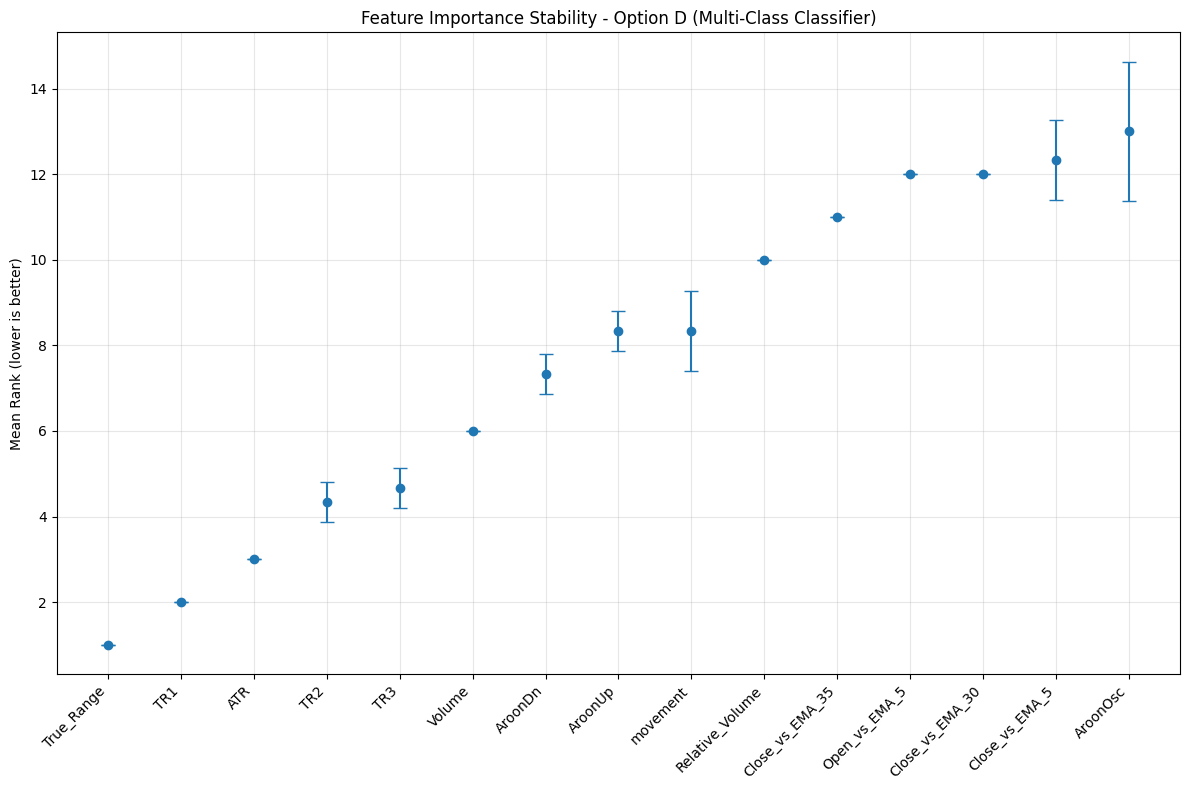

  ✅ Stability analysis completed in 111.0s

✅ Comprehensive feature analysis for Option D (Multi-Class Classifier) completed!

📊 FEATURE IMPORTANCE SUMMARY

💡 Goal C (Binary Classifier) - Top Features:

  📌 Basic Model Importance:
    1. Volume: 0.0265
    2. Relative_Volume: 0.0264
    3. Williams_R: 0.0254
    4. CCI_Avg: 0.0218
    5. TR3: 0.0215
    6. Close_vs_EMA_5: 0.0210
    7. TR2: 0.0201
    8. ADX: 0.0191
    9. Close_vs_EMA_10: 0.0168
    10. CCI: 0.0164

  📌 Permutation Importance:
    1. SlowAvg: 0.0047
    2. Prev_Label: 0.0038
    3. High_Max_12: 0.0033
    4. Open_vs_EMA_15: 0.0033
    5. TR3: 0.0032
    6. TR2: 0.0025
    7. High_Daily: 0.0022
    8. MACD: 0.0022
    9. Close: 0.0020
    10. True_Range: 0.0018

  📌 Target Correlation:
    1. Prev_Label: -0.0821
    2. ADX: -0.0225
    3. TR3: 0.0208
    4. High_vs_EMA_25_High: -0.0184
    5. MACD: -0.0147
    6. Close: -0.0136
    7. Typical_Price: -0.0131
    8. High_Daily: 0.0123
    9. TR2: -0.0120
    10. SenkouSp

In [90]:
def run_comprehensive_feature_analysis(
    trainer_obj, name, X_train, y_train, X_test, y_test, 
    save_plots=False, output_folder="feature_analysis_plots",
    n_top_features=15, n_iterations=5
):
    """
    Run all feature importance analysis methods on a given model
    
    Args:
        trainer_obj: The classifier trainer object
        name: Name for this model/analysis
        X_train: Training features
        y_train: Training labels
        X_test: Test features
        y_test: Test labels
        save_plots: Whether to save plots to files
        output_folder: Folder to save plots (if save_plots=True)
        n_top_features: Number of top features to analyze
        n_iterations: Number of iterations for stability analysis
    
    Returns:
        dict: All analysis results
    """
    import time
    import os
    from datetime import datetime
    
    # Create output folder if saving plots
    if save_plots and not os.path.exists(output_folder):
        os.makedirs(output_folder)
        
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    results = {}
    
    print(f"📊 Starting comprehensive feature analysis for {name}...")
    print("=" * 80)
    
    # 1. Basic Feature Importance
    print("\n🔍 ANALYSIS 1: Basic Feature Importance from Model")
    model = trainer_obj.rf_results["model"]
    
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_).mean(axis=0) if model.coef_.ndim > 1 else np.abs(model.coef_)
    else:
        print("  ⚠️ Model doesn't have standard feature importance method")
        importances = None
    
    if importances is not None:
        # Get feature names
        if hasattr(model, "feature_names_in_"):
            feature_names = model.feature_names_in_
        else:
            feature_names = X_train.columns.tolist()
            
        # Sort features by importance
        indices = np.argsort(importances)[::-1]
        sorted_names = [feature_names[i] for i in indices]
        sorted_importance = importances[indices]
        
        # Print top features
        print(f"  Top {n_top_features} Features:")
        for i in range(min(n_top_features, len(sorted_names))):
            print(f"  {i+1}. {sorted_names[i]}: {sorted_importance[i]:.4f}")
        
        # Create visualization
        plt.figure(figsize=(10, 8))
        plt.title(f"Feature Importance - {name}")
        plt.barh(range(min(n_top_features, len(sorted_names))), 
                 sorted_importance[:n_top_features], 
                 align='center')
        plt.yticks(range(min(n_top_features, len(sorted_names))), sorted_names[:n_top_features])
        plt.gca().invert_yaxis()  # Display highest importance at top
        plt.xlabel('Importance')
        plt.tight_layout()
        
        if save_plots:
            plt.savefig(f"{output_folder}/{timestamp}_{name.replace(' ', '_')}_feature_importance.png")
        plt.show()
        
        results['basic_importance'] = {
            'names': sorted_names[:n_top_features],
            'values': sorted_importance[:n_top_features].tolist()
        }
    
    # 2. Permutation Importance
    print("\n🔍 ANALYSIS 2: Permutation Importance")
    print(f"  Calculating permutation importance for {name}...")
    try:
        start_time = time.time()
        perm_importance = permutation_importance(model, X_test, y_test, 
                                               n_repeats=5, random_state=42)
        
        # Sort features by importance
        indices = np.argsort(perm_importance.importances_mean)[::-1]
        if hasattr(model, "feature_names_in_"):
            feature_names = model.feature_names_in_
        else:
            feature_names = X_test.columns.tolist()
            
        perm_sorted_names = [feature_names[i] for i in indices]
        perm_sorted_importance = perm_importance.importances_mean[indices]
        
        # Print top features
        print(f"  Top {n_top_features} Features by Permutation Importance:")
        for i in range(min(n_top_features, len(perm_sorted_names))):
            print(f"  {i+1}. {perm_sorted_names[i]}: {perm_sorted_importance[i]:.4f} ± {perm_importance.importances_std[indices[i]]:.4f}")
        
        # Visualization
        plt.figure(figsize=(10, 8))
        plt.title(f"Permutation Feature Importance - {name}")
        plt.barh(range(min(n_top_features, len(perm_sorted_names))), 
                perm_sorted_importance[:n_top_features], 
                xerr=perm_importance.importances_std[indices][:n_top_features],
                align='center')
        plt.yticks(range(min(n_top_features, len(perm_sorted_names))), perm_sorted_names[:n_top_features])
        plt.gca().invert_yaxis()
        plt.xlabel('Mean accuracy decrease')
        plt.tight_layout()
        
        if save_plots:
            plt.savefig(f"{output_folder}/{timestamp}_{name.replace(' ', '_')}_permutation_importance.png")
        plt.show()
        
        results['permutation_importance'] = {
            'names': perm_sorted_names[:n_top_features],
            'values': perm_sorted_importance[:n_top_features].tolist(),
            'std': perm_importance.importances_std[indices][:n_top_features].tolist()
        }
        print(f"  ✅ Permutation importance completed in {time.time() - start_time:.1f}s")
    except Exception as e:
        print(f"  ⚠️ Error in permutation importance: {str(e)}")
        perm_sorted_names = sorted_names[:n_top_features] if 'sorted_names' in locals() else []
        results['permutation_importance'] = None
    
    # 3. Feature Correlations
    print("\n🔍 ANALYSIS 3: Feature Correlations")
    try:
        # Get feature names
        if hasattr(model, "feature_names_in_"):
            feature_names = model.feature_names_in_
        else:
            feature_names = X_train.columns.tolist()
        
        # Select features to analyze
        if len(perm_sorted_names) > 0:
            selected_indices = [list(feature_names).index(feat) for feat in perm_sorted_names[:n_top_features] if feat in feature_names]
            selected_features = [feature_names[i] for i in selected_indices]
        else:
            selected_features = feature_names[:n_top_features]
        
        # Create a DataFrame with selected features and target
        df = pd.DataFrame(X_train, columns=feature_names)
        df = df[selected_features]
        df['target'] = y_train
        
        # Calculate correlation with target
        correlations = df.corr()['target'].drop('target').sort_values(ascending=False)
        
        print(f"  📊 Feature Correlations with Target:")
        print(correlations)
        
        # Create correlation heatmap between features
        plt.figure(figsize=(12, 10))
        feature_corr = df[selected_features].corr()
        mask = np.triu(np.ones_like(feature_corr, dtype=bool))
        sns.heatmap(feature_corr, mask=mask, annot=True, cmap='coolwarm', center=0, fmt='.2f')
        plt.title(f"Feature Correlation Matrix - {name}")
        plt.tight_layout()
        
        if save_plots:
            plt.savefig(f"{output_folder}/{timestamp}_{name.replace(' ', '_')}_correlation_matrix.png")
        plt.show()
        
        results['correlations'] = correlations.to_dict()
    except Exception as e:
        print(f"  ⚠️ Error in correlation analysis: {str(e)}")
        results['correlations'] = None
    
    # 4. Feature Distributions by Class
    print("\n🔍 ANALYSIS 4: Feature Distributions by Class")
    try:
        # Select top 5 features for distribution analysis
        n_dist_features = min(5, len(selected_features))
        dist_features = selected_features[:n_dist_features]
        
        # Visualize distributions
        fig, axes = plt.subplots(len(dist_features), 1, figsize=(12, 4*len(dist_features)))
        if len(dist_features) == 1:
            axes = [axes]
        
        for i, feature in enumerate(dist_features):
            ax = axes[i]
            for target_class in np.unique(y_train):
                sns.kdeplot(df[df['target'] == target_class][feature], 
                            label=f"Class {target_class}", ax=ax)
            ax.set_title(f"{feature} Distribution by Class")
            ax.legend()
        
        plt.tight_layout()
        
        if save_plots:
            plt.savefig(f"{output_folder}/{timestamp}_{name.replace(' ', '_')}_distributions.png")
        plt.show()
        
        results['distributions'] = {'features_analyzed': dist_features}
    except Exception as e:
        print(f"  ⚠️ Error in distribution analysis: {str(e)}")
        results['distributions'] = None
    
    # 5. Feature Importance Stability (optional - can be slow)
    print("\n🔍 ANALYSIS 5: Feature Importance Stability")
    if n_iterations > 0:
        try:
            start_time = time.time()
            # Get feature names
            if hasattr(model, "feature_names_in_"):
                feature_names = model.feature_names_in_
            else:
                feature_names = X_train.columns.tolist()
                
            # Create a DataFrame to track feature ranks
            feature_ranks = pd.DataFrame(index=feature_names)
            
            # Convert to numpy arrays
            X_np = X_train.values if hasattr(X_train, 'values') else X_train
            y_np = y_train.values if hasattr(y_train, 'values') else y_train
            
            print(f"  Running stability analysis with {n_iterations} iterations...")
            
            # Run multiple iterations
            for i in range(n_iterations):
                print(f"  Iteration {i+1}/{n_iterations}...", end="")
                # Sample data
                indices = np.random.choice(len(X_np), size=int(0.8 * len(X_np)), replace=False)
                X_sample, y_sample = X_np[indices], y_np[indices]
                
                # Clone and retrain model
                model_clone = clone(model)
                model_clone.fit(X_sample, y_sample)
                
                # Get importance
                if hasattr(model_clone, "feature_importances_"):
                    importances = model_clone.feature_importances_
                elif hasattr(model_clone, "coef_"):
                    importances = np.abs(model_clone.coef_).mean(axis=0) if model_clone.coef_.ndim > 1 else np.abs(model_clone.coef_)
                else:
                    print("failed")
                    continue
                    
                # Get top features
                indices = np.argsort(importances)[::-1]
                top_features = {feature_names[i]: {'rank': r+1, 'importance': importances[i]} 
                            for r, i in enumerate(indices[:n_top_features])}
                
                # Record ranks
                col_name = f"Iteration_{i+1}"
                feature_ranks[col_name] = np.nan
                for feature, data in top_features.items():
                    feature_ranks.loc[feature, col_name] = data['rank']
                print(" Done")
            
            # Calculate stability metrics
            feature_ranks['mean_rank'] = feature_ranks.mean(axis=1)
            feature_ranks['std_rank'] = feature_ranks.std(axis=1)
            feature_ranks['appearance_rate'] = feature_ranks.count(axis=1) / n_iterations
            
            # Sort by mean rank
            feature_ranks = feature_ranks.sort_values('mean_rank')
            
            # Display results
            print(f"\n  🔍 Feature Importance Stability Results:")
            stable_features = feature_ranks.head(n_top_features)[['mean_rank', 'std_rank', 'appearance_rate']]
            print(stable_features)
            
            # Plot stability
            plt.figure(figsize=(12, 8))
            plt.errorbar(range(len(stable_features)), stable_features['mean_rank'], 
                        yerr=stable_features['std_rank'], fmt='o', capsize=5)
            plt.xticks(range(len(stable_features)), stable_features.index, rotation=45, ha='right')
            plt.ylabel('Mean Rank (lower is better)')
            plt.title(f'Feature Importance Stability - {name}')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            
            if save_plots:
                plt.savefig(f"{output_folder}/{timestamp}_{name.replace(' ', '_')}_stability.png")
            plt.show()
            
            results['stability'] = stable_features.to_dict()
            print(f"  ✅ Stability analysis completed in {time.time() - start_time:.1f}s")
        except Exception as e:
            print(f"  ⚠️ Error in stability analysis: {str(e)}")
            results['stability'] = None
    else:
        print("  ℹ️ Stability analysis skipped (n_iterations=0)")
    
    print("\n" + "=" * 80)
    print(f"✅ Comprehensive feature analysis for {name} completed!")
    return results

# Run analysis for Goal C model
results_goal_c = run_comprehensive_feature_analysis(
    classifier_trainer_all_goal_c,
    "Goal C (Binary Classifier)",
    classifier_X_train_bal_all_goal_c,
    classifier_y_train_bal_all_goal_c,
    X_test_all_goal_c, 
    y_test_all_goal_c,
    save_plots=True,  # Set to True if you want to save plots to files
    n_iterations=3  # Reduced for speed
)

# Run analysis for Option D model (replace variable names with your actual ones)
results_option_d = run_comprehensive_feature_analysis(
    classifier_trainer_d_15m,
    "Option D (Multi-Class Classifier)",
    classifier_X_train_bal_d_15m,  # Replace with your actual variable name
    classifier_y_train_bal_d_15m,  # Replace with your actual variable name
    X_test_d_15m,  # Replace with your actual variable name
    y_test_d_15m,  # Replace with your actual variable name
    save_plots=True,  # Set to True if you want to save plots to files
    n_iterations=3  # Reduced for speed
)

# Summary of most important features from different methods
print("\n📊 FEATURE IMPORTANCE SUMMARY")
print("=" * 80)

def print_top_features_summary(results, name, top_n=10):
    print(f"\n💡 {name} - Top Features:")
    
    methods = [
        ('Basic Model Importance', 'basic_importance'),
        ('Permutation Importance', 'permutation_importance'),
        ('Target Correlation', 'correlations')
    ]
    
    for method_name, method_key in methods:
        if results[method_key] is not None:
            print(f"\n  📌 {method_name}:")
            
            if method_key == 'basic_importance' or method_key == 'permutation_importance':
                features = results[method_key]['names'][:top_n]
                values = results[method_key]['values'][:top_n]
                
                for i, (feature, value) in enumerate(zip(features, values)):
                    print(f"    {i+1}. {feature}: {value:.4f}")
                    
            elif method_key == 'correlations':
                # For correlations, we need to sort by absolute correlation
                corr_dict = results[method_key]
                corr_items = sorted(corr_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:top_n]
                
                for i, (feature, value) in enumerate(corr_items):
                    print(f"    {i+1}. {feature}: {value:.4f}")

print_top_features_summary(results_goal_c, "Goal C (Binary Classifier)")
print_top_features_summary(results_option_d, "Option D (Multi-Class Classifier)")

# Find common important features across both models
if results_goal_c['basic_importance'] and results_option_d['basic_importance']:
    c_top_features = set(results_goal_c['basic_importance']['names'][:10])
    d_top_features = set(results_option_d['basic_importance']['names'][:10])
    
    common_features = c_top_features.intersection(d_top_features)
    
    print("\n🔍 Common Important Features Across Models:")
    for feature in common_features:
        print(f"  - {feature}")

In [92]:
print("test")

test
